<a href="https://colab.research.google.com/github/enakirimoto/Machine-Learning-and-Analytics/blob/main/Projeto_Eric_MVP_ML_%26_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Template — MVP: *Machine Learning & Analytics*
**Autor:** Eric Koji Nakirimoto  

**Data:** 27/08/2025

**Matrícula:** 4052025000088

**Dataset:**: [Uber Dataset](https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard/data)



---

# Dataset

## Resumo do Dataset: Análise de Corridas do Uber 2024

Este projeto utiliza o **Uber Ride Analytics Dataset 2024**, um conjunto de dados abrangente que contém informações detalhadas sobre as operações de compartilhamento de viagens do Uber durante o ano de 2024. O dataset oferece ricos insights sobre padrões de reserva, desempenho de veículos, fontes de receita, comportamentos de cancelamento e métricas de satisfação do cliente.

### Visão Geral dos Dados

O conjunto de dados captura um total de **148.770 reservas** em vários tipos de veículos, fornecendo uma visão completa das operações, incluindo corridas bem-sucedidas, cancelamentos e métricas financeiras.

**Estatísticas Principais fornecidas pelo dataset:**
* **Total de Reservas:** 148,77 mil
* **Taxa de Sucesso:** 65,96% (93 mil corridas concluídas)
* **Taxa de Cancelamento Total:** 25% (37,43 mil reservas canceladas)
    * **Cancelamentos por Clientes:** 19,15% (27 mil corridas)
    * **Cancelamentos por Motoristas:** 7,45% (10,5 mil corridas)

---

### Objetivo do Projeto de Machine Learning

O principal objetivo deste trabalho é utilizar os dados, com foco especial nos **cancelamentos por parte dos motoristas**, para desenvolver um **modelo preditivo**. A meta é criar um sistema que consiga identificar, com base nos padrões históricos e dados em tempo real, a alta probabilidade de um motorista cancelar uma corrida **antes que ela seja aceita**. O desenvolvedor desse modelo já passou raiva diversas vezes por conta do excesso de cancelamentos e quer identificar se é possível prever isso e sugerir ao Uber que utilize esse modelo pois esse tipo de cancelamento é desagradável.

Na prática, ao prever um cancelamento iminente, a plataforma poderia **evitar o envio da solicitação de viagem** para esse motorista específico. Isso otimizaria a alocação de corridas para motoristas com maior probabilidade de aceitar e completar a viagem, resultando na redução do tempo de espera do cliente e na melhoria da eficiência geral do serviço.

---

### Atributos

O dataset possui os seguintes atributos.


| Nome da Coluna | Descrição |
| :--- | :--- |
| **Date** | Data da reserva |
| **Time** | Hora da reserva |
| **Booking ID** | Identificador único para cada reserva de corrida |
| **Booking Status** | Status da reserva (Concluída, Cancelada pelo Cliente, Cancelada pelo Motorista, etc.) |
| **Customer ID** | Identificador único para clientes |
| **Vehicle Type** | Tipo de veículo (Go Mini, Go Sedan, Auto, eBike/Bike, UberXL, Premier Sedan) |
| **Pickup Location** | Local de partida da corrida |
| **Drop Location** | Local de destino da corrida |
| **Avg VTAT** | Tempo médio para o motorista chegar ao local de partida (em minutos) |
| **Avg CTAT** | Duração média da viagem da partida ao destino (em minutos) |
| **Cancelled Rides by Customer** | Indicador de cancelamento iniciado pelo cliente |
| **Reason for cancelling by Customer**| Motivo do cancelamento pelo cliente |
| **Cancelled Rides by Driver** | Indicador de cancelamento iniciado pelo motorista |
| **Driver Cancellation Reason** | Motivo do cancelamento pelo motorista |
| **Incomplete Rides** | Indicador de corrida incompleta |
| **Incomplete Rides Reason** | Motivo para corridas incompletas |
| **Booking Value** | Valor total da tarifa da corrida |
| **Ride Distance** | Distância percorrida durante a corrida (em km) |
| **Driver Ratings** | Avaliação dada ao motorista (escala de 1 a 5) |
| **Customer Rating** | Avaliação dada pelo cliente (escala de 1 a 5) |
| **Payment Method** | Método utilizado para pagamento (UPI, Dinheiro, Cartão de Crédito, Carteira Uber, Cartão de Débito) |


Com essa parte entende-se que a etapa de "Problema definido está concluída"✅

#Início da importação de bibliotecas utilizadas


In [81]:
# configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

import math
import os
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import joblib
import requests

import tensorflow as tf

import keras
from keras import layers, ops
from keras.models import Sequential


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.model_selection import (GridSearchCV, KFold, RandomizedSearchCV,
                                     StratifiedKFold, TimeSeriesSplit,
                                     cross_val_score, cross_validate,
                                     train_test_split)
from sklearn.cluster import KMeans
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (AdaBoostClassifier, BaggingClassifier,
                              ExtraTreesClassifier, GradientBoostingClassifier,
                              RandomForestClassifier, RandomForestRegressor,
                              VotingClassifier)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, mean_absolute_error,
                             mean_squared_error, r2_score, roc_auc_score,
                             silhouette_score)

# Importando o dataset

In [2]:


url = "https://raw.githubusercontent.com/enakirimoto/Machine-Learning-and-Analytics/refs/heads/main/ncr_ride_bookings.csv"

df = pd.read_csv(url)

#Avaliação dos dados
print(df.head())

         Date      Time    Booking ID   Booking Status   Customer ID  \
0  2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1  2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2  2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3  2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4  2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   

    Vehicle Type      Pickup Location      Drop Location  Avg VTAT  Avg CTAT  \
0          eBike          Palam Vihar            Jhilmil       NaN       NaN   
1       Go Sedan        Shastri Nagar  Gurgaon Sector 56       4.9      14.0   
2           Auto              Khandsa      Malviya Nagar      13.4      25.8   
3  Premier Sedan  Central Secretariat           Inderlok      13.1      28.5   
4           Bike     Ghitorni Village        Khan Market       5.3      19.6   

   ...  Reason for cancelling by Customer Cancelled Rides by Driver  \
0  ...         

#Início da análise exploratória

## Hipóteses na análise
* Na análise exploratória conseguimos identificar os melhores atributos para o treinamento do modelo;
* Na análise dos dados conseguiremos identificar ser há alguma anomalia e se for necessário tratar os dados.

## Hipóteses do modelo
* Com o treinamento dos modelos espera-se avaliar qual a acurácia de implantação de diversas técnicas para definir o melhor método para utilização.

In [3]:
#Análises genéricas do dataset

print(df.describe)
print(df.info())
print(df.columns)

<bound method NDFrame.describe of               Date      Time    Booking ID   Booking Status   Customer ID  \
0       2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1       2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2       2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3       2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4       2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   
...            ...       ...           ...              ...           ...   
149995  2024-11-11  19:34:01  "CNR6500631"        Completed  "CID4337371"   
149996  2024-11-24  15:55:09  "CNR2468611"        Completed  "CID2325623"   
149997  2024-09-18  10:55:15  "CNR6358306"        Completed  "CID9925486"   
149998  2024-10-05  07:53:34  "CNR3030099"        Completed  "CID9415487"   
149999  2024-03-10  15:38:03  "CNR3447390"        Completed  "CID4108667"   

         Vehicle Type         Pickup Loca

#Primeiro diagnóstico
O dataset possui 150k linhas e 21 colunas. Entendendo que o objetivo é prever os cancelamentos feitos pelo motorista, entende-se que se faz necessário entender quais são os atributos que possuem valores que podem ser utilizados para análise exploratória.

In [4]:
#Filtrando os dados de corridas canceladas
df_filtrado = df[df['Cancelled Rides by Driver'].notna()]
print(df_filtrado)

#Entendendo a quantidade de variáveis que cada atributo tem
print(df_filtrado.nunique())

print(df_filtrado['Date'].max())
print(df_filtrado['Date'].min())

              Date      Time    Booking ID       Booking Status   Customer ID  \
12      2024-06-25  22:44:15  "CNR4386945"  Cancelled by Driver  "CID5543520"   
17      2024-12-15  15:08:25  "CNR6739317"  Cancelled by Driver  "CID8682675"   
19      2024-05-24  19:53:57  "CNR9465840"  Cancelled by Driver  "CID9046501"   
26      2024-01-26  09:44:00  "CNR3614535"  Cancelled by Driver  "CID2507102"   
30      2024-05-18  17:37:52  "CNR2178654"  Cancelled by Driver  "CID3631860"   
...            ...       ...           ...                  ...           ...   
149959  2024-01-24  13:37:23  "CNR4666409"  Cancelled by Driver  "CID7135403"   
149973  2024-02-06  18:03:44  "CNR4828704"  Cancelled by Driver  "CID3769079"   
149977  2024-03-02  13:22:23  "CNR9330412"  Cancelled by Driver  "CID3815156"   
149979  2024-10-05  17:30:25  "CNR8459494"  Cancelled by Driver  "CID9568404"   
149990  2024-09-26  12:31:22  "CNR3212810"  Cancelled by Driver  "CID6199171"   

       Vehicle Type     Pic

#Segundo diagnóstico

A percepção da avaliação inicial foi de que os atributos mais interessantes para explorar pensando-se em treinar um modelo são:

- Date: Entender se há algum dia em potêncial que gera esse cancelamento
- Time: Entender se há algum horário que costuma gerar esse cancelamento
- Tipo de veículo: Há poucos tipos de veículos e quero entender se há algum tipo de veículo que gera mais cancelamentos
- Avg VTAT: Entender se o tempo para chegar ao trajeto influência

Ainda há outras opções como o "Pickup Location" e "Drop Location". Por possuirem 176 variáveis, se torna inviável a criação de dummys, mas os dados serão avaliados para identificar se há variáveis que se repetem e se há algum padrão.

Pickup Location
Nehru Place         190
Shivaji Park        185
GTB Nagar           183
Saket               179
Pragati Maidan      179
Vinobapuri          176
Punjabi Bagh        176
Rajouri Garden      176
AIIMS               176
Nawada              174
Chhatarpur          173
Rohini East         173
Kadarpur            172
Qutub Minar         172
Patel Chowk         171
Munirka             171
Dwarka Sector 21    170
Karkarduma          170
Akshardham          170
Barakhamba Road     170
Name: count, dtype: int64
Drop Location
Basai Dhankot          192
Vasant Kunj            183
Ardee City             178
Udyog Vihar            178
Govindpuri             178
Hauz Khas              177
Gurgaon Sector 29      176
Bhikaji Cama Place     176
Ghitorni               176
Vidhan Sabha           175
Shastri Nagar          175
Pataudi Chowk          174
Gurgaon Sector 56      173
Keshav Puram           172
Moolchand              172
GTB Nagar              172
Nehru Place            171
RK Pu

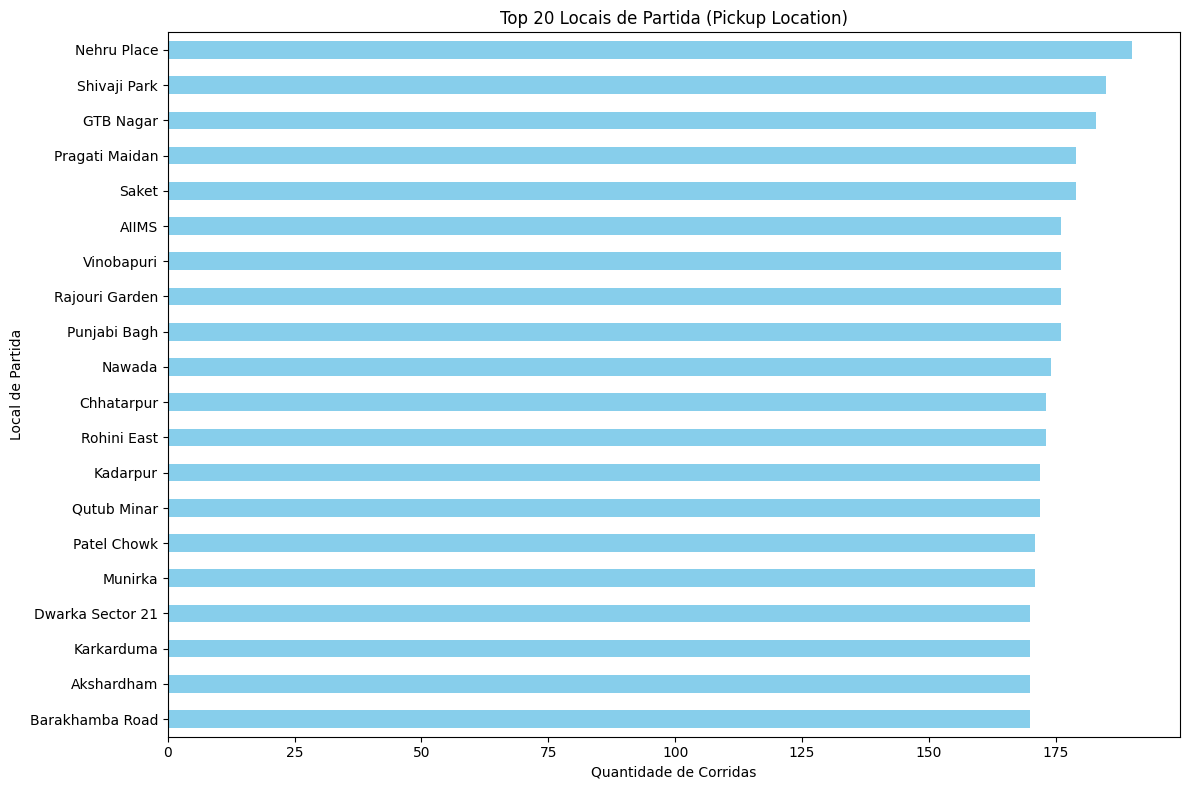

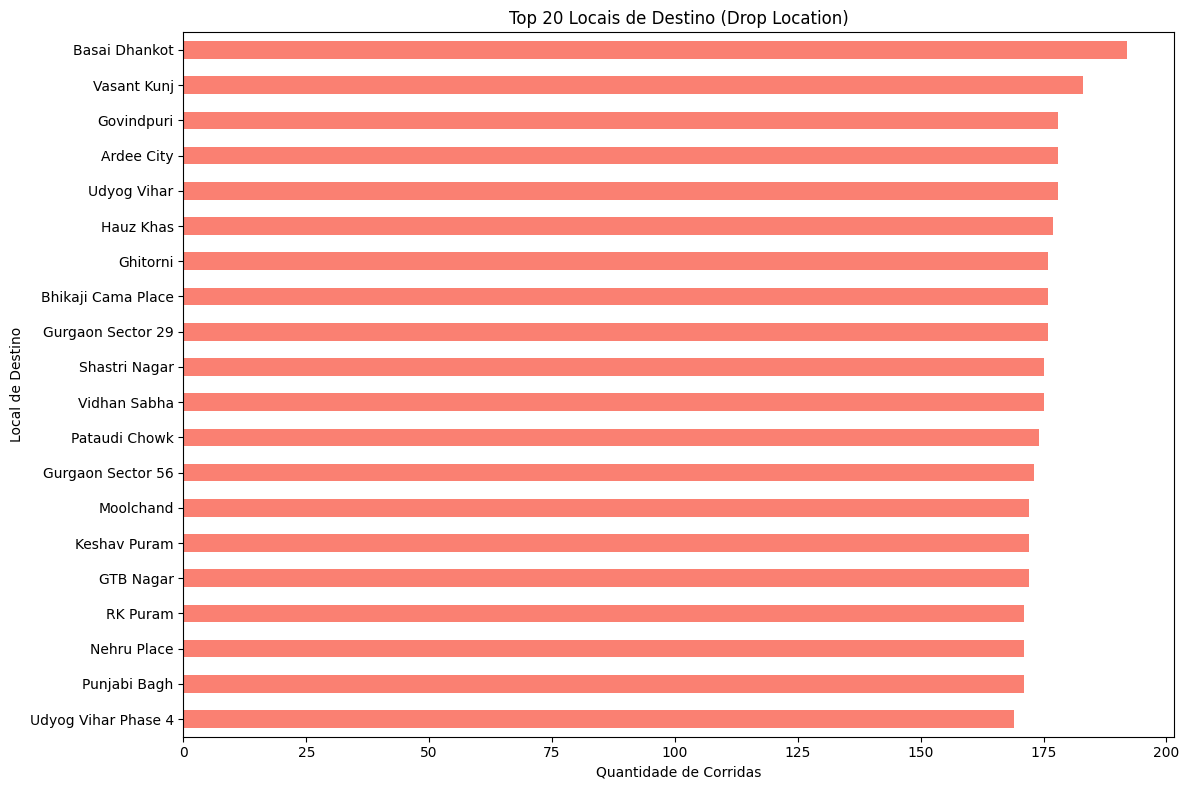

In [5]:
#Separando as top 20 maiores distribuições para entender se consigo dfazer algum agrupamento
top_20_pickup = df_filtrado['Pickup Location'].value_counts().nlargest(20)
print(top_20_pickup)


plt.figure(figsize=(12, 8))
top_20_pickup.sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title('Top 20 Locais de Partida (Pickup Location)')
plt.xlabel('Quantidade de Corridas')
plt.ylabel('Local de Partida')
plt.tight_layout()

top_20_drop = df_filtrado['Drop Location'].value_counts().nlargest(20)
print(top_20_drop)
plt.figure(figsize=(12, 8))
top_20_drop.sort_values(ascending=True).plot(kind='barh', color='salmon')
plt.title('Top 20 Locais de Destino (Drop Location)')
plt.xlabel('Quantidade de Corridas')
plt.ylabel('Local de Destino')
plt.tight_layout()

Pickup Location
Seelampur              124
Ghitorni Village       125
Sadar Bazar Gurgaon    128
IMT Manesar            129
Kanhaiya Nagar         130
Old Gurgaon            131
Yamuna Bank            131
Hauz Khas              132
Jama Masjid            132
Peeragarhi             132
Welcome                132
Okhla                  133
Laxmi Nagar            133
Noida Sector 18        134
Arjangarh              135
Tis Hazari             136
Mandi House            136
Meerut                 136
Gurgaon Sector 29      136
Delhi Gate             136
Name: count, dtype: int64
Drop Location
Badarpur            125
Adarsh Nagar        125
Saket               127
Noida Extension     129
Aya Nagar           130
Pulbangash          130
Panchsheel Park     131
Preet Vihar         132
Okhla               133
Ghitorni Village    134
IFFCO Chowk         134
Pitampura           134
Tagore Garden       136
Lal Quila           137
Inderlok            137
Ramesh Nagar        137
India Gate          

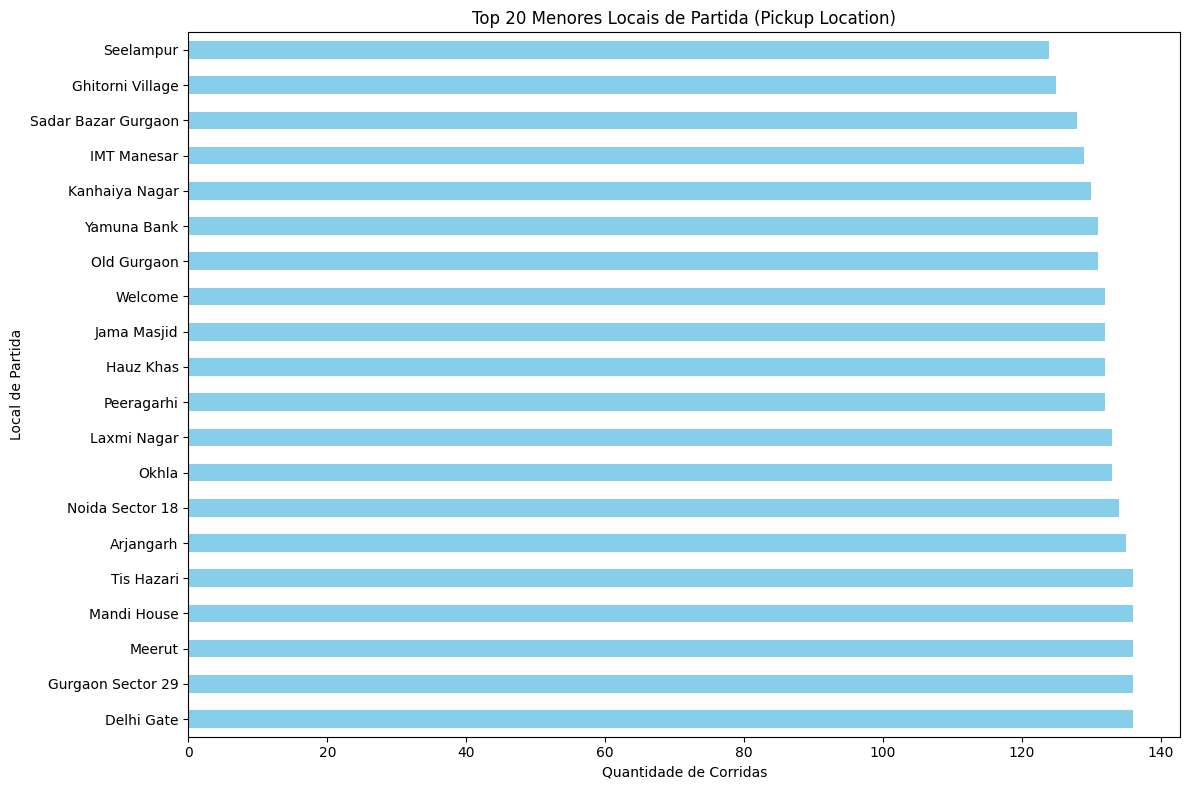

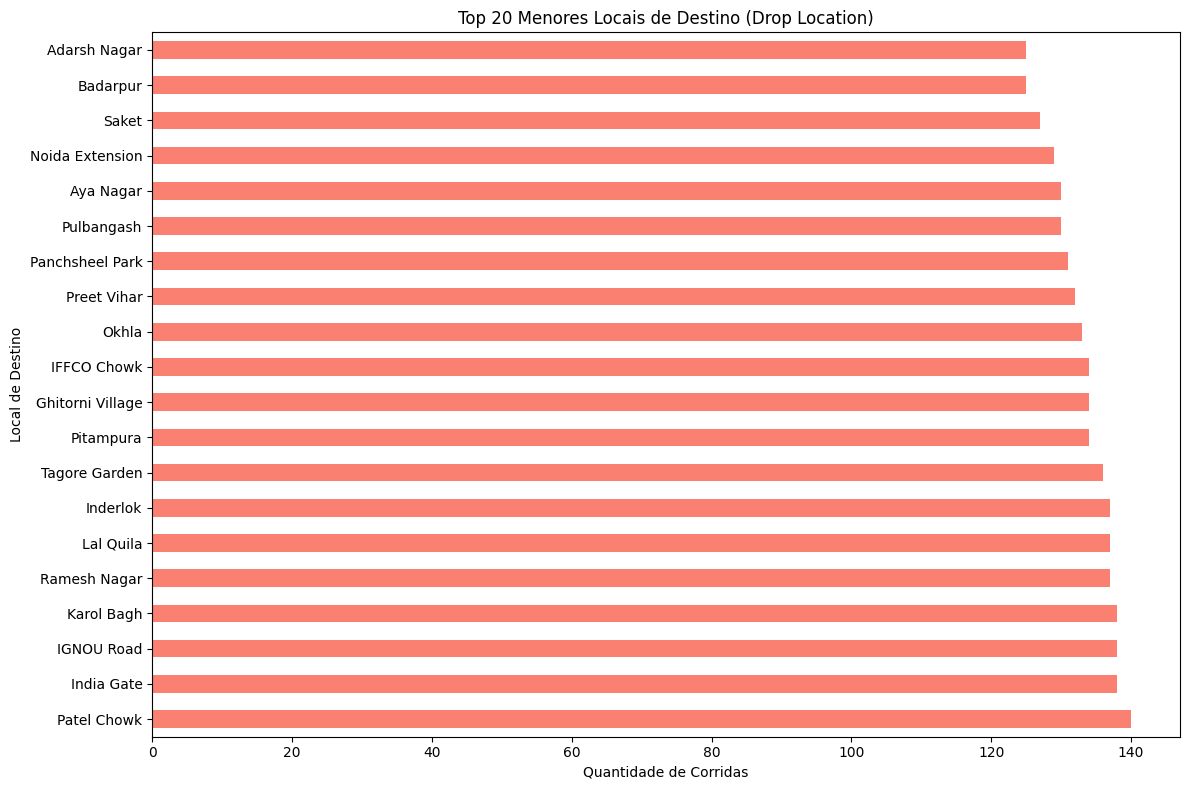

In [6]:
#Separando as top 20 maiores distribuições para entender se consigo dfazer algum agrupamento
top2_20_pickup = df_filtrado['Pickup Location'].value_counts().nsmallest(20)
print(top2_20_pickup)


plt.figure(figsize=(12, 8))
top2_20_pickup.sort_values(ascending=False).plot(kind='barh', color='skyblue')
plt.title('Top 20 Menores Locais de Partida (Pickup Location)')
plt.xlabel('Quantidade de Corridas')
plt.ylabel('Local de Partida')
plt.tight_layout()

top2_20_drop = df_filtrado['Drop Location'].value_counts().nsmallest(20)
print(top2_20_drop)
plt.figure(figsize=(12, 8))
top2_20_drop.sort_values(ascending=False).plot(kind='barh', color='salmon')
plt.title('Top 20 Menores Locais de Destino (Drop Location)')
plt.xlabel('Quantidade de Corridas')
plt.ylabel('Local de Destino')
plt.tight_layout()


print(df_filtrado['Driver Cancellation Reason'].value_counts())

#Terceiro diagnóstico
A análise dos dados de origem e destino não permitiu identificar um local específico com uma concentração atípica de cancelamentos. Caso um conjunto de locais se destacasse com um volume significativo de cancelamentos, seria possível agrupá-los para criar um novo atributo de análise.

Para aprofundar a investigação, é necessário avaliar se o número de cancelamentos é representativo em termos percentuais, comparando-o ao total de chamados de cada local. A hipótese é que, mesmo sem uma discrepância nos números absolutos, certos pontos de partida ou chegada podem apresentar uma taxa de cancelamento percentualmente elevada, o que os tornaria relevantes.


Também identificou-se os motivos de cancelamento.

| Motivo do Cancelamento | Quantidade |
| :--- | :--- |
| Customer related issue | 6837 |
| The customer was coughing/sick | 6751 |
| Personal & Car related issues | 6726 |
| More than permitted people in there | 6686 |

Em uma análise sobre os motivos, entende-se que o motivo de tosse/gripe é algo que depende do bom senso do cliente, acredita-se que não dá para prever esse bom senso e poderia ser resolvido com um aviso. Por conseguinte, na construção do modelo esses motivos serão eliminados da base de dados.

Sobre os problemas pessoais, embora o entendimento do analista seja de que possam ser causas aleatórias, os dados serão mantidos pois a aleatóriedade desses eventos podem ser relacionados com meses do ano ou horários específicos durante o dia.



Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
                   ... 
Mandi House         800
Noida Sector 18     799
Laxmi Nagar         797
Ashok Vihar         796
Ghitorni Village    790
Name: count, Length: 176, dtype: int64
Cancelled Rides by Driver
0.0    123000
1.0     27000
Name: count, dtype: int64
                 total_rides  driver_cancellations
Pickup Location                                   
AIIMS                    918                 176.0
Adarsh Nagar             858                 141.0
Akshardham               839                 170.0
Ambience Mall            873                 151.0
Anand Vihar              859                 142.0
...                      ...                   ...
Vidhan Sabha             825                 154.0
Vinobapuri               823                 176.0
Vishwavidyalaya          895                 169.0
Welcome                  836            

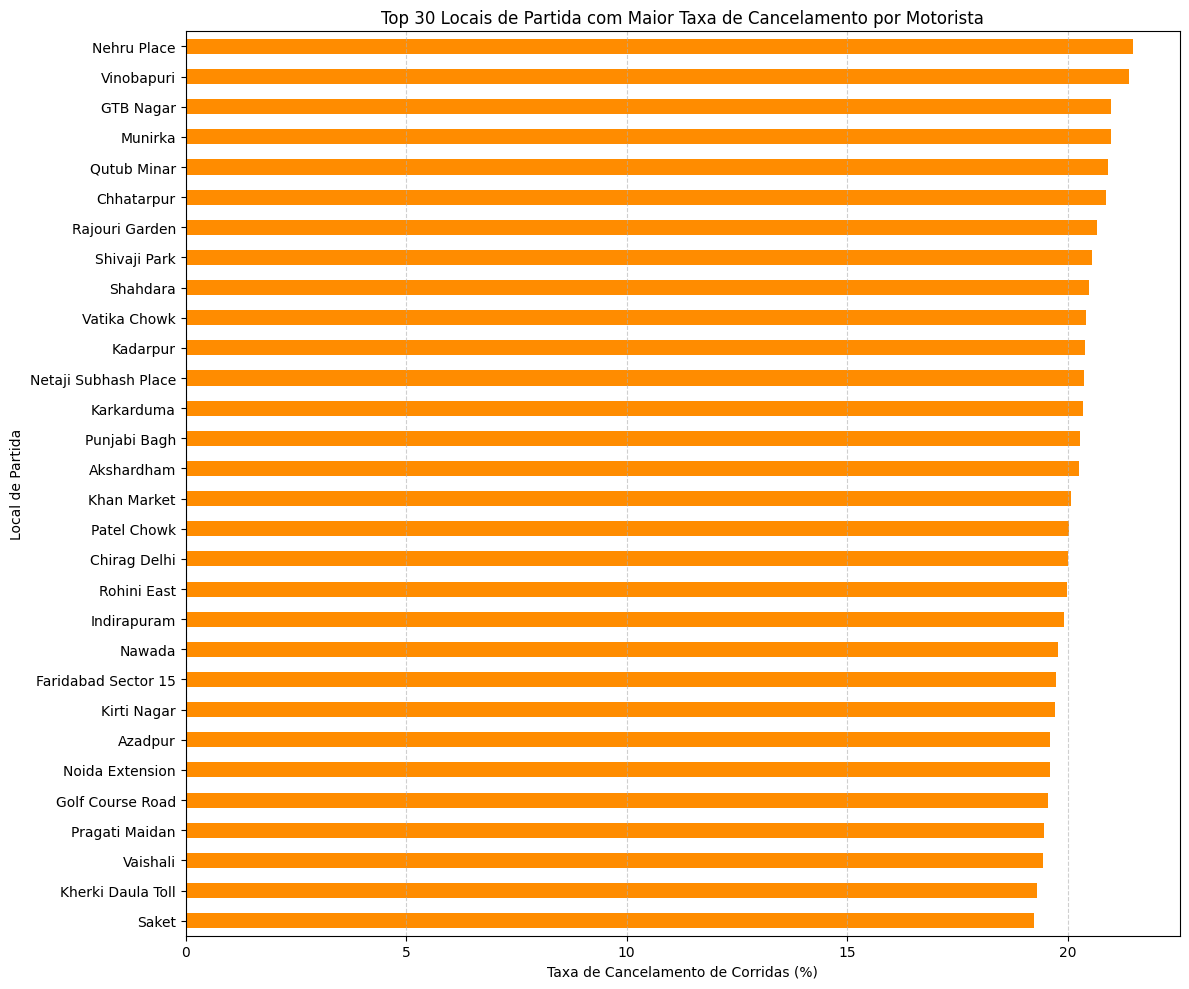

In [7]:
# Entendendo a quantidade de locais para identificar se há algum que não teve cancelamentos
print(df['Pickup Location'].value_counts())

#Criando outros dataframes para não afetar o original
df_calc = df.copy()
df_calc = df_calc.fillna(0)
print(df_calc['Cancelled Rides by Driver'].value_counts())

#Tratando os dados para plotar os 30 locais com mais cancelamentos em lista e em gráfico
location_stats = df_calc.groupby('Pickup Location').agg(
    total_rides=('Booking ID', 'count'),
    driver_cancellations=('Cancelled Rides by Driver', 'sum')
)
print(location_stats)
significant_locations = location_stats.copy()
significant_locations['cancellation_rate_percent_pickup'] =  (significant_locations['driver_cancellations'] / significant_locations['total_rides']) * 100
#print(significant_locations)
plt.figure(figsize=(12, 10))
top_30_locations = significant_locations.nlargest(30, 'cancellation_rate_percent_pickup')
top_30_locations['cancellation_rate_percent_pickup'].sort_values(ascending=True).plot(kind='barh', color='darkorange')
print(top_30_locations)


plt.title('Top 30 Locais de Partida com Maior Taxa de Cancelamento por Motorista')
plt.xlabel('Taxa de Cancelamento de Corridas (%)')
plt.ylabel('Local de Partida')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

#Plotando os 30 locais com menos cancelamentos para entender a faixa de cancelamento.
top2_30_locations = significant_locations.nsmallest(30, 'cancellation_rate_percent_pickup')
print(top2_30_locations)







#Quarto diagnóstico
Na análise identificou-se que todos os locais possuem taxas de cancelamento que variam de 14,5% até 21,5%. Nenhum local apresentou algum destaque que pudesse criar essa correlação, mas acredita-se que possa utilizar essa informação de taxa de cancelamento e vincular aos locais para treinar os modelos. Com isso, cria-se um novo atributo que representa a taxa de cancelamento daquele local de coleta.
A análise será replicada para os locais de entrega para criar uma taxa de cancelamento daquele local para em seguida fazer a limpeza dos dados e a identificação de correlação entre as variáveis.

Drop Location
Ashram              936
Basai Dhankot       917
Lok Kalyan Marg     916
Narsinghpur         913
Cyber Hub           912
                   ... 
MG Road             799
Bhiwadi             792
Shivaji Park        786
Anand Vihar ISBT    784
Huda City Centre    774
Name: count, Length: 176, dtype: int64
Cancelled Rides by Driver
0.0    123000
1.0     27000
Name: count, dtype: int64
                 total_rides  driver_cancellations
Drop Location                                     
AIIMS                    850                 166.0
Adarsh Nagar             845                 125.0
Akshardham               856                 153.0
Ambience Mall            836                 142.0
Anand Vihar              830                 157.0
...                      ...                   ...
Vidhan Sabha             868                 175.0
Vinobapuri               849                 163.0
Vishwavidyalaya          846                 147.0
Welcome                  848              

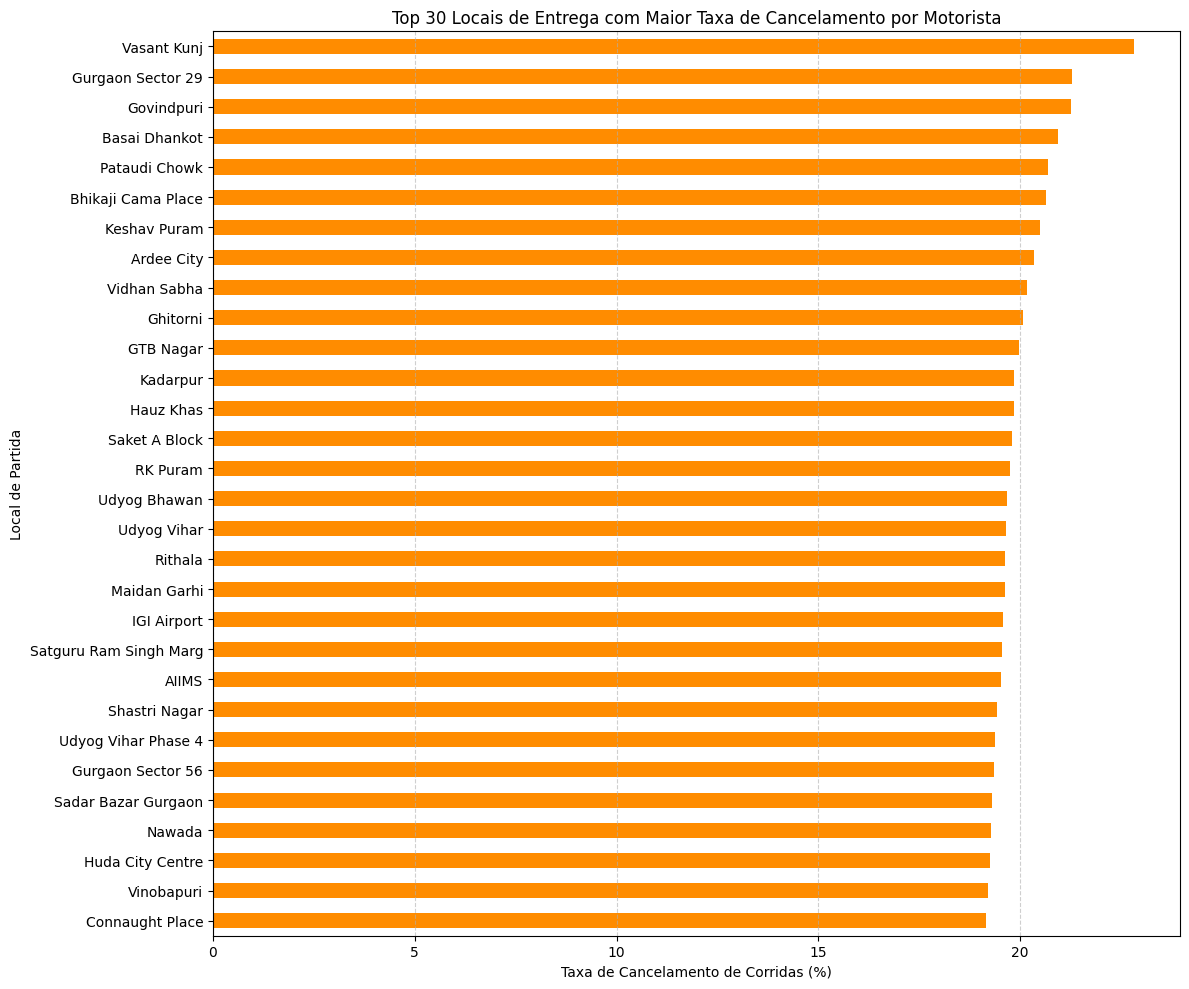

In [8]:
# Entendendo a quantidade de locais para identificar se há algum que não teve cancelamentos
print(df['Drop Location'].value_counts())

#Criando outros dataframes para não afetar o original
df_calc2 = df.copy()
df_calc2 = df_calc2.fillna(0)
print(df_calc2['Cancelled Rides by Driver'].value_counts())

#Tratando os dados para plotar os 30 locais com mais cancelamentos em lista e em gráfico
location_stats2 = df_calc2.groupby('Drop Location').agg(
    total_rides=('Booking ID', 'count'),
    driver_cancellations=('Cancelled Rides by Driver', 'sum')
)
print(location_stats2)
significant_locations2 = location_stats2.copy()
significant_locations2['cancellation_rate_percent_drop'] =  (significant_locations2['driver_cancellations'] / significant_locations2['total_rides']) * 100
#print(significant_locations)
plt.figure(figsize=(12, 10))
top_30_locations2 = significant_locations2.nlargest(30, 'cancellation_rate_percent_drop')
top_30_locations2['cancellation_rate_percent_drop'].sort_values(ascending=True).plot(kind='barh', color='darkorange')
print(top_30_locations2)


plt.title('Top 30 Locais de Entrega com Maior Taxa de Cancelamento por Motorista')
plt.xlabel('Taxa de Cancelamento de Corridas (%)')
plt.ylabel('Local de Partida')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

#Plotando os 30 locais com menos cancelamentos para entender a faixa de cancelamento.
top2_30_locations2 = significant_locations2.nsmallest(30, 'cancellation_rate_percent_drop')
print(top2_30_locations2)


# Finalização do entendimento dos dados
Com os resultados entende-se que não há nenhum local de entrega que não houve cancelamento e há um local específico que apresenta um destaque no gráfico mas pouco significante pois as taxas vão de 22,8% até o 14,8%. Com a criação de um novo atributo vínculado a taxa de cancelamento, entende-se que o modelo poderá se beneficiar no entendimento de locais de entrega com grande possibilidade de ter cancelamento.

#Próximos passos
* Preparar a base de dados que será utilizada para análise de correlação.
* Analisar a correlação entre as variáveis.
* Identificar quais variáveis possuem maior correlação para o modelo.
* Separar as amostras de treino e teste.
* Normalizar os dados.
* Treinar o modelo.
* Avaliar o resultado e identificar os próximos passos.

In [9]:
#União dos dados

#Criando a base de dados de referencia
df_model = df.copy()

#Correlacionando as taxas de cancelamento e os locais

#Avaliando e atualizando os locais de entrega
#print(significant_locations2.columns)
#print(significant_locations2.head())
significant_locations2.index.name = 'Drop Location'
significant_locations_reset2 = significant_locations2.reset_index()
#print(significant_locations_reset2.head())

df_model_merged = pd.merge(df_model, significant_locations_reset2[['Drop Location', 'cancellation_rate_percent_drop']], on='Drop Location', how='left')
#print(df_model_merged.head())

#Avaliando e atualizando os locais de coleta
#print(significant_locations.columns)
#print(significant_locations.head())
significant_locations.index.name = 'Pickup Location'
significant_locations_reset = significant_locations.reset_index()
df_model_merged = pd.merge(df_model_merged, significant_locations_reset[['Pickup Location', 'cancellation_rate_percent_pickup']], on='Pickup Location', how='left')
#print(df_model_merged.head())

#Avaliando se o "merge" deu certo
print(df_model_merged.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [10]:
#Filtro das informações para o modelo

#Aparentemente deu certo a substituição de todos os valores e agora vou eliminar os atributos que não são relevantes

columns_use = ['Date', 'Time', 'Vehicle Type', 'Avg VTAT','Driver Cancellation Reason','Cancelled Rides by Driver','cancellation_rate_percent_drop','cancellation_rate_percent_pickup']
df_model_clean = df_model_merged[columns_use]
print(df_model_clean.info())


#Agora vou filtrar os valores do atributo 'Driver Cancellation Reason' que são referentes a gripe

df_model_clean = df_model_clean[df_model_clean['Driver Cancellation Reason'] != 'The customer was coughing/sick']

print(df_model_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 8 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Date                              150000 non-null  object 
 1   Time                              150000 non-null  object 
 2   Vehicle Type                      150000 non-null  object 
 3   Avg VTAT                          139500 non-null  float64
 4   Driver Cancellation Reason        27000 non-null   object 
 5   Cancelled Rides by Driver         27000 non-null   float64
 6   cancellation_rate_percent_drop    150000 non-null  float64
 7   cancellation_rate_percent_pickup  150000 non-null  float64
dtypes: float64(4), object(4)
memory usage: 9.2+ MB
None
<class 'pandas.core.frame.DataFrame'>
Index: 143249 entries, 0 to 149999
Data columns (total 8 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------             

#Preparo final para o tratamento

Para finalizar a preparação dos dados faltam as seguintes ações:


1.   Eliminar dados nulos do atributo "Avg VTAT".
2.   Converter atributo 'Date' em número.
3.   Converter atributo 'Time' em número.
4.   Converter atributo 'Vehicle Type' em dummies.
5.   Eliminar os atributos antigos desnecessários.



In [11]:
# Ação 1
df_model_clean = df_model_clean.dropna(subset=['Avg VTAT'])
print(df_model_clean.info())

#Ação 2
print(df_model_clean['Date'][1])
df_model_clean['Date'] = pd.to_datetime(df_model_clean['Date'], format='%Y-%m-%d')
print(df_model_clean.info())
print(df_model_clean['Date'][1])
df_model_clean['Date1'] = (df_model_clean['Date'].astype(np.int64) // 10**9)
print(df_model_clean.info())
print(df_model_clean['Date1'][1])

#Ação 3
print(df_model_clean['Time'][1])
df_model_clean['Time'] = pd.to_datetime(df_model_clean['Time'], format='%H:%M:%S')
print(df_model_clean.info())
print(df_model_clean['Time'][1])
df_model_clean['Time1'] = (df_model_clean['Time'].astype(np.int64) // 10**9)
print(df_model_clean.info())
print(df_model_clean['Time1'][1])

#Ação 4
df_model_clean = pd.get_dummies(df_model_clean, columns=['Vehicle Type'], prefix= 'Type')
print(df_model_clean.info())

#Ação 5

columns_use2 = ['Date1', 'Time1', 'Avg VTAT', 'Type_Bike','Type_Go Mini','Type_Go Sedan', 'Type_Premier Sedan', 'Type_Uber XL', 'Type_eBike','Cancelled Rides by Driver','cancellation_rate_percent_drop','cancellation_rate_percent_pickup']
df_model_clean2 = df_model_clean[columns_use2].copy()
print(df_model_clean2.info())


<class 'pandas.core.frame.DataFrame'>
Index: 132749 entries, 1 to 149999
Data columns (total 8 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Date                              132749 non-null  object 
 1   Time                              132749 non-null  object 
 2   Vehicle Type                      132749 non-null  object 
 3   Avg VTAT                          132749 non-null  float64
 4   Driver Cancellation Reason        20249 non-null   object 
 5   Cancelled Rides by Driver         20249 non-null   float64
 6   cancellation_rate_percent_drop    132749 non-null  float64
 7   cancellation_rate_percent_pickup  132749 non-null  float64
dtypes: float64(4), object(4)
memory usage: 9.1+ MB
None
2024-11-29
<class 'pandas.core.frame.DataFrame'>
Index: 132749 entries, 1 to 149999
Data columns (total 8 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------

#Análise exploratória dos dados tratados
Depois da limpeza dos dados avaliaram-se as distribuições e as correlações dos atributos com o objetivo de identificar quais possuem maior correlação com o cancelamento das corridas pelos motoristas.


Com essa parte entende-se que a etapa de "Carga e preparação está concluída"✅


--- Correlação dos Atributos com 'Cancelled Rides by Driver' ---
Cancelled Rides by Driver           1.000000
cancellation_rate_percent_pickup    0.035255
cancellation_rate_percent_drop      0.031735
Type_Go Sedan                       0.006753
Type_eBike                          0.001204
Type_Premier Sedan                  0.000956
Time1                               0.000578
Type_Uber XL                       -0.000618
Type_Bike                          -0.001168
Date1                              -0.001939
Type_Go Mini                       -0.002969
Avg VTAT                           -0.112498
Name: Cancelled Rides by Driver, dtype: float64


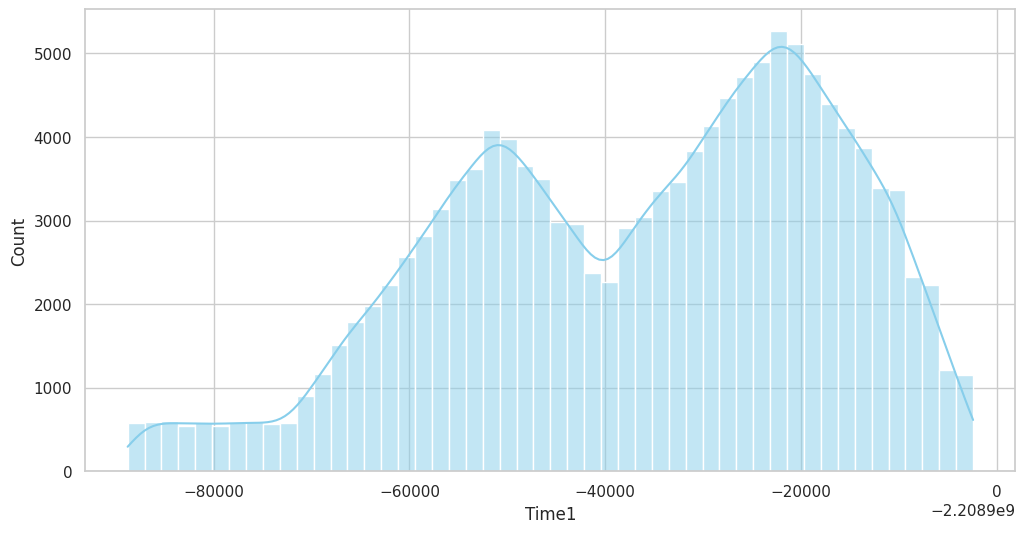

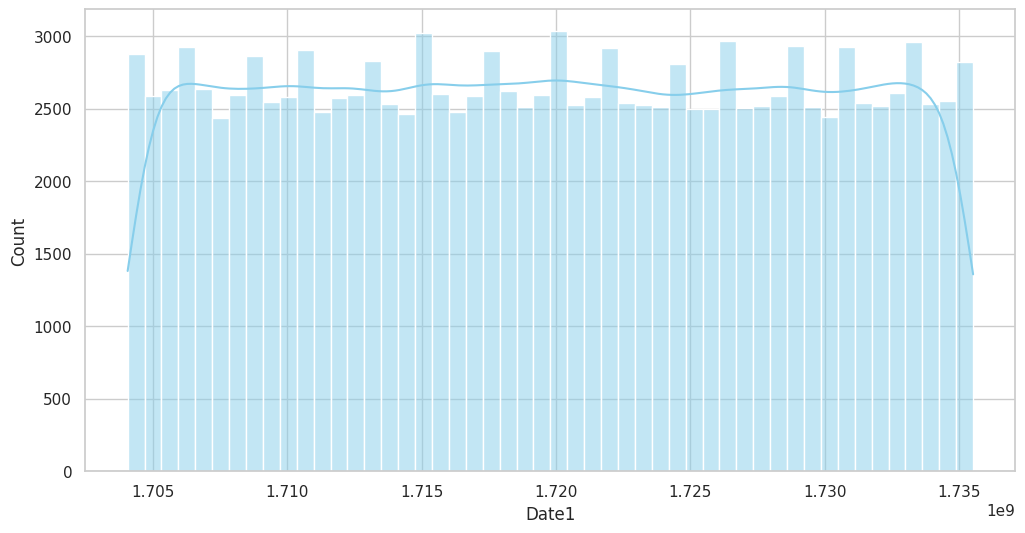

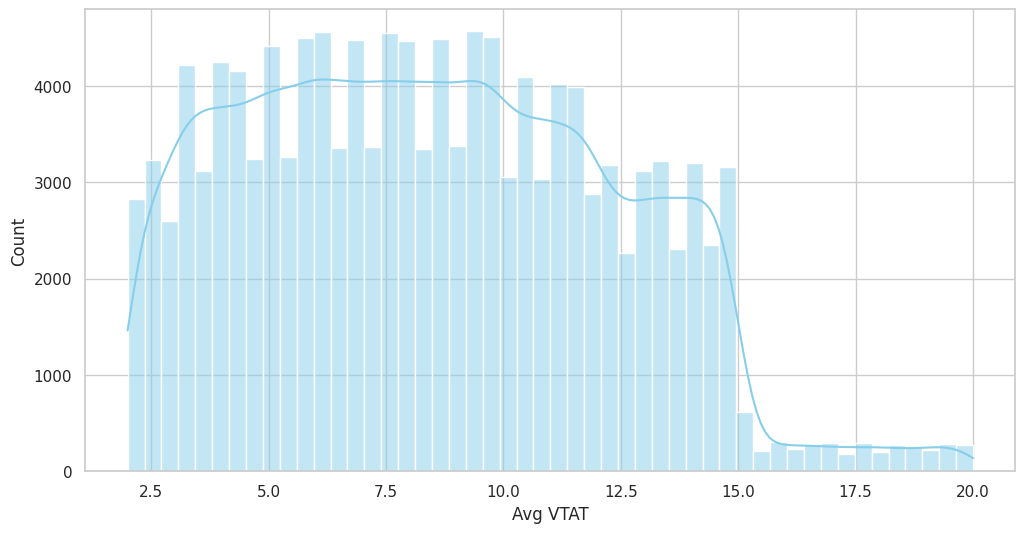

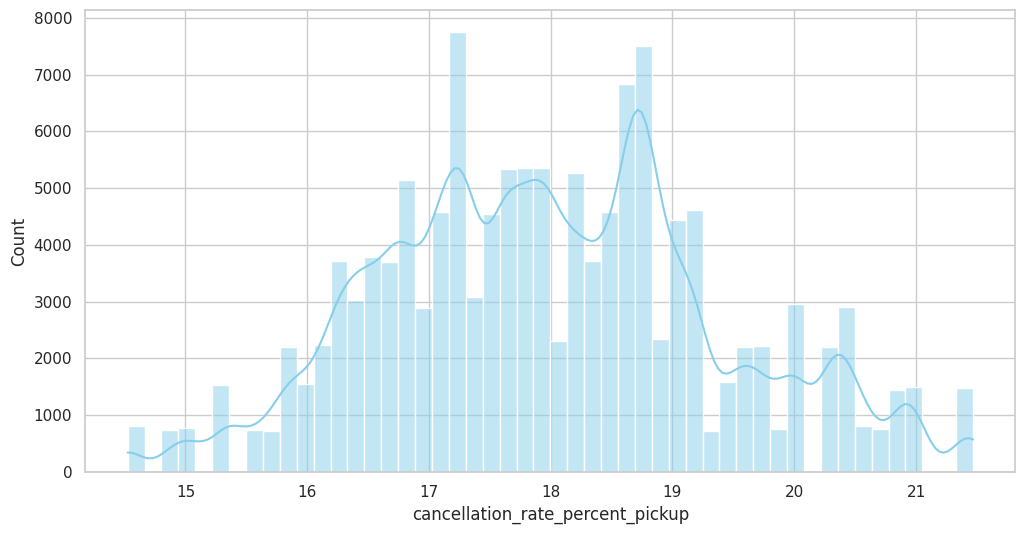

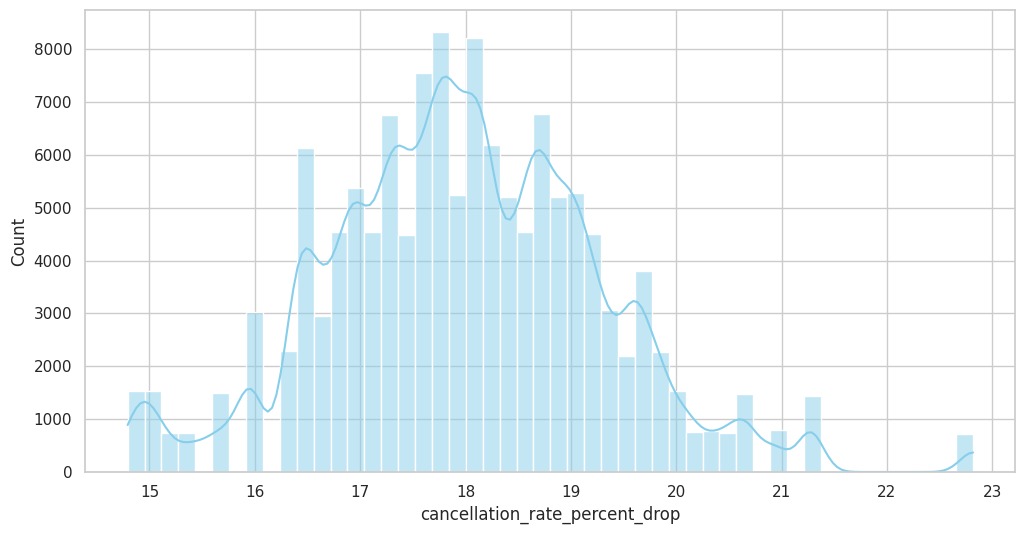

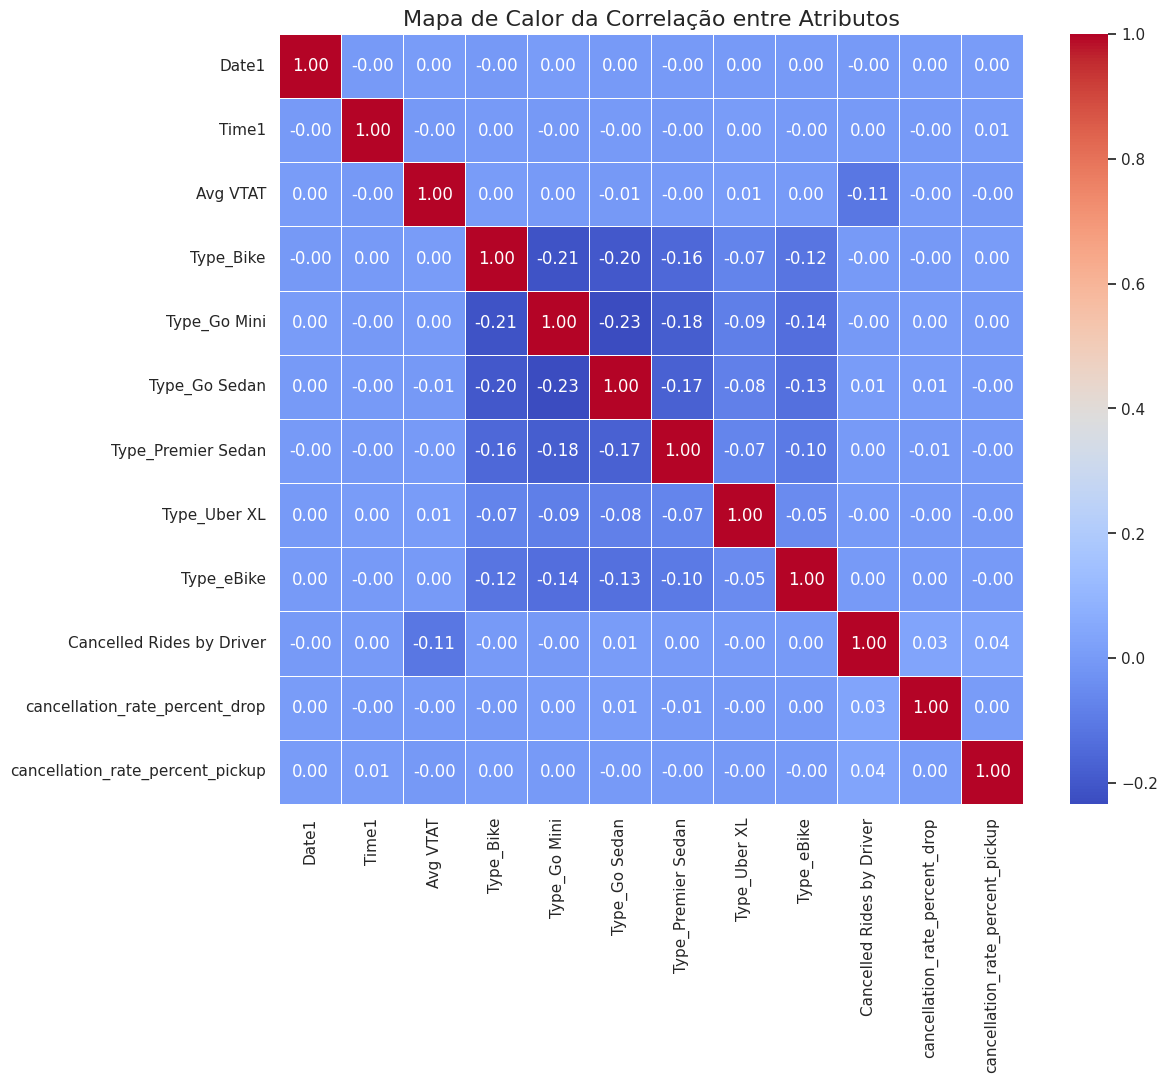

In [12]:
# Verificando o comportamento dos atributos

# Plotando as horas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.histplot(df_model_clean2['Time1'], kde=True, bins=50, color='skyblue')

# Plotando os dias
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.histplot(df_model_clean2['Date1'], kde=True, bins=50, color='skyblue')

# Plotando os tempos médios
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.histplot(df_model_clean2['Avg VTAT'], kde=True, bins=50, color='skyblue')

# Plotando os cancelamentos de coleta
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.histplot(df_model_clean2['cancellation_rate_percent_pickup'], kde=True, bins=50, color='skyblue')

# Plotando os cancelamentos de entrega
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.histplot(df_model_clean2['cancellation_rate_percent_drop'], kde=True, bins=50, color='skyblue')

#Preparo de dados para correlação
df_model_clean2['Cancelled Rides by Driver'] = df_model_clean2['Cancelled Rides by Driver'].fillna(0)
for col in df_model_clean2.columns:
    if df_model_clean2[col].dtype == 'bool':
        df_model_clean2[col] = df_model_clean2[col].astype(int)

df_model_clean2['Cancelled Rides by Driver'] = df_model_clean2['Cancelled Rides by Driver'].astype(int)

matriz_correlacao = df_model_clean2.corr()
correlacao_com_alvo = matriz_correlacao['Cancelled Rides by Driver']
correlacao_com_alvo_ordenada = correlacao_com_alvo.sort_values(ascending=False)
print("\n--- Correlação dos Atributos com 'Cancelled Rides by Driver' ---")
print(correlacao_com_alvo_ordenada)

plt.figure(figsize=(12, 10))
heatmap = sns.heatmap(matriz_correlacao,annot=True,cmap='coolwarm',fmt=".2f",linewidths=.5)

plt.title('Mapa de Calor da Correlação entre Atributos', fontsize=16)
plt.show()

#Finalização da análise exploratória
Nenhum atributo apresentou um comportamento de curva semelhante a uma curva normal. O mais próximo foi a taxa de cancelamento de entrega mas a curva não possui simetria construtiva. Os dados aparesentaram correlações muito baixas, sendo que apenas o tempo de espera, tipo sedan e as taxas de cancelamento não zeraram. Assumindo que o objetivo final é gerar um modelo que gere algum resultado que auxilie na prevenção dos cancelamentos vamos dar continuidade no processo preparando as amostras que serão utilizadas.

In [13]:
print(df_model_clean2.head())
# Separar features (X) e target (y)
X = df_model_clean2[['Date1', 'Time1', 'Avg VTAT', 'Type_Bike','Type_Go Mini','Type_Go Sedan', 'Type_Premier Sedan', 'Type_Uber XL', 'Type_eBike','cancellation_rate_percent_drop','cancellation_rate_percent_pickup']]
y = df_model_clean2['Cancelled Rides by Driver']
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")




        Date1       Time1  Avg VTAT  Type_Bike  Type_Go Mini  Type_Go Sedan  \
1  1732838400 -2208923901       4.9          0             0              1   
2  1724371200 -2208956630      13.4          0             0              0   
3  1729468800 -2208926555      13.1          0             0              0   
4  1726444800 -2208909120       5.3          1             0              0   
5  1707177600 -2208953704       5.1          0             0              0   

   Type_Premier Sedan  Type_Uber XL  Type_eBike  Cancelled Rides by Driver  \
1                   0             0           0                          0   
2                   0             0           0                          0   
3                   1             0           0                          0   
4                   0             0           0                          0   
5                   0             0           0                          0   

   cancellation_rate_percent_drop  cancellation_rate_per

#Avaliação prévia de modelos
Para entender os efeitos dos atributos, vou iniciar o treinamento de alguns modelos conhecidos na disciplina.
Nessa avaliação os dados foram testados originais, normalizados e padronizados, seguindo a mesma linha de raciocínio do exercício. A opinião do analista, com base na distribuição dos dados, o mais adequado seria a normalização, pois nenhum dado apresentou uma característica visual semelhante a uma curva normal, mas a fim de análise utilizaram-se as três alternativas.

Para essa análise foi feita uma alteração no critério de avaliação. Optou-se por medir o f1, precisão e recall para avaliar os valores pois é sabido que há uma possibilidade do modelo ficar enviesado por conta do desbalanceamento dos dados().

Avaliando que essa análise poderá ser repetida, primeiramente será feita a conversão do código aprendido em aula em uma função. Após serão avaliados os dados.

#Métricas
Com o objetivo de identificar cancelamentos, utilizaram-se duas variáveis. A primeira foi "f1" pois ela é uma métrica equilibrada em relação a "precisão" e o "recall", e a segunda será o "recall" pois o objetivo é encontrar as condições com maior risco de cancelamento.

#

In [14]:
# É sabido que essa função não vai salvar o modelo, portanto a estratégia adotada será investigar possibilidades e ao final gerar um modelo para salva-lo.
def executar_comparacao_modelos(X, y, models, scalers=None, kfold=None, scoring=None, plotar_resultados=True):

    #Define se alguma variável de entrada alterou
    if scalers is None:
        scalers = {}

    scalers_a_usar = {'orig': None}
    scalers_a_usar.update(scalers)

    if kfold is None:
        kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=7)

    if scoring is None:
        scoring = ['f1_macro', 'precision_macro', 'recall_macro']


    results_list = []
    print("Iniciando comparação de modelos...")

    #Analisa os modelos
    for model_name, model_obj in models.items():
        for scaler_name, scaler_obj in scalers_a_usar.items():

            pipeline_steps = []
            if scaler_obj is not None:
                pipeline_steps.append((scaler_name, scaler_obj))
            pipeline_steps.append((model_name, model_obj))
            pipeline = Pipeline(steps=pipeline_steps)
            pipeline_full_name = f"{model_name}-{scaler_name}"
            cv_results = cross_validate(pipeline, X, y, cv=kfold, scoring=scoring)
            print(f"--- {pipeline_full_name} ---")

            result_summary = {'pipeline_name': pipeline_full_name}

            for metric in scoring:
                mean_score = cv_results[f'test_{metric}'].mean()
                std_score = cv_results[f'test_{metric}'].std()
                result_summary[f'mean_{metric}'] = mean_score
                result_summary[f'std_{metric}'] = std_score
                result_summary[f'raw_{metric}'] = cv_results[f'test_{metric}']
                print(f"  {metric}: {mean_score:.3f} ({std_score:.3f})")

            results_list.append(result_summary)

    print("\nComparação finalizada!")
    results_df = pd.DataFrame(results_list)

    #Gera o gráfico para comparar
    if plotar_resultados:
        print("Gerando gráficos...")
        for metric in scoring:

            data_to_plot = results_df[f'raw_{metric}'].tolist()
            labels = results_df['pipeline_name'].tolist()
            plt.figure(figsize=(25, 8))
            plt.suptitle(f'Comparação dos Modelos ({metric})', fontsize=16)
            plt.boxplot(data_to_plot)
            plt.xticks(ticks=range(1, len(labels) + 1), labels=labels, rotation=90)
            plt.ylabel(metric.replace('_', ' ').title())
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

    return results_df




In [15]:


#Bloqueado por demorar demais
# base_decision_tree = DecisionTreeClassifier()
# num_trees = 100
# models_to_compare = {
#     'LR': LogisticRegression(max_iter=200),
#     'KNN': KNeighborsClassifier(),
#     'CART': DecisionTreeClassifier(),
#     'NB': GaussianNB(),
#     'SVM': SVC(),
#     'RF': RandomForestClassifier(n_estimators=num_trees),
#     'Ada': AdaBoostClassifier(n_estimators=num_trees)
# }

# scalers_to_compare = {
#     'padr': StandardScaler(),
#     'norm': MinMaxScaler()
# }

# df_resultados = executar_comparacao_modelos(X, y, models=models_to_compare, scalers=scalers_to_compare)

# colunas_resumo = ['pipeline_name'] + [f'mean_{s}' for s in ['f1_macro', 'precision_macro', 'recall_macro']]
# print(df_resultados[colunas_resumo])



#Resultados parciais

## Tabela de Resultados dos Modelos

| **Modelo** | **F1-Score (macro)** | **Precision (macro)** | **Recall (macro)** |
|:---|:---:|:---:|:---:|
| LR-orig | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| LR-padr | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| LR-norm | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| KNN-orig | 0.474 (0.002) | 0.493 (0.007) | 0.499 (0.001) |
| KNN-padr | 0.496 (0.003) | 0.529 (0.007) | 0.509 (0.002) |
| KNN-norm | 0.495 (0.003) | 0.526 (0.008) | 0.508 (0.002) |
| CART-orig | 0.538 (0.004) | 0.536 (0.004) | 0.540 (0.004) |
| CART-padr | 0.533 (0.006) | 0.532 (0.006) | 0.535 (0.007) |
| CART-norm | 0.535 (0.005) | 0.534 (0.005) | 0.537 (0.005) |
| NB-orig | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| NB-padr | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| NB-norm | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| SVM-orig | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| SVM-padr | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| SVM-norm | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| RF-orig | 0.461 (0.001) | 0.592 (0.043) | 0.501 (0.000) |
| RF-padr | 0.461 (0.001) | 0.567 (0.051) | 0.501 (0.001) |
| RF-norm | 0.460 (0.001) | 0.545 (0.052) | 0.500 (0.001) |
| Ada-orig | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| Ada-padr | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |
| Ada-norm | 0.459 (0.000) | 0.424 (0.000) | 0.500 (0.000) |




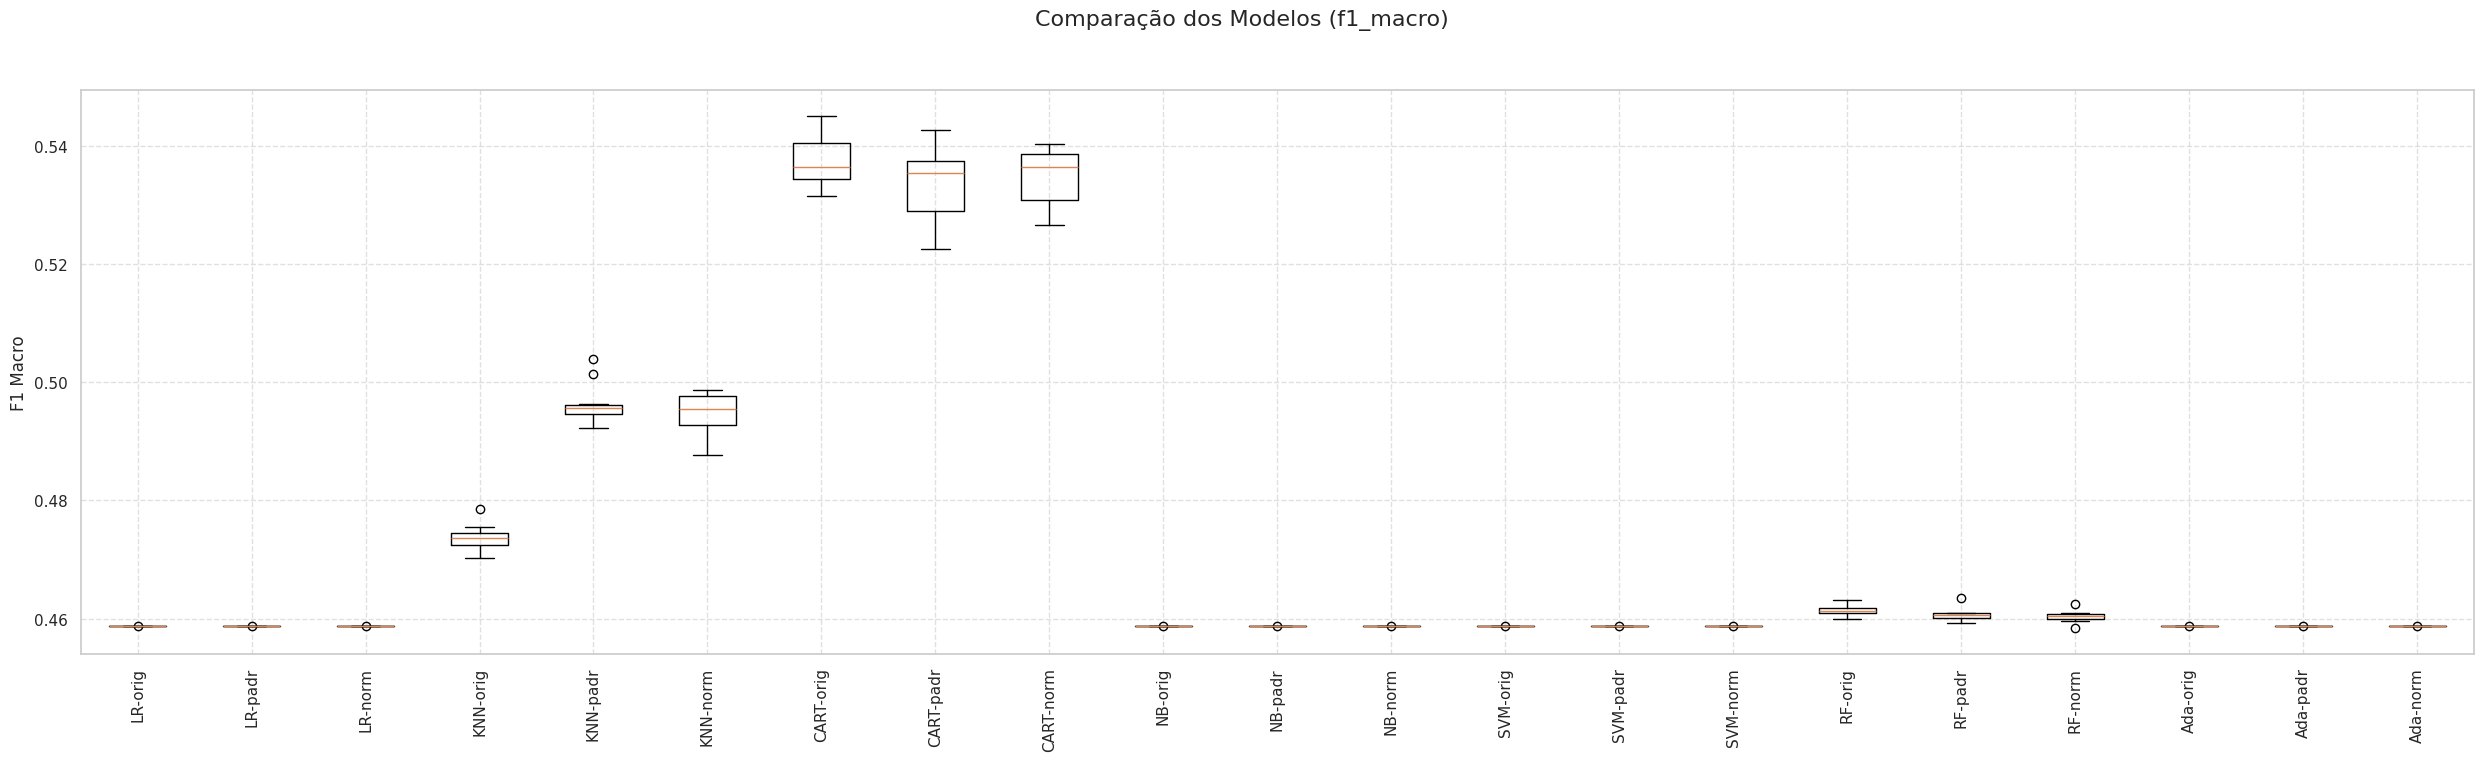

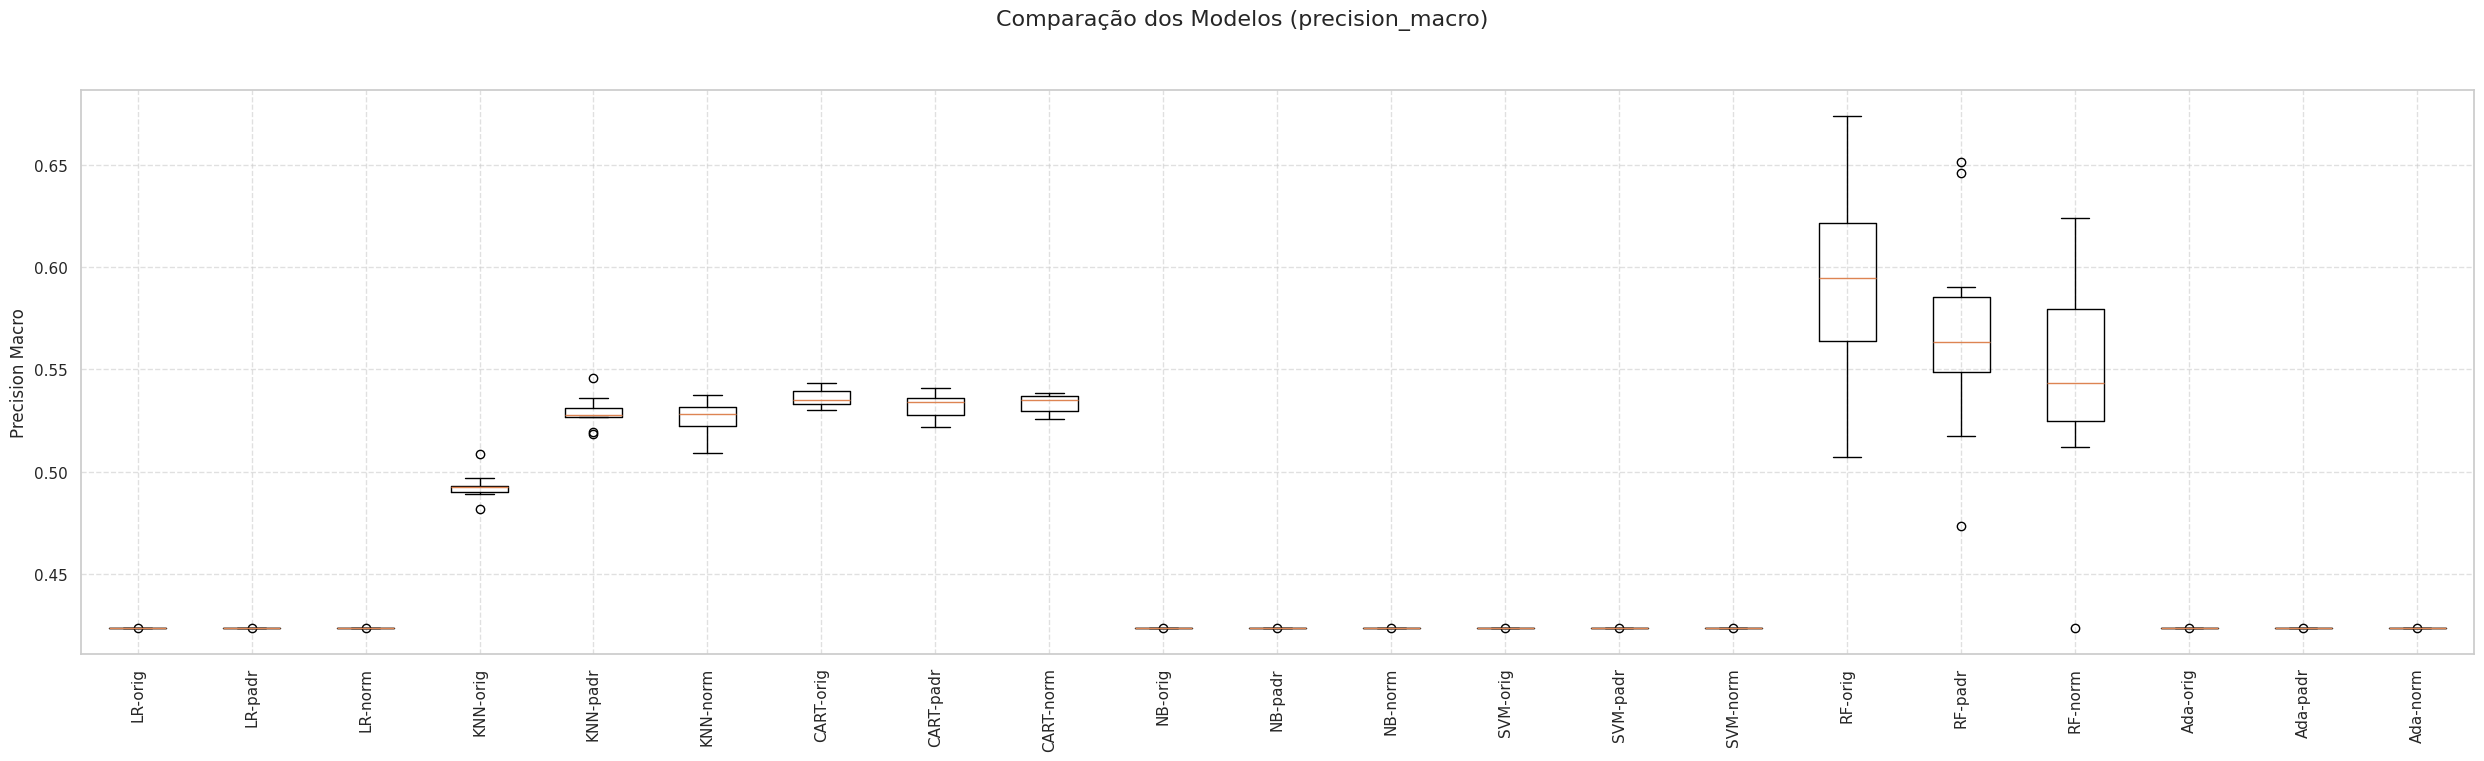

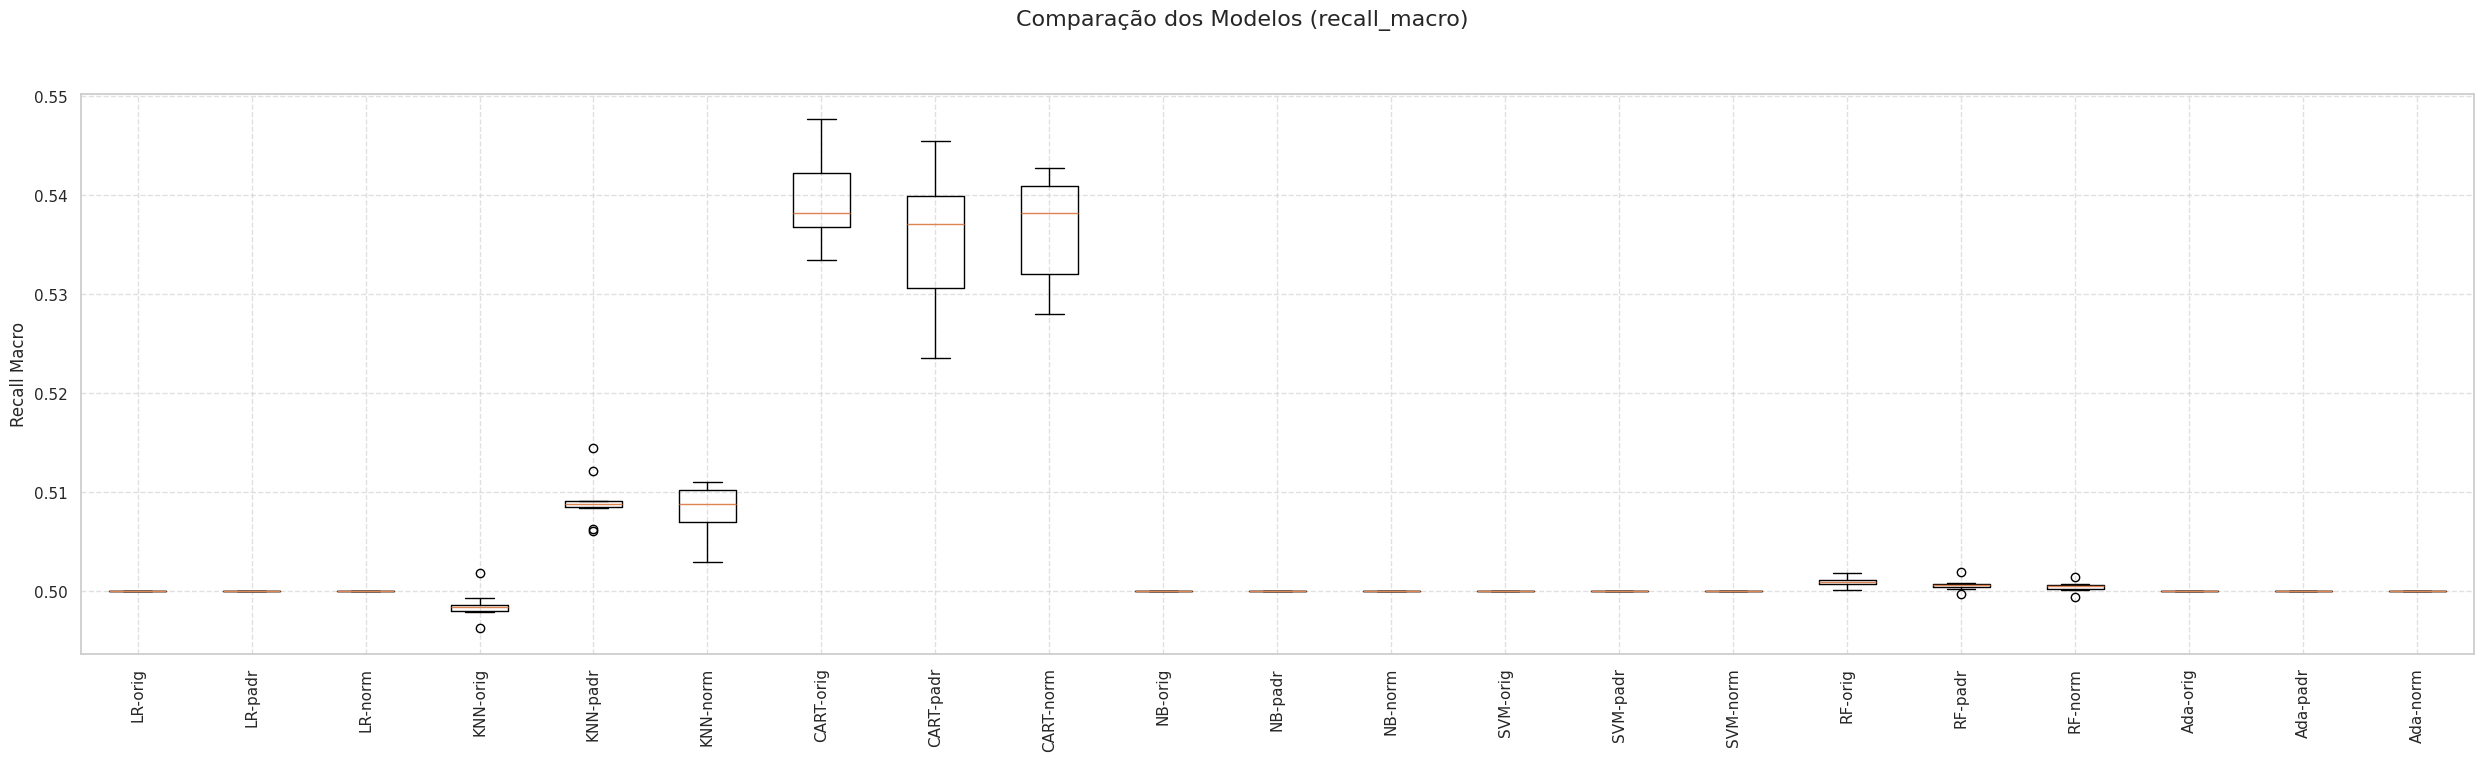

#Análise com rede neural

Para comparar os modelos vou treinar também uma rede neural para entender se é possível melhorar os resultados. Para esse treinamento vou criar três tipos de treinamento. Um pequeno com dois layer, um médio com três e um grande com quatro layers. Todos eles possuem um gráfico de histórico e uma matriz de confusão. O gráfico de histórico tem o objetivo de identificar se posso ou não reduzir as "epochs". Como alguns treinamentos ocorrem em série em longos periodos pode ser que esteja um valor de "epochs" desnecessário. Quando a matriz, sera gerada mas não será registrada na caixa de texto que vou salvar os resultados parciais. Isso porque eu vou salvar os valores para otimizar o tamanho do notebook.

In [16]:
def treinar_e_avaliar_rede_neural_peq(X_train, y_train, X_test, y_test, optimizer='adam', loss='binary_crossentropy', epochs=40, batch_size=32):

    input_dim = X_train.shape[1]
    modelo = keras.Sequential([
        layers.Dense(units=8, activation='relu', input_shape=(input_dim,)),
        layers.Dense(units=1, activation='sigmoid')
    ])

    print("\nResumo do Modelo:")
    modelo.summary()

    #Compilação do Modelo

    print(f"\nCompilando o modelo com optimizer='{optimizer}' and loss='{loss}'...")
    modelo.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    #Treinamento do Modelo

    print(f"\nIniciando o treinamento por {epochs} épocas com batch_size={batch_size}...")
    history = modelo.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        verbose=1
    )

    #Avaliação e Métricas

    print("\n--- Resultados da Avaliação no Conjunto de Teste ---")
    loss_teste, accuracy_teste = modelo.evaluate(X_test, y_test, verbose=0)
    print(f"Acurácia no conjunto de teste: {accuracy_teste:.4f}")


    y_pred_probs = modelo.predict(X_test)
    y_pred_classes = (y_pred_probs > 0.5).astype(int)

    f1 = f1_score(y_test, y_pred_classes)
    print(f"F1-Score no conjunto de teste: {f1:.4f}")

    print("\nRelatório de Classificação Detalhado:")
    print(classification_report(y_test, y_pred_classes))

    #Plot do Histórico

    print("\nGerando gráfico do histórico de treinamento...")
    pd.DataFrame(history.history).plot(figsize=(10, 6), title="Histórico de Treinamento (Loss e Acurácia)")
    plt.grid(True)
    plt.gca().set_ylim(0, 1)
    plt.xlabel("Épocas")
    plt.ylabel("Valor")
    plt.show()

    conf_matrix = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm')
    plt.title('Matriz de Confusão')
    plt.xlabel('Predito')
    plt.ylabel('Verdadeiro')
    plt.show()

    print("\n--- Processo Finalizado ---")


    return modelo, history

def treinar_e_avaliar_rede_neural_med(X_train, y_train, X_test, y_test, optimizer='adam', loss='binary_crossentropy', epochs=40, batch_size=32):

    input_dim = X_train.shape[1]
    modelo = keras.Sequential([
        layers.Dense(units=16, activation='relu', input_shape=(input_dim,)),
        layers.Dense(units=8, activation='relu'),
        layers.Dense(units=1, activation='sigmoid')
    ])

    print("\nResumo do Modelo:")
    modelo.summary()

    #Compilação do Modelo

    print(f"\nCompilando o modelo com optimizer='{optimizer}' and loss='{loss}'...")
    modelo.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    #Treinamento do Modelo

    print(f"\nIniciando o treinamento por {epochs} épocas com batch_size={batch_size}...")
    history = modelo.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        verbose=1
    )

    #Avaliação e Métricas

    print("\n--- Resultados da Avaliação no Conjunto de Teste ---")
    loss_teste, accuracy_teste = modelo.evaluate(X_test, y_test, verbose=0)
    print(f"Acurácia no conjunto de teste: {accuracy_teste:.4f}")


    y_pred_probs = modelo.predict(X_test)
    y_pred_classes = (y_pred_probs > 0.5).astype(int)

    f1 = f1_score(y_test, y_pred_classes)
    print(f"F1-Score no conjunto de teste: {f1:.4f}")

    print("\nRelatório de Classificação Detalhado:")
    print(classification_report(y_test, y_pred_classes))

    #Plot do Histórico

    print("\nGerando gráfico do histórico de treinamento...")
    pd.DataFrame(history.history).plot(figsize=(10, 6), title="Histórico de Treinamento (Loss e Acurácia)")
    plt.grid(True)
    plt.gca().set_ylim(0, 1)
    plt.xlabel("Épocas")
    plt.ylabel("Valor")
    plt.show()

    conf_matrix = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm')
    plt.title('Matriz de Confusão')
    plt.xlabel('Predito')
    plt.ylabel('Verdadeiro')
    plt.show()

    print("\n--- Processo Finalizado ---")


    return modelo, history


def treinar_e_avaliar_rede_neural_gra(X_train, y_train, X_test, y_test, optimizer='adam', loss='binary_crossentropy', epochs=40, batch_size=32):

    input_dim = X_train.shape[1]
    modelo = keras.Sequential([
        layers.Dense(units=32, activation='relu', input_shape=(input_dim,)),
        layers.Dense(units=16, activation='relu'),
        layers.Dense(units=8, activation='relu'),
        layers.Dense(units=1, activation='sigmoid')
    ])

    print("\nResumo do Modelo:")
    modelo.summary()

    #Compilação do Modelo

    print(f"\nCompilando o modelo com optimizer='{optimizer}' and loss='{loss}'...")
    modelo.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    #Treinamento do Modelo

    print(f"\nIniciando o treinamento por {epochs} épocas com batch_size={batch_size}...")
    history = modelo.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        verbose=1
    )

    #Avaliação e Métricas

    print("\n--- Resultados da Avaliação no Conjunto de Teste ---")
    loss_teste, accuracy_teste = modelo.evaluate(X_test, y_test, verbose=0)
    print(f"Acurácia no conjunto de teste: {accuracy_teste:.4f}")


    y_pred_probs = modelo.predict(X_test)
    y_pred_classes = (y_pred_probs > 0.5).astype(int)

    f1 = f1_score(y_test, y_pred_classes)
    print(f"F1-Score no conjunto de teste: {f1:.4f}")

    print("\nRelatório de Classificação Detalhado:")
    print(classification_report(y_test, y_pred_classes))

    #Plot do Histórico

    print("\nGerando gráfico do histórico de treinamento...")
    pd.DataFrame(history.history).plot(figsize=(10, 6), title="Histórico de Treinamento (Loss e Acurácia)")
    plt.grid(True)
    plt.gca().set_ylim(0, 1)
    plt.xlabel("Épocas")
    plt.ylabel("Valor")
    plt.show()


    conf_matrix = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm')
    plt.title('Matriz de Confusão')
    plt.xlabel('Predito')
    plt.ylabel('Verdadeiro')
    plt.show()

    print("\n--- Processo Finalizado ---")


    return modelo, history




In [17]:
#Bloqueado por demorar demais
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# modelo_treinado_gra, historico_gra = treinar_e_avaliar_rede_neural_gra(
#     X_train=X_train_scaled,
#     y_train=y_train,
#     X_test=X_test_scaled,
#     y_test=y_test,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=50,
#     batch_size=32
# )



#Resultados parciais

Acurácia no conjunto de teste: 0.8475

F1-Score no conjunto de teste: 0.0000


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.85 | 1.00 | 0.92 | 33750 |
| 1 | 0.00 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.85** | **39825** |
| **macro avg** | 0.42 | 0.50 | 0.46 | 39825 |
| **weighted avg** | 0.72 | 0.85 | 0.78 | 39825 |


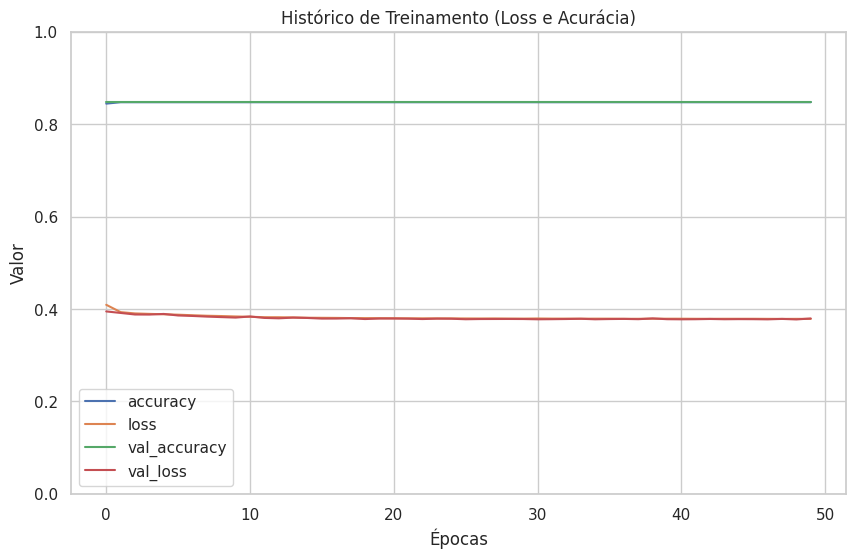

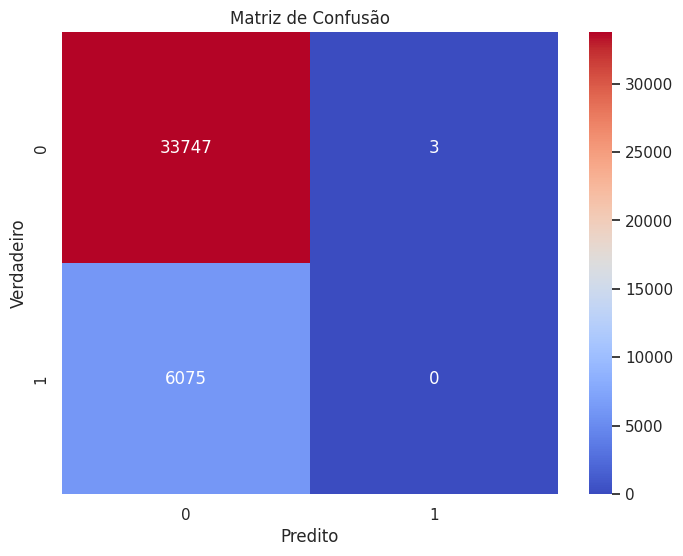


In [18]:
#Bloqueado por demorar demais
# modelo_treinado_med, historico_med = treinar_e_avaliar_rede_neural_med(
#     X_train=X_train_scaled,
#     y_train=y_train,
#     X_test=X_test_scaled,
#     y_test=y_test,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=50,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.8475

F1-Score no conjunto de teste: 0.0000


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.85 | 1.00 | 0.92 | 33750 |
| 1 | 0.00 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.85** | **39825** |
| **macro avg** | 0.42 | 0.50 | 0.46 | 39825 |
| **weighted avg** | 0.72 | 0.85 | 0.78 | 39825 |

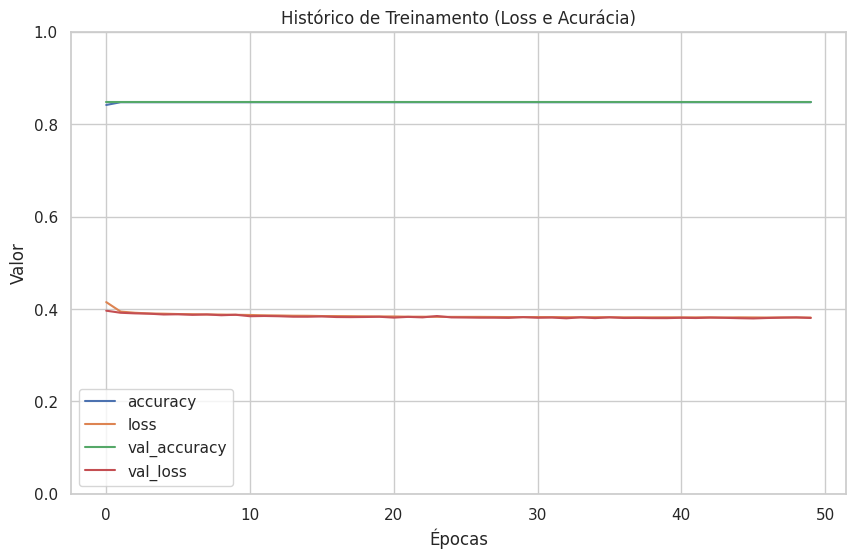

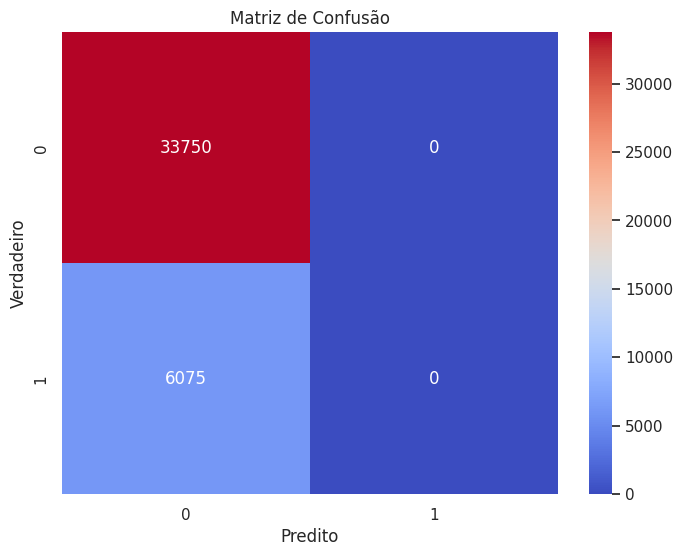

In [19]:
#Bloqueado por demorar demais
# modelo_treinado_peq, historico_peq = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled,
#     y_train=y_train,
#     X_test=X_test_scaled,
#     y_test=y_test,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=50,
#     batch_size=32
# )


#Resultados parciais

Acurácia no conjunto de teste: 0.8473

F1-Score no conjunto de teste: 0.0003

### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.85 | 1.00 | 0.92 | 33750 |
| 1 | 0.10 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.85** | **39825** |
| **macro avg** | 0.47 | 0.50 | 0.46 | 39825 |
| **weighted avg** | 0.73 | 0.85 | 0.78 | 39825 |

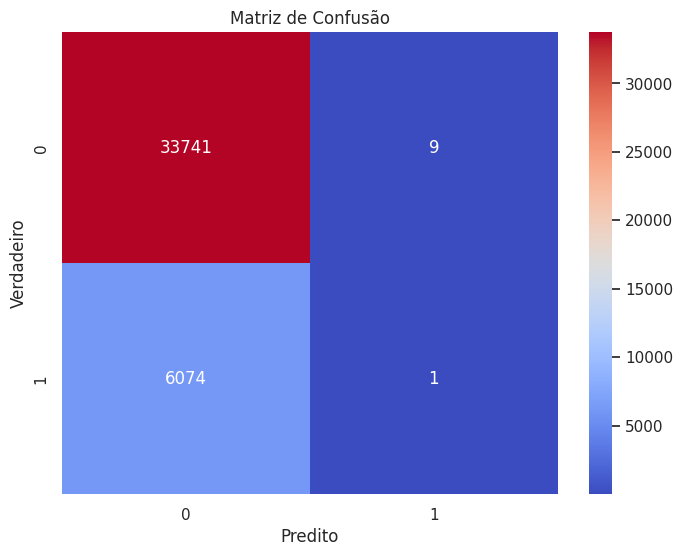

In [20]:
#Bloqueado por demorar demais
# scaler2 = MinMaxScaler()
# X_train_scaled2 = scaler2.fit_transform(X_train)
# X_test_scaled2 = scaler2.transform(X_test)

# modelo_treinado_gra_min, historico_gra_min = treinar_e_avaliar_rede_neural_gra(
#     X_train=X_train_scaled2,
#     y_train=y_train,
#     X_test=X_test_scaled2,
#     y_test=y_test,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=50,
#     batch_size=32
# )


#Resultados parciais

Acurácia no conjunto de teste: 0.8475

F1-Score no conjunto de teste: 0.0000

### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.85 | 1.00 | 0.92 | 33750 |
| 1 | 0.00 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.85** | **39825** |
| **macro avg** | 0.42 | 0.50 | 0.46 | 39825 |
| **weighted avg** | 0.72 | 0.85 | 0.78 | 39825 |

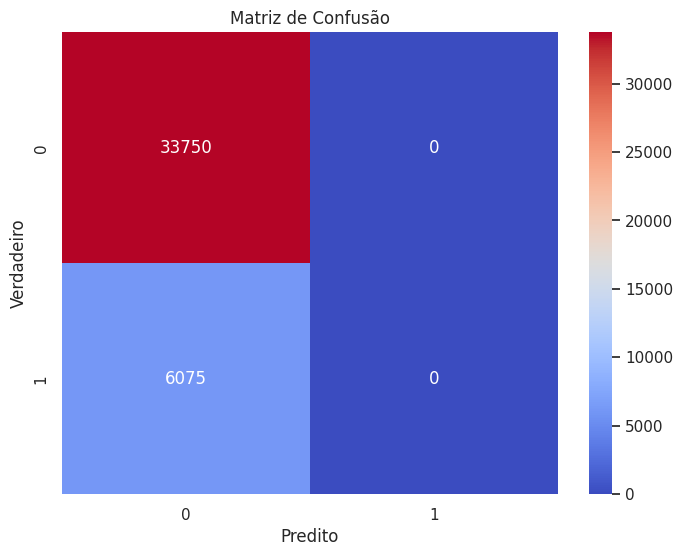

In [21]:
#Bloqueado por demorar demais
# modelo_treinado_med_min, historico_med_min = treinar_e_avaliar_rede_neural_med(
#     X_train=X_train_scaled2,
#     y_train=y_train,
#     X_test=X_test_scaled2,
#     y_test=y_test,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=50,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.8475

F1-Score no conjunto de teste: 0.0003


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.85 | 1.00 | 0.92 | 33750 |
| 1 | 0.00 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.85** | **39825** |
| **macro avg** | 0.42 | 0.50 | 0.46 | 39825 |
| **weighted avg** | 0.72 | 0.85 | 0.78 | 39825 |

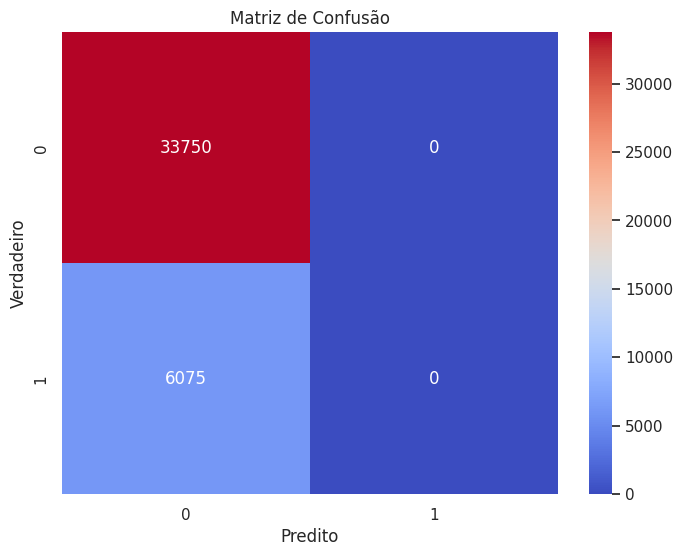

In [22]:
#Bloqueado por demorar demais
# modelo_treinado_peq_min, historico_peq_min = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled2,
#     y_train=y_train,
#     X_test=X_test_scaled2,
#     y_test=y_test,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=50,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.8475

F1-Score no conjunto de teste: 0.0000


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.85 | 1.00 | 0.92 | 33750 |
| 1 | 0.00 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.85** | **39825** |
| **macro avg** | 0.42 | 0.50 | 0.46 | 39825 |
| **weighted avg** | 0.72 | 0.85 | 0.78 | 39825 |

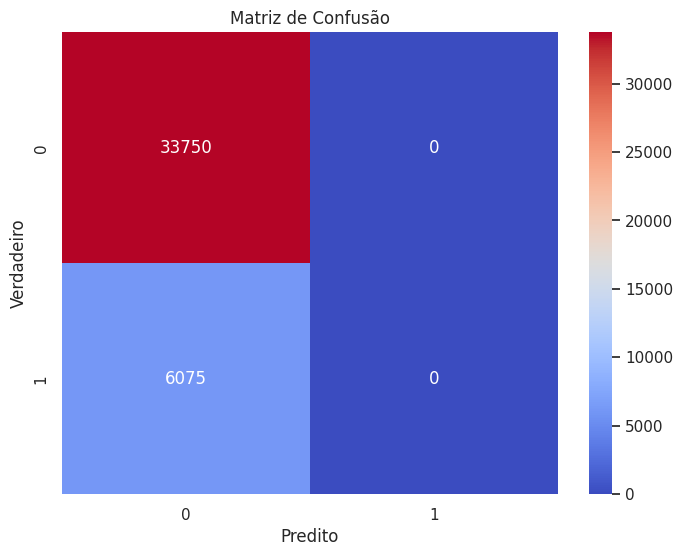

#Análise dos resultados

Na análise inicial dos modelos, os valores de precisão, f1 e recall ficaram bem baixos ~0,5. O melhor resultado foi obtido com árvore de classificação e regressão(CART) e original mas entende-se que é necessário explorar mais alternativas para identificar oportunidades de melhoria.

Os resultados das redes neurais são positivos para detectar o 0 mas conforme as matrizes de confusão demonstra, provavelmente o modelo está ignorando os casos com atrasos por conta do baixo número de cancelamentos. Apenas alguns modelos não zeraram a previsão de atraso mas com resultados ainda muito ruins. Para tentar melhorar a qualidade do modelo, a quantidade de dados sem cancelamentos será reduzida aleatóriamente e os processos da última análise serão repetidos para identificar o efeito do balanceamento.

In [23]:
#Preparo dos dados
df_maioria = df_model_clean2[df_model_clean2['Cancelled Rides by Driver'] == 0]
df_minoria = df_model_clean2[df_model_clean2['Cancelled Rides by Driver'] == 1]
df_maioria_reduzido = df_maioria.sample(n=47248, random_state=42) #Utilizei o valor de 20249 chamadas canceladas pelo motorista como referencia. A partir dela calculei uma relação de 70/30 para definir quantos dados de chamadas não canceladas deveriam sobrar.
df_balanceado = pd.concat([df_maioria_reduzido, df_minoria])
df_balanceado = df_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)
print(df_balanceado.head())
print(df_balanceado.info())

#Repetindo o processo

# Separar features (X) e target (y)
X2 = df_balanceado[['Date1', 'Time1', 'Avg VTAT', 'Type_Bike','Type_Go Mini','Type_Go Sedan', 'Type_Premier Sedan', 'Type_Uber XL', 'Type_eBike','cancellation_rate_percent_drop','cancellation_rate_percent_pickup']]
y2 = df_balanceado['Cancelled Rides by Driver']
# Dividir os dados em conjuntos de treino e teste
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.3, random_state=42, stratify=y2)
print(f"Dimensões de X_train2: {X_train2.shape}")
print(f"Dimensões de X_test2: {X_test2.shape}")
print(f"Dimensões de y_train2: {y_train2.shape}")
print(f"Dimensões de y_test2: {y_test2.shape}")




        Date1       Time1  Avg VTAT  Type_Bike  Type_Go Mini  Type_Go Sedan  \
0  1704672000 -2208919772       3.6          1             0              0   
1  1711929600 -2208958541       6.5          0             1              0   
2  1709337600 -2208911976       9.2          0             0              0   
3  1722124800 -2208966620      10.9          0             1              0   
4  1735171200 -2208937528       5.8          0             0              0   

   Type_Premier Sedan  Type_Uber XL  Type_eBike  Cancelled Rides by Driver  \
0                   0             0           0                          1   
1                   0             0           0                          1   
2                   1             0           0                          1   
3                   0             0           0                          0   
4                   0             0           0                          0   

   cancellation_rate_percent_drop  cancellation_rate_per

In [24]:
#Bloqueado por demorar demais

#Parte repetida pois não consegui rodar tudo no mesmo dia
# base_decision_tree = DecisionTreeClassifier()
# num_trees = 100
# models_to_compare = {
#     'LR': LogisticRegression(max_iter=200),
#     'KNN': KNeighborsClassifier(),
#     'CART': DecisionTreeClassifier(),
#     'NB': GaussianNB(),
#     'SVM': SVC(),
#     'RF': RandomForestClassifier(n_estimators=num_trees),
#     'Ada': AdaBoostClassifier(n_estimators=num_trees)
# }

# scalers_to_compare = {
#     'padr': StandardScaler(),
#     'norm': MinMaxScaler()
# }
# df_resultados2 = executar_comparacao_modelos(X2, y2, models=models_to_compare, scalers=scalers_to_compare)

# colunas_resumo2 = ['pipeline_name'] + [f'mean_{s}' for s in ['f1_macro', 'precision_macro', 'recall_macro']]
# print(df_resultados2[colunas_resumo2])

#Resultados parciais


| Modelo | Pré-processamento | F1 Macro | Precision Macro | Recall Macro |
| :--- | :--- | :--- | :--- | :--- |
| LR | orig | 0.412 (0.000) | 0.350 (0.000) | 0.500 (0.000) |
| LR | padr | 0.412 (0.000) | 0.393 (0.079) | 0.500 (0.000) |
| LR | norm | 0.412 (0.000) | 0.393 (0.079) | 0.500 (0.000) |
| KNN | orig | 0.484 (0.006) | 0.497 (0.007) | 0.498 (0.005) |
| KNN | padr | 0.534 (0.005) | 0.545 (0.006) | 0.536 (0.004) |
| KNN | norm | 0.532 (0.005) | 0.543 (0.006) | 0.534 (0.005) |
| CART | orig | 0.559 (0.007) | 0.559 (0.008) | 0.560 (0.007) |
| CART | padr | 0.560 (0.006) | 0.559 (0.006) | 0.560 (0.006) |
| CART | norm | 0.561 (0.007) | 0.560 (0.007) | 0.561 (0.007) |
| NB | orig | 0.412 (0.000) | 0.350 (0.000) | 0.500 (0.000) |
| NB | padr | 0.417 (0.002) | 0.593 (0.053) | 0.501 (0.001) |
| NB | norm | 0.417 (0.002) | 0.593 (0.053) | 0.501 (0.001) |
| SVM | orig | 0.412 (0.000) | 0.350 (0.000) | 0.500 (0.000) |
| SVM | padr | 0.412 (0.000) | 0.350 (0.000) | 0.500 (0.000) |
| SVM | norm | 0.412 (0.000) | 0.350 (0.000) | 0.500 (0.000) |
| RF | orig | 0.488 (0.006) | 0.545 (0.009) | 0.517 (0.004) |
| RF | padr | 0.491 (0.005) | 0.552 (0.007) | 0.520 (0.003) |
| RF | norm | 0.488 (0.006) | 0.548 (0.010) | 0.518 (0.004) |
| Ada | orig | 0.412 (0.000) | 0.350 (0.000) | 0.500 (0.000) |
| Ada | padr | 0.412 (0.000) | 0.350 (0.000) | 0.500 (0.000) |
| Ada | norm | 0.412 (0.000) | 0.350 (0.000) | 0.500 (0.000) |



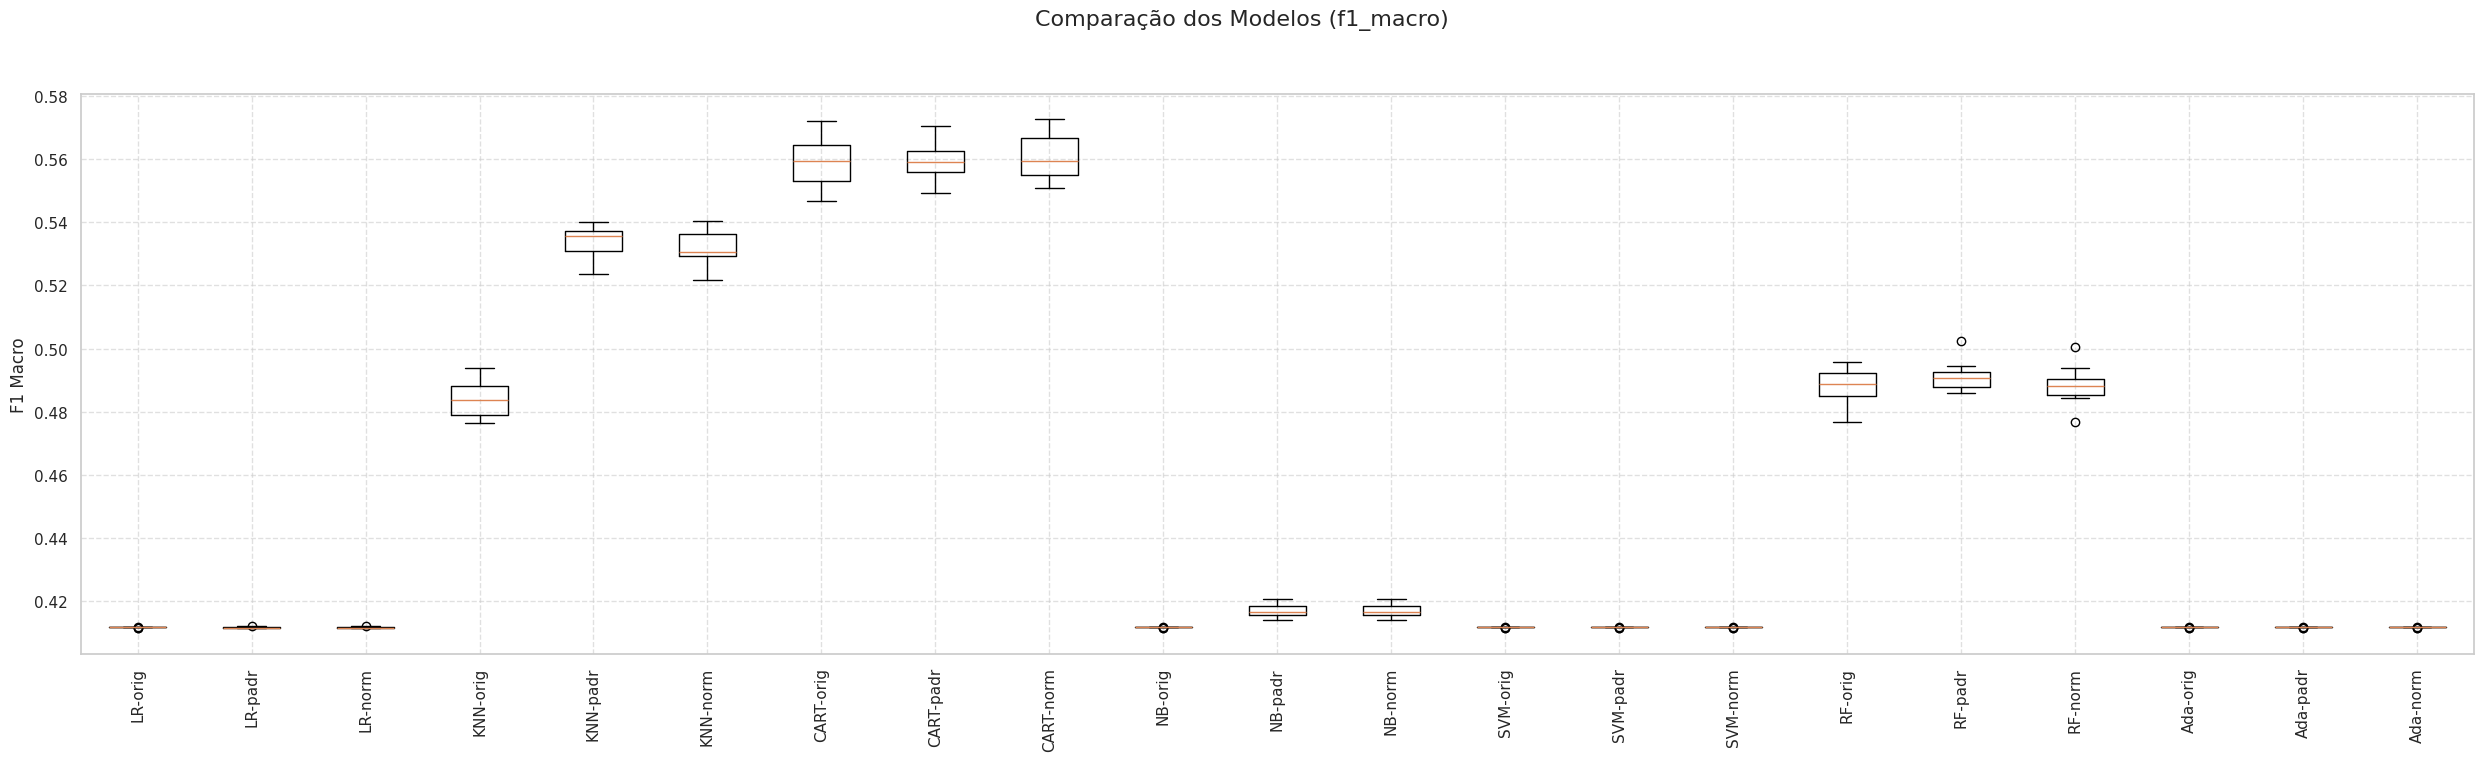


In [25]:
#Bloqueado por demorar demais
scaler3 = MinMaxScaler()
X_train_scaled3 = scaler3.fit_transform(X_train2)
X_test_scaled3 = scaler3.transform(X_test2)

#Do resultado obtido anteriormente, identificou-se que os resultados não mudaram por conta da quantidade e layers, então serão alteradas outras variáveis.
#Outra mudança foi a alteração da quantidade de epochs para 20 pois aparentemente a curva já fica estável com esse valor.
# modelo_treinado_peq2, historico_peq2 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled3,
#     y_train=y_train2,
#     X_test=X_test_scaled3,
#     y_test=y_test2,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=20,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.6998

F1-Score no conjunto de teste: 0.0000



### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.70 | 1.00 | 0.82 | 14175 |
| 1 | 0.00 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.70** | **20250** |
| **macro avg** | 0.35 | 0.50 | 0.41 | 20250 |
| **weighted avg** | 0.49 | 0.70 | 0.58 | 20250 |

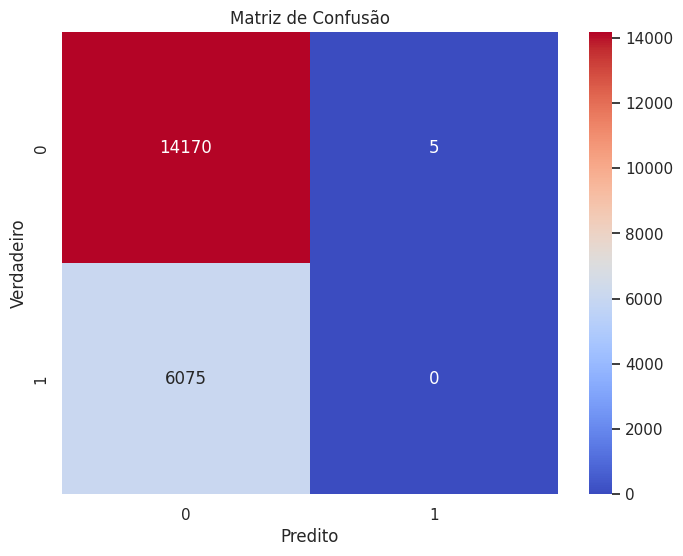

In [26]:
#Bloqueado por demorar demais
# modelo_treinado_peq3, historico_peq3 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled3,
#     y_train=y_train2,
#     X_test=X_test_scaled3,
#     y_test=y_test2,
#     optimizer='RMSprop',
#     loss='binary_crossentropy',
#     epochs=20,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.6997

F1-Score no conjunto de teste: 0.0020



### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.70 | 1.00 | 0.82 | 14175 |
| 1 | 0.33 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.70** | **20250** |
| **macro avg** | 0.52 | 0.50 | 0.41 | 20250 |
| **weighted avg** | 0.59 | 0.70 | 0.58 | 20250 |

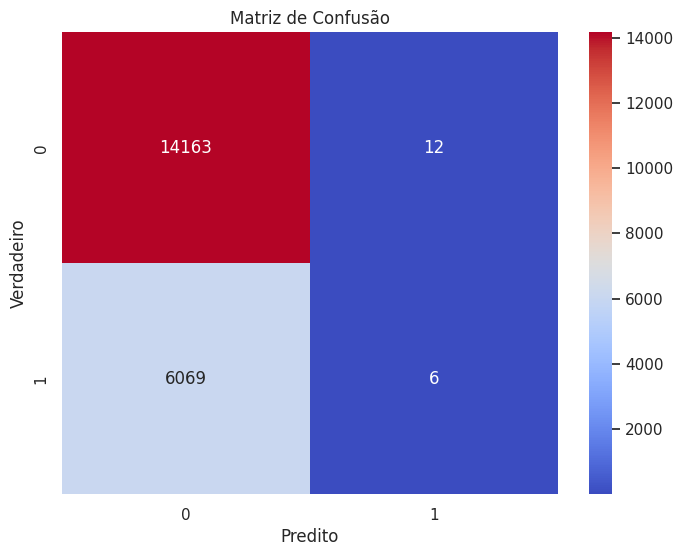

In [27]:
#Bloqueado por demorar demais
# modelo_treinado_peq4, historico_peq4 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled3,
#     y_train=y_train2,
#     X_test=X_test_scaled3,
#     y_test=y_test2,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=20,
#     batch_size=64
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.7000

F1-Score no conjunto de teste: 0.0000

### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.70 | 1.00 | 0.82 | 14175 |
| 1 | 0.00 | 0.00 | 0.00 | 6075 |
| **accuracy** | | | **0.70** | **20250** |
| **macro avg** | 0.35 | 0.50 | 0.41 | 20250 |
| **weighted avg** | 0.49 | 0.70 | 0.58 | 20250 |

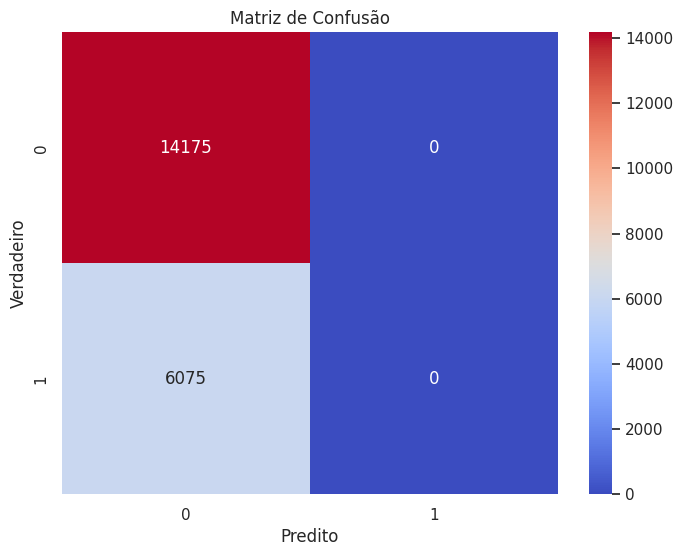

#Análise dos resultados
Na avaliação dos modelos, novamente o modelo CART se destacou mas com dados normalizados. Porém acredita-se na possibilidade de melhorar ainda mais os resultados.

Na avaliação da rede neural houve uma redução na acurácia sem melhorar os resultados na identificação de cancelamentos, mesmo alterando o número do *batch_size* ou o tipo do *optimizer*. Para tentar melhorar o resultado dividiu-se os dados em 50/50 com o objetivo de avaliar o impacto dos dados balanceados.

In [28]:
#Preparo dos dados
df_maioria2 = df_model_clean2[df_model_clean2['Cancelled Rides by Driver'] == 0]
df_minoria2 = df_model_clean2[df_model_clean2['Cancelled Rides by Driver'] == 1]
df_maioria_reduzido2 = df_maioria2.sample(n=20249, random_state=42) #Utilizei o valor de 20249 chamadas canceladas pelo motorista como referencia. A partir dela calculei uma relação de 70/30 para definir quantos dados de chamadas não canceladas deveriam sobrar.
df_balanceado2 = pd.concat([df_maioria_reduzido2, df_minoria2])
df_balanceado2 = df_balanceado2.sample(frac=1, random_state=42).reset_index(drop=True)
print(df_balanceado2.head())
print(df_balanceado2.info())

#Repetindo o processo

# Separar features (X) e target (y)
X3 = df_balanceado2[['Date1', 'Time1', 'Avg VTAT', 'Type_Bike','Type_Go Mini','Type_Go Sedan', 'Type_Premier Sedan', 'Type_Uber XL', 'Type_eBike','cancellation_rate_percent_drop','cancellation_rate_percent_pickup']]
y3 = df_balanceado2['Cancelled Rides by Driver']
# Dividir os dados em conjuntos de treino e teste
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.3, random_state=42, stratify=y3)
print(f"Dimensões de X_train2: {X_train3.shape}")
print(f"Dimensões de X_test2: {X_test3.shape}")
print(f"Dimensões de y_train2: {y_train3.shape}")
print(f"Dimensões de y_test2: {y_test3.shape}")

        Date1       Time1  Avg VTAT  Type_Bike  Type_Go Mini  Type_Go Sedan  \
0  1721260800 -2208962687      12.2          0             0              0   
1  1723766400 -2208909806      10.0          0             1              0   
2  1710806400 -2208916618       6.3          1             0              0   
3  1704326400 -2208981040       7.2          0             0              0   
4  1727913600 -2208929950       4.5          0             0              1   

   Type_Premier Sedan  Type_Uber XL  Type_eBike  Cancelled Rides by Driver  \
0                   1             0           0                          0   
1                   0             0           0                          1   
2                   0             0           0                          1   
3                   0             1           0                          1   
4                   0             0           0                          0   

   cancellation_rate_percent_drop  cancellation_rate_per

In [29]:
#Bloqueado por demorar demais
# df_resultados3 = executar_comparacao_modelos(X3, y3, models=models_to_compare, scalers=scalers_to_compare)

# colunas_resumo3 = ['pipeline_name'] + [f'mean_{s}' for s in ['f1_macro', 'precision_macro', 'recall_macro']]
# print(df_resultados3[colunas_resumo3])

#Resultados parciais



| Modelo | Pré-processamento | F1 Macro | Precision Macro | Recall Macro |
| :--- | :--- | :--- | :--- | :--- |
| LR | orig | 0.511 (0.023) | 0.511 (0.023) | 0.511 (0.023) |
| LR | padr | 0.555 (0.008) | 0.556 (0.008) | 0.556 (0.008) |
| LR | norm | 0.556 (0.008) | 0.556 (0.008) | 0.556 (0.008) |
| KNN | orig | 0.498 (0.007) | 0.498 (0.007) | 0.498 (0.007) |
| KNN | padr | 0.577 (0.004) | 0.579 (0.004) | 0.578 (0.004) |
| KNN | norm | 0.573 (0.005) | 0.576 (0.005) | 0.575 (0.005) |
| CART | orig | 0.590 (0.005) | 0.590 (0.005) | 0.590 (0.005) |
| CART | padr | 0.593 (0.009) | 0.593 (0.009) | 0.593 (0.009) |
| CART | norm | 0.594 (0.007) | 0.594 (0.007) | 0.594 (0.007) |
| NB | orig | 0.500 (0.006) | 0.502 (0.006) | 0.502 (0.006) |
| NB | padr | 0.601 (0.009) | 0.614 (0.010) | 0.607 (0.009) |
| NB | norm | 0.601 (0.009) | 0.614 (0.010) | 0.607 (0.009) |
| SVM | orig | 0.468 (0.068) | 0.451 (0.101) | 0.501 (0.005) |
| SVM | padr | 0.605 (0.008) | 0.644 (0.009) | 0.621 (0.008) |
| SVM | norm | 0.607 (0.007) | 0.662 (0.009) | 0.628 (0.007) |
| RF | orig | 0.614 (0.006) | 0.637 (0.007) | 0.623 (0.006) |
| RF | padr | 0.614 (0.004) | 0.638 (0.005) | 0.624 (0.004) |
| RF | norm | 0.615 (0.005) | 0.639 (0.004) | 0.625 (0.004) |
| Ada | orig | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |
| Ada | padr | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |
| Ada | norm | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |



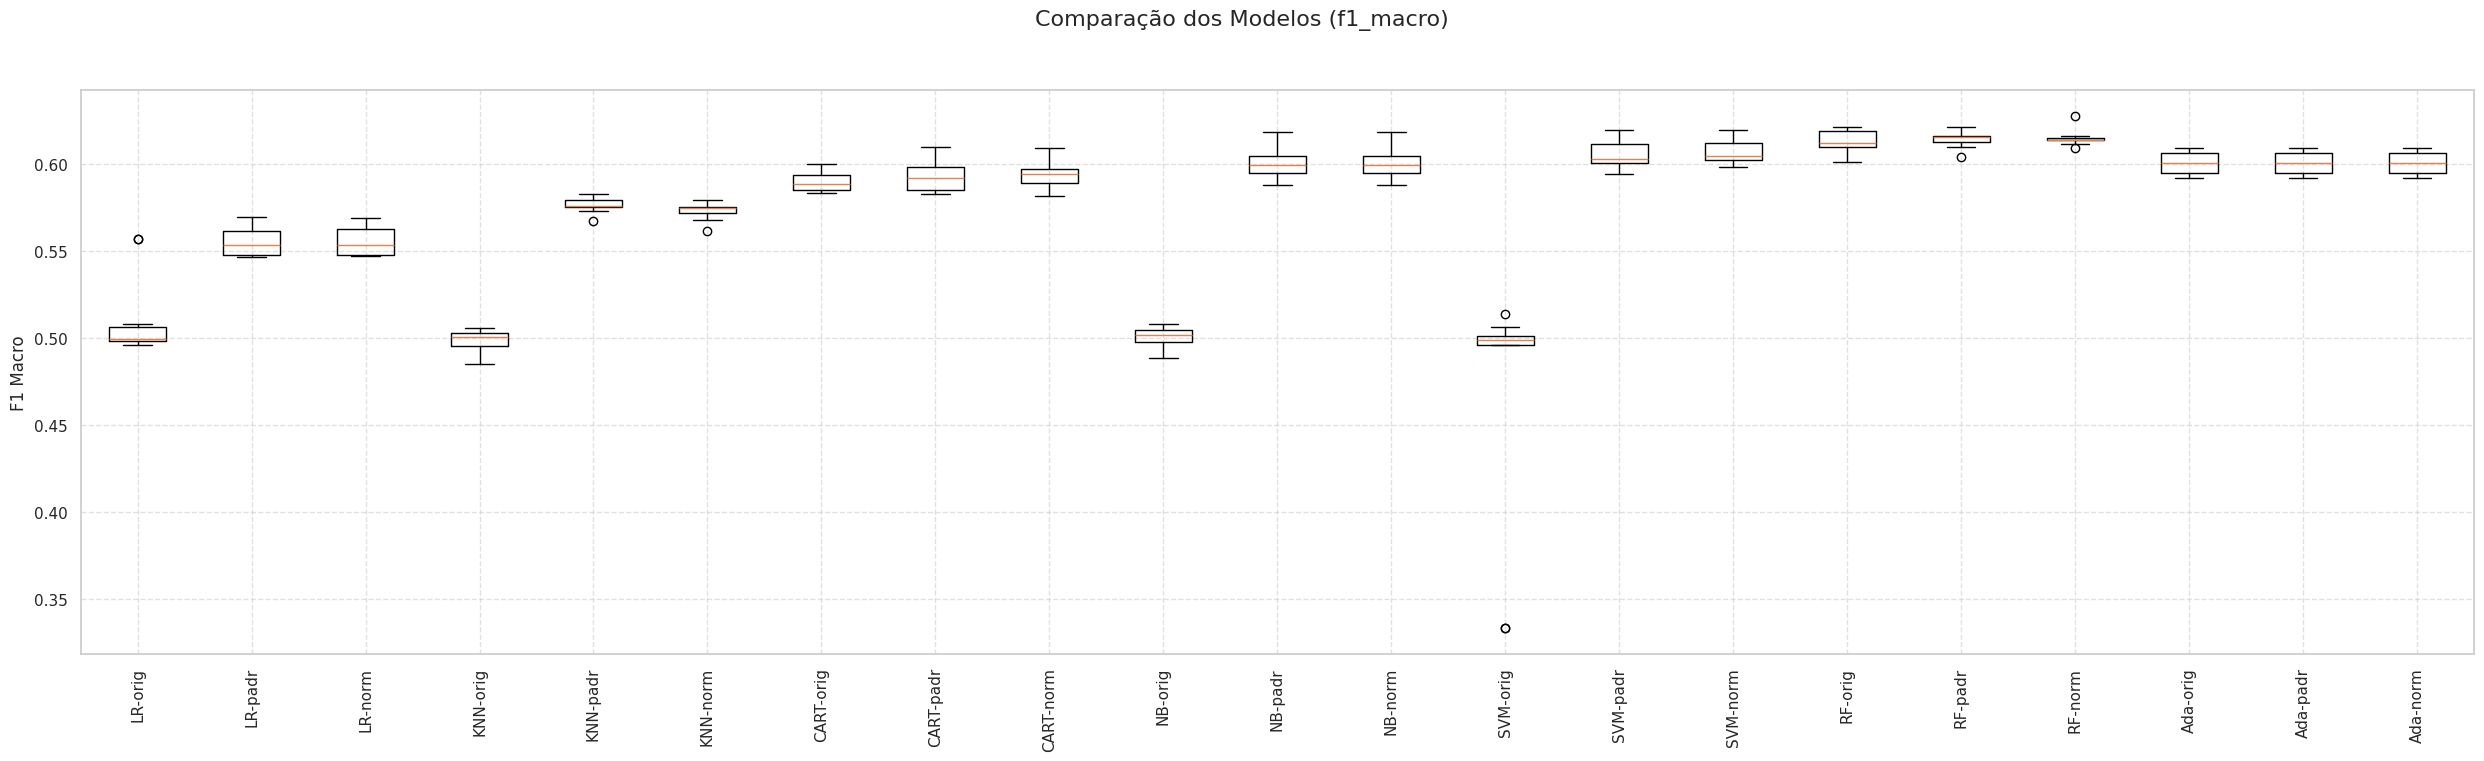





In [30]:
#Bloqueado por demorar demais
scaler4 = MinMaxScaler()
X_train_scaled4 = scaler4.fit_transform(X_train3)
X_test_scaled4 = scaler4.transform(X_test3)

#Do resultado obtido anteriormente, identificou-se que os resultados não mudaram por conta da quantidade e layers, então serão alteradas outras variáveis.
#Outra mudança foi a alteração da quantidade de epochs para 20 pois
# modelo_treinado_peq2, historico_peq2 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled4,
#     y_train=y_train3,
#     X_test=X_test_scaled4,
#     y_test=y_test3,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=20,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.6166

F1-Score no conjunto de teste: 0.6673


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.67 | 0.46 | 0.55 | 6075 |
| 1 | 0.59 | 0.77 | 0.67 | 6075 |
| **accuracy** | | | **0.62** | **12150** |
| **macro avg** | 0.63 | 0.62 | 0.61 | 12150 |
| **weighted avg** | 0.63 | 0.62 | 0.61 | 12150 |


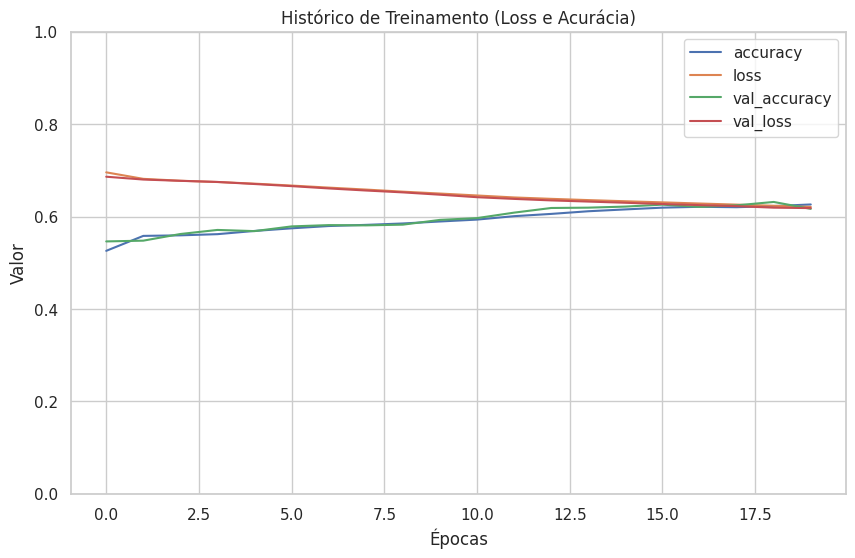

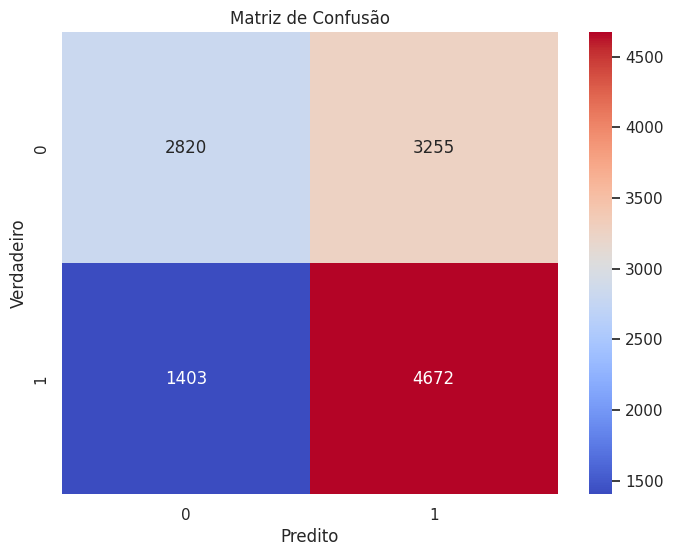

#Análise dos resultados

Com o balanceamento dos dados houve novamente uma melhora nos valores de acurácia, f1 e recall, porém o modelo que se destacou no valor "f1" foi o Random Forest(RF) com dados normalizados. O que chama atenção é que os quartis do box plot ficaram pequenos e mesmo os outliers ficaram próximos da mediana.

Para o modelo de rede neural, novamente a acurácia diminuiu, porém aumentou significativamente a acurácia na detecção de cancelamentos. Aparentemente o número de épocas precisa ser aumentado, mas antes de explorar mais esses dados será avaliado o resultado de uma nova alternativa. Essa avaliará se é possível melhorar o resultado se eliminar os atributos de tempo. Esse foi um ponto de atenção informado pelos orientadores do curso em aula de dúvidas do MVP e de fato apresenta grande relevancia ao modelo. A combinação de dias e horários pode criar características que não se repetem linearmente durante o ano seguinte, como por exemplo feriados e finais de semana.

In [31]:

# Separar features (X) e target (y)
X4 = df_balanceado2[['Avg VTAT', 'Type_Bike','Type_Go Mini','Type_Go Sedan', 'Type_Premier Sedan', 'Type_Uber XL', 'Type_eBike','cancellation_rate_percent_drop','cancellation_rate_percent_pickup']]
y4 = df_balanceado2['Cancelled Rides by Driver']
# Dividir os dados em conjuntos de treino e teste
X_train4, X_test4, y_train4, y_test4 = train_test_split(X4, y4, test_size=0.3, random_state=42, stratify=y4)
print(f"Dimensões de X_train2: {X_train4.shape}")
print(f"Dimensões de X_test2: {X_test4.shape}")
print(f"Dimensões de y_train2: {y_train4.shape}")
print(f"Dimensões de y_test2: {y_test4.shape}")

Dimensões de X_train2: (28348, 9)
Dimensões de X_test2: (12150, 9)
Dimensões de y_train2: (28348,)
Dimensões de y_test2: (12150,)


In [32]:
# #Bloqueado por demorar emais
# df_resultados4 = executar_comparacao_modelos(X4, y4, models=models_to_compare, scalers=scalers_to_compare)

# colunas_resumo4 = ['pipeline_name'] + [f'mean_{s}' for s in ['f1_macro', 'precision_macro', 'recall_macro']]
# print(df_resultados4[colunas_resumo4])

#Resultados parciais


| Modelo | Pré-processamento | F1 Macro | Precision Macro | Recall Macro |
| :--- | :--- | :--- | :--- | :--- |
| LR | orig | 0.556 (0.008) | 0.556 (0.008) | 0.556 (0.008) |
| LR | padr | 0.556 (0.008) | 0.556 (0.008) | 0.556 (0.008) |
| LR | norm | 0.556 (0.008) | 0.556 (0.008) | 0.556 (0.008) |
| KNN | orig | 0.597 (0.004) | 0.600 (0.004) | 0.599 (0.004) |
| KNN | padr | 0.591 (0.005) | 0.594 (0.004) | 0.593 (0.004) |
| KNN | norm | 0.591 (0.006) | 0.593 (0.006) | 0.592 (0.006) |
| CART | orig | 0.588 (0.006) | 0.589 (0.006) | 0.589 (0.006) |
| CART | padr | 0.588 (0.005) | 0.589 (0.005) | 0.588 (0.005) |
| CART | norm | 0.588 (0.005) | 0.588 (0.005) | 0.588 (0.005) |
| NB | orig | 0.601 (0.009) | 0.613 (0.009) | 0.607 (0.009) |
| NB | padr | 0.601 (0.009) | 0.613 (0.009) | 0.607 (0.009) |
| NB | norm | 0.601 (0.009) | 0.613 (0.009) | 0.607 (0.009) |
| SVM | orig | 0.607 (0.006) | 0.651 (0.007) | 0.625 (0.006) |
| SVM | padr | 0.608 (0.007) | 0.654 (0.008) | 0.626 (0.006) |
| SVM | norm | 0.609 (0.007) | 0.655 (0.008) | 0.627 (0.007) |
| RF | orig | 0.603 (0.006) | 0.609 (0.005) | 0.606 (0.006) |
| RF | padr | 0.601 (0.006) | 0.608 (0.006) | 0.604 (0.006) |
| RF | norm | 0.602 (0.004) | 0.609 (0.005) | 0.606 (0.005) |
| Ada | orig | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |
| Ada | padr | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |
| Ada | norm | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |


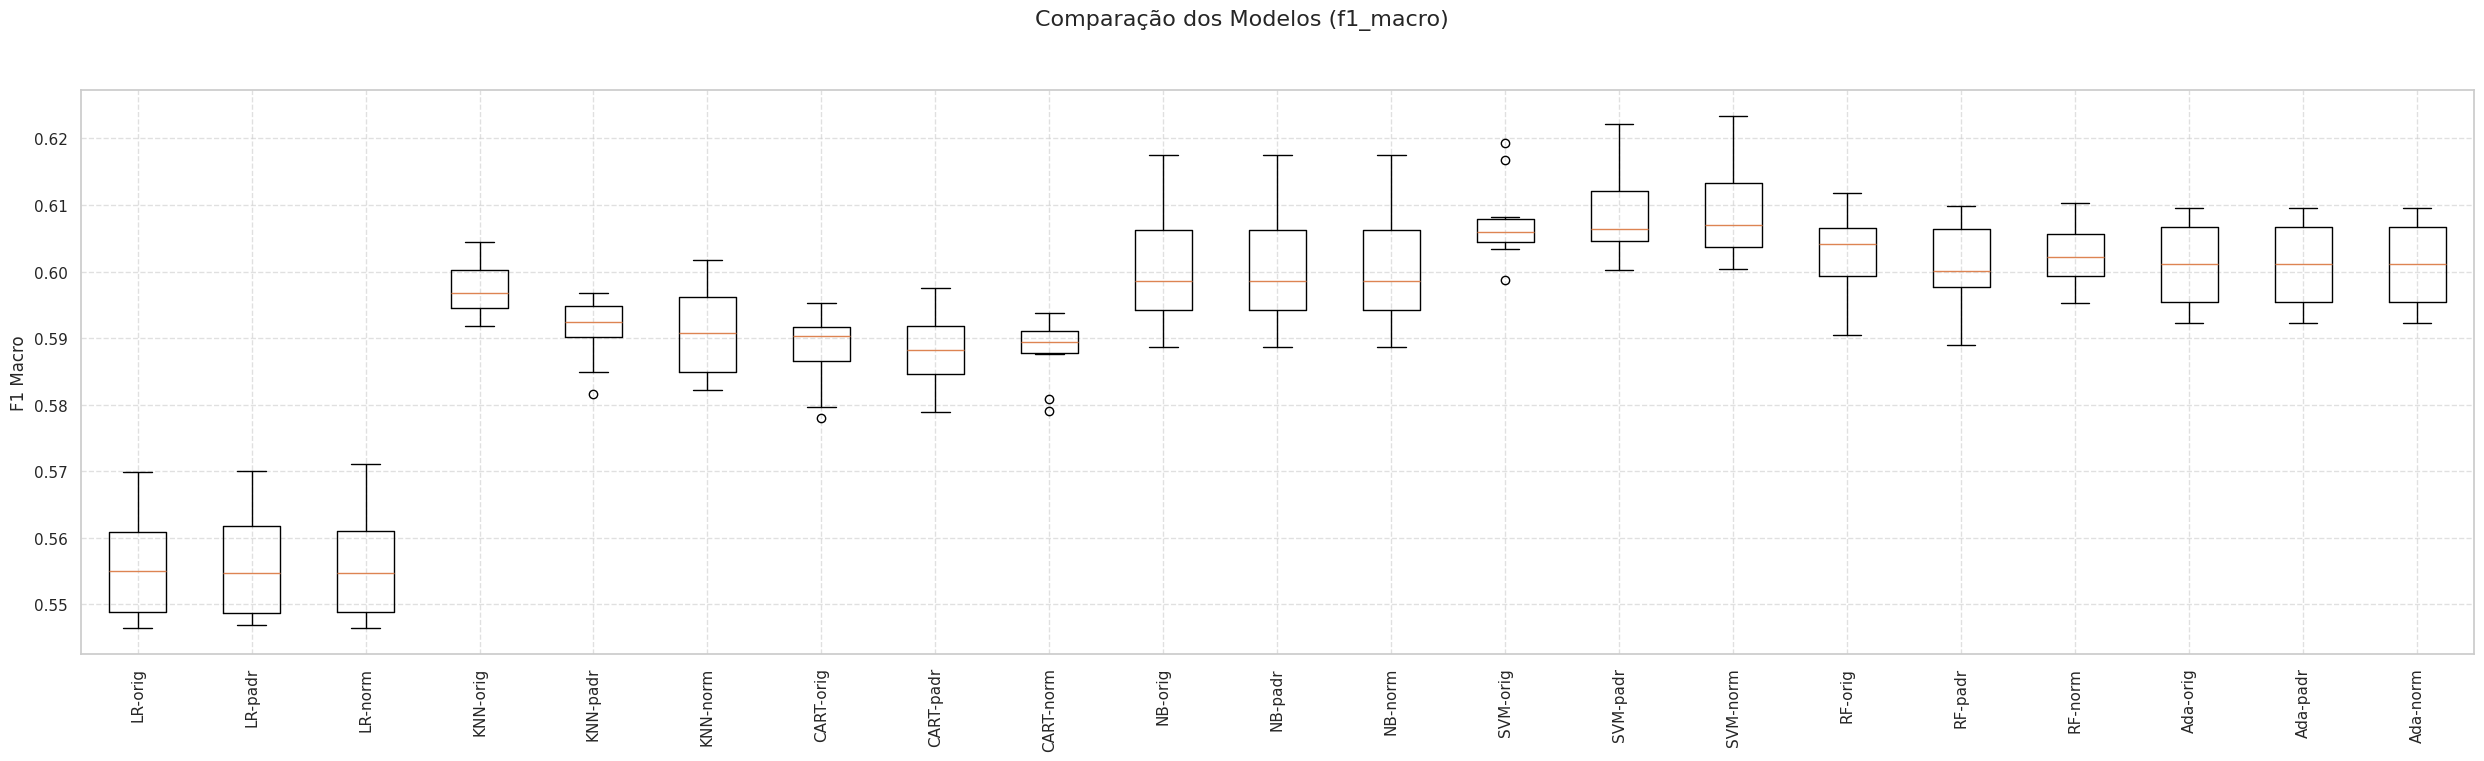


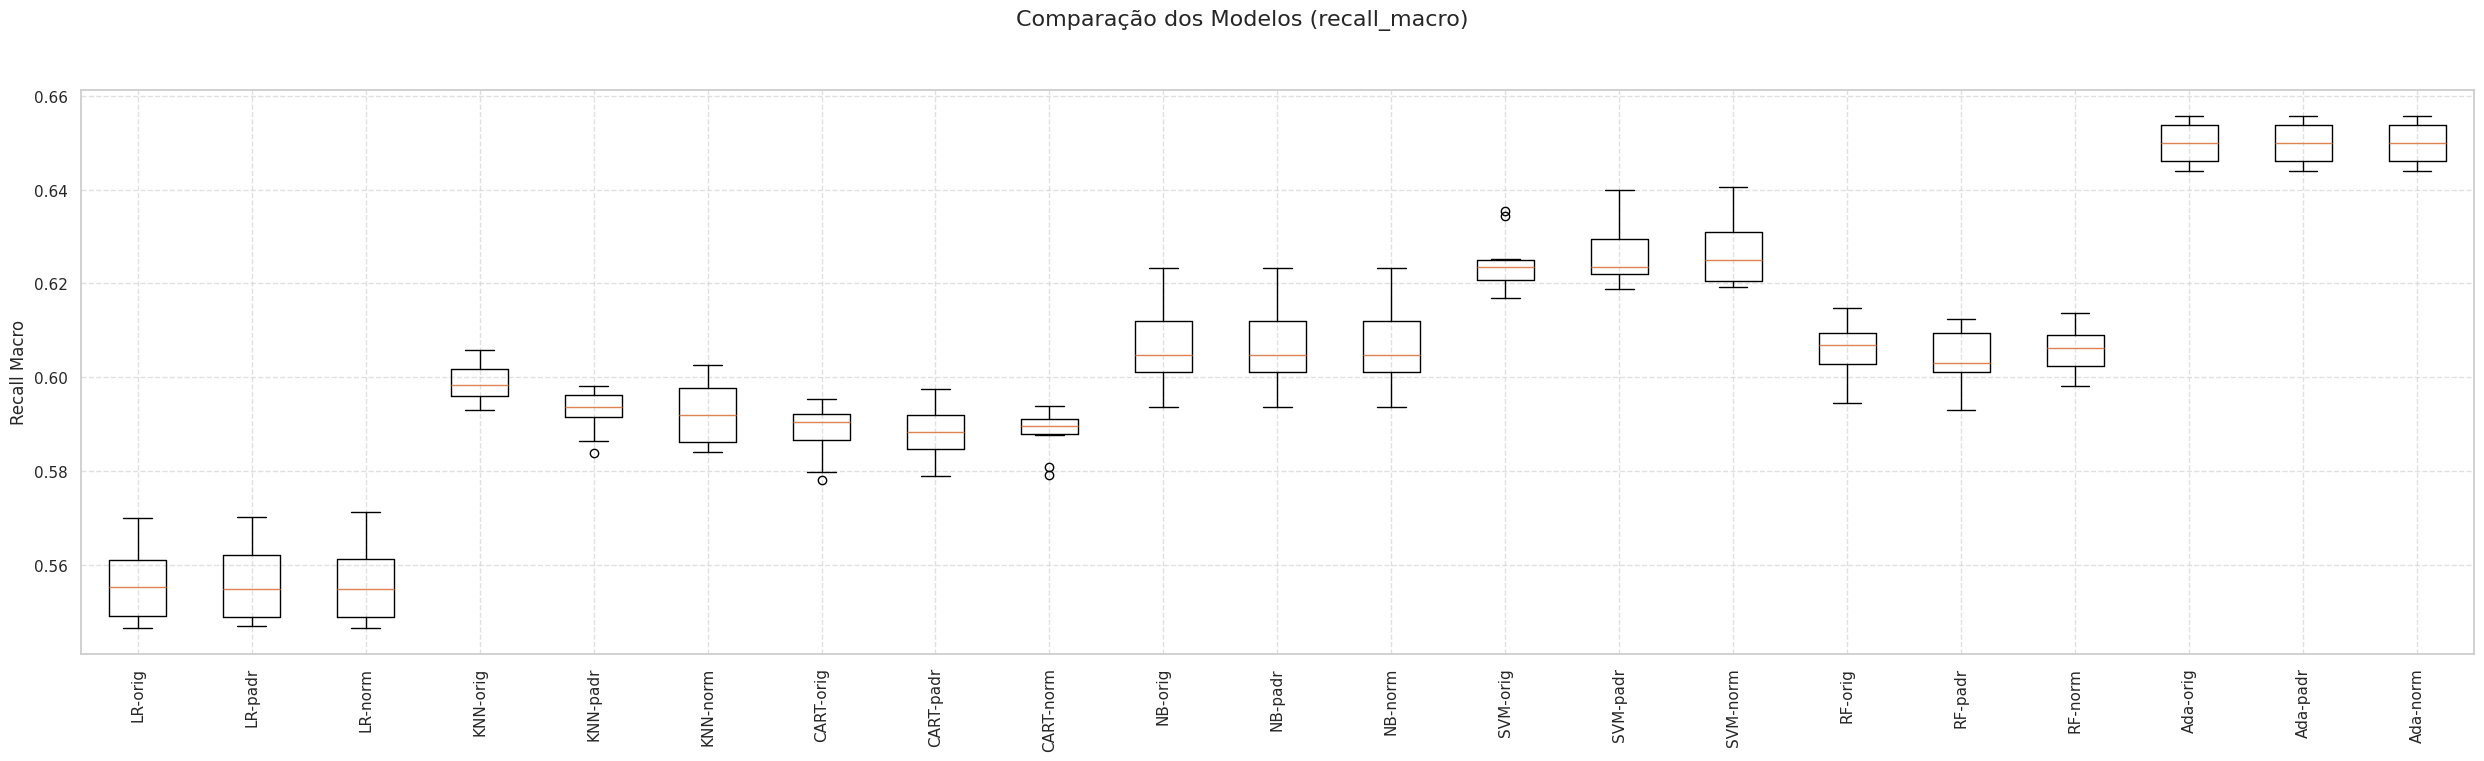


In [33]:
#Bloqueado por demorar demais
scaler5 = MinMaxScaler()
X_train_scaled5 = scaler5.fit_transform(X_train4)
X_test_scaled5 = scaler5.transform(X_test4)


# modelo_treinado_peq5, historico_peq5 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled5,
#     y_train=y_train4,
#     X_test=X_test_scaled5,
#     y_test=y_test4,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=20,
#     batch_size=32
# )

#Resultados parciais
Acurácia no conjunto de teste: 0.6226

F1-Score no conjunto de teste: 0.7007



### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.76 | 0.36 | 0.49 | 6075 |
| 1 | 0.58 | 0.88 | 0.70 | 6075 |
| **accuracy** | | | **0.62** | **12150** |
| **macro avg** | 0.67 | 0.62 | 0.59 | 12150 |
| **weighted avg** | 0.67 | 0.62 | 0.59 | 12150 |

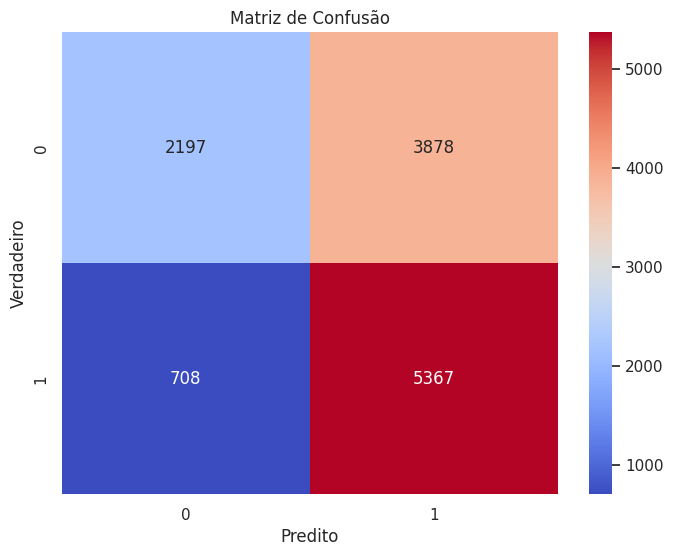

#Análise dos resultados
Com a eliminação das variáveis de data e hora, o modelo SVM apresentou resultados superiores na métrica "F1". Levando em consideração que o objetivo do modelo é evitar que um cancelamento seja feito, a métrica "recall" deve ser considerada, então entendo que o modelo Ada também é relevante. A partir disso vou alterar alguns parâmetros para tentar otimizar esse modelo.

Quanto a rede neural, as métricas melhoraram mas é necessário avaliar os hiperparâmetros para entender qual a melhor condição.

Por fim optou-se por usar os dados sem o atributo de data e hora e tentar otimizá-los pois há várias vantagens em relação a aplicação do modelo (sem problemas com relação aos feriados, sem combinações de horas que podem ser específicas de um ano, sem efeitos de um evento de um dia em um local específico e menos atributos necessários).

Iniciando comparação de modelos...
--- Ada-n200-lr0.1-orig ---
  f1_macro: 0.548 (0.006)
  precision_macro: 0.782 (0.001)
  recall_macro: 0.615 (0.004)
--- Ada-n200-lr0.1-padr ---
  f1_macro: 0.548 (0.006)
  precision_macro: 0.782 (0.001)
  recall_macro: 0.615 (0.004)
--- Ada-n200-lr0.1-norm ---
  f1_macro: 0.548 (0.006)
  precision_macro: 0.782 (0.001)
  recall_macro: 0.615 (0.004)
--- Ada-n100-lr0.1-orig ---
  f1_macro: 0.548 (0.006)
  precision_macro: 0.782 (0.001)
  recall_macro: 0.615 (0.004)
--- Ada-n100-lr0.1-padr ---
  f1_macro: 0.548 (0.006)
  precision_macro: 0.782 (0.001)
  recall_macro: 0.615 (0.004)
--- Ada-n100-lr0.1-norm ---
  f1_macro: 0.548 (0.006)
  precision_macro: 0.782 (0.001)
  recall_macro: 0.615 (0.004)
--- Ada-n100-lr1-orig ---
  f1_macro: 0.601 (0.006)
  precision_macro: 0.794 (0.001)
  recall_macro: 0.650 (0.004)
--- Ada-n100-lr1-padr ---
  f1_macro: 0.601 (0.006)
  precision_macro: 0.794 (0.001)
  recall_macro: 0.650 (0.004)
--- Ada-n100-lr1-norm ---
  f1_ma

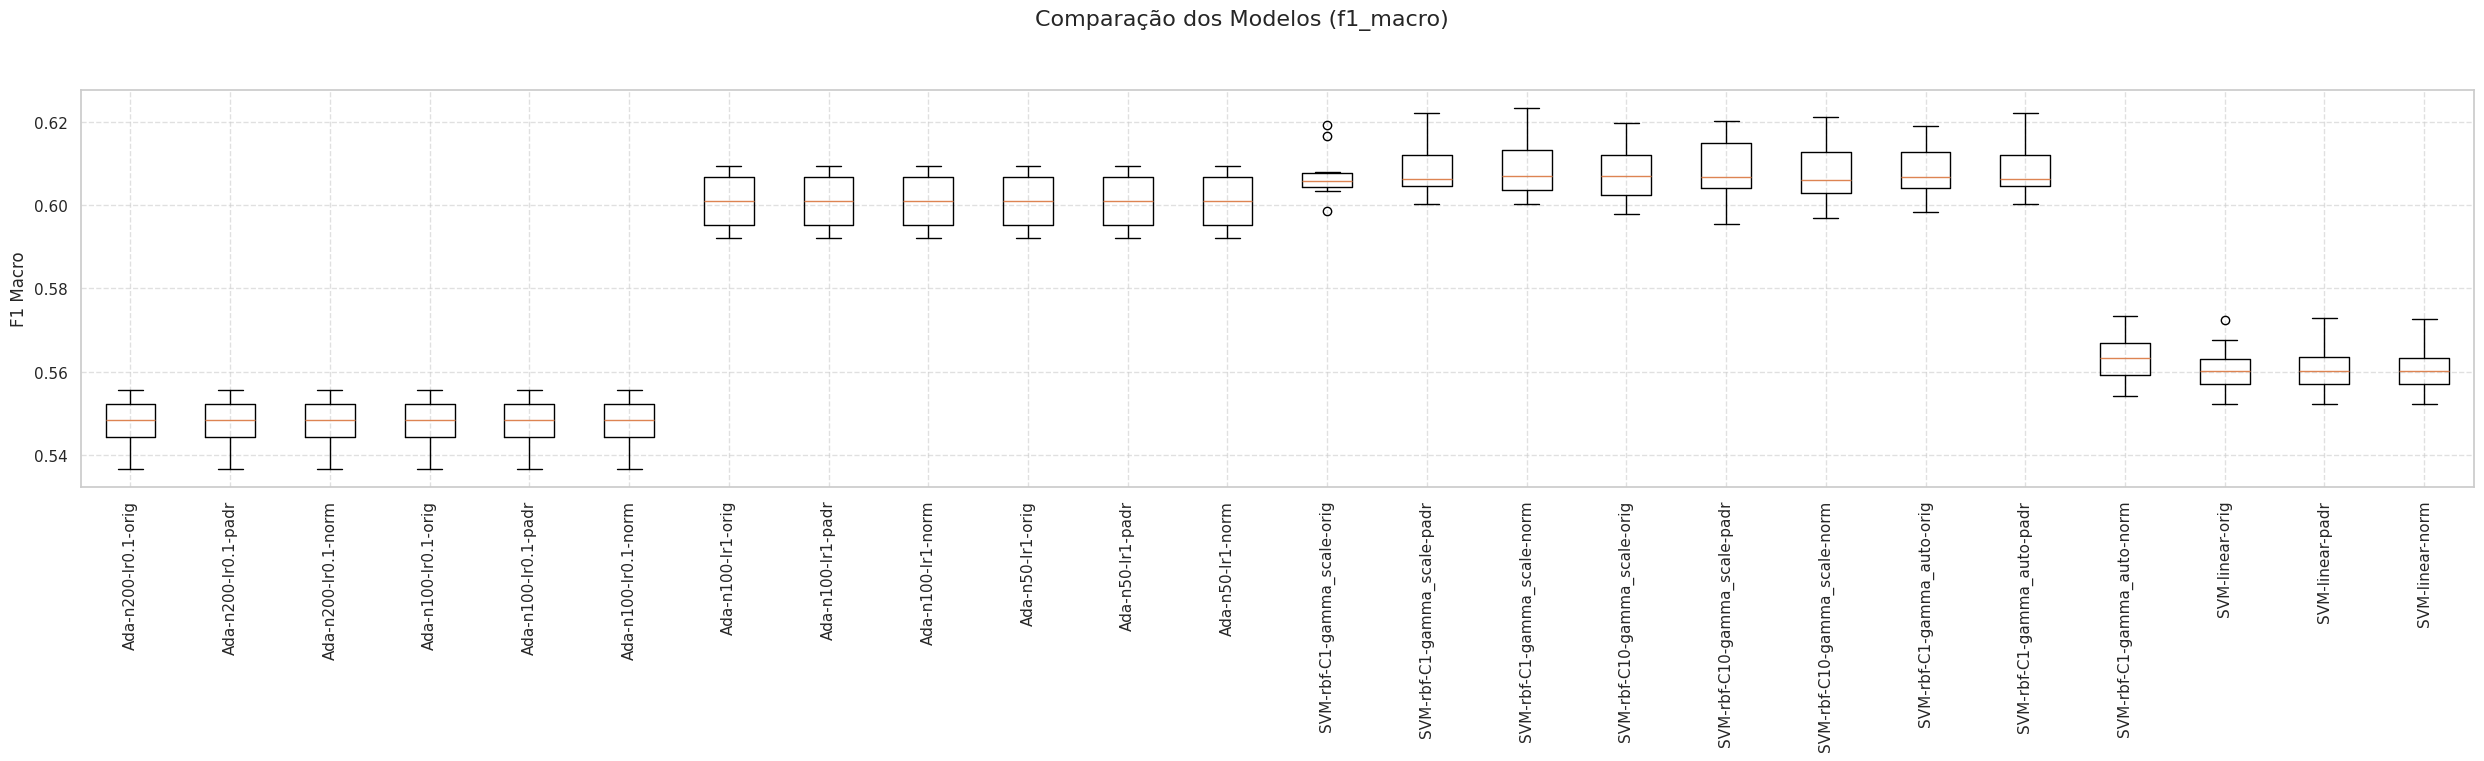

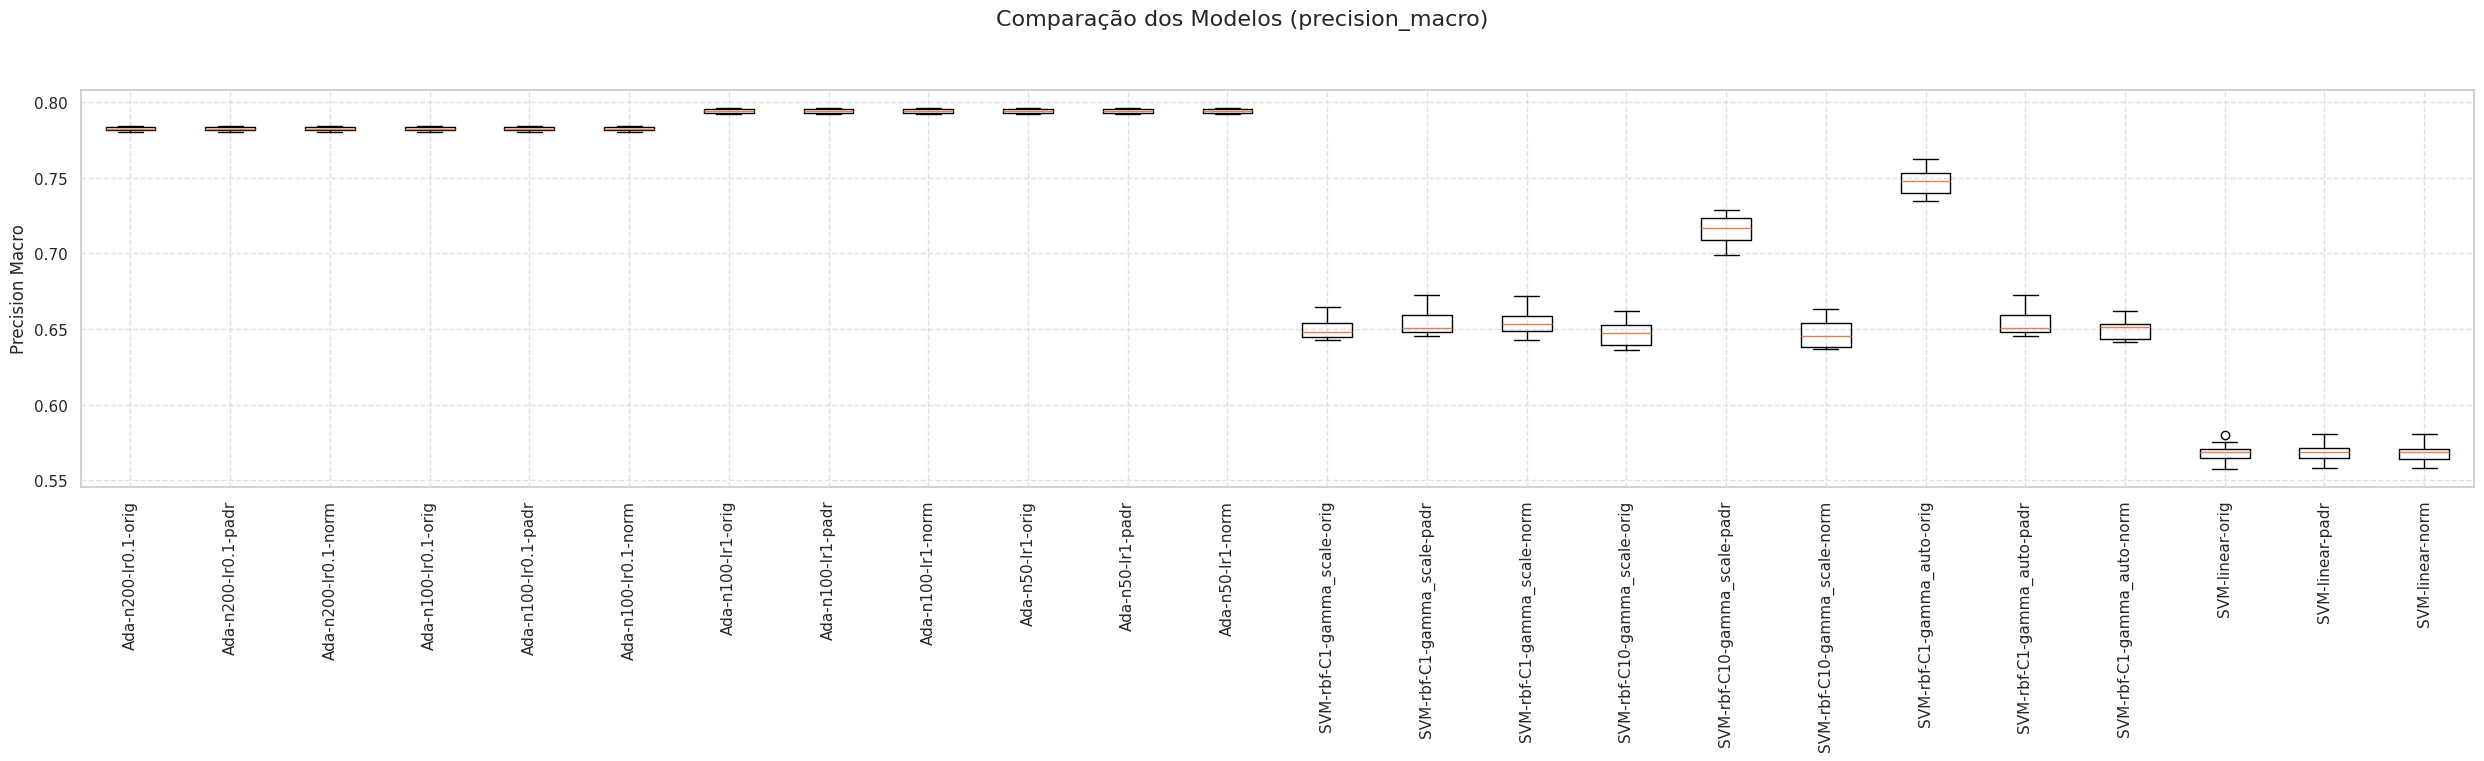

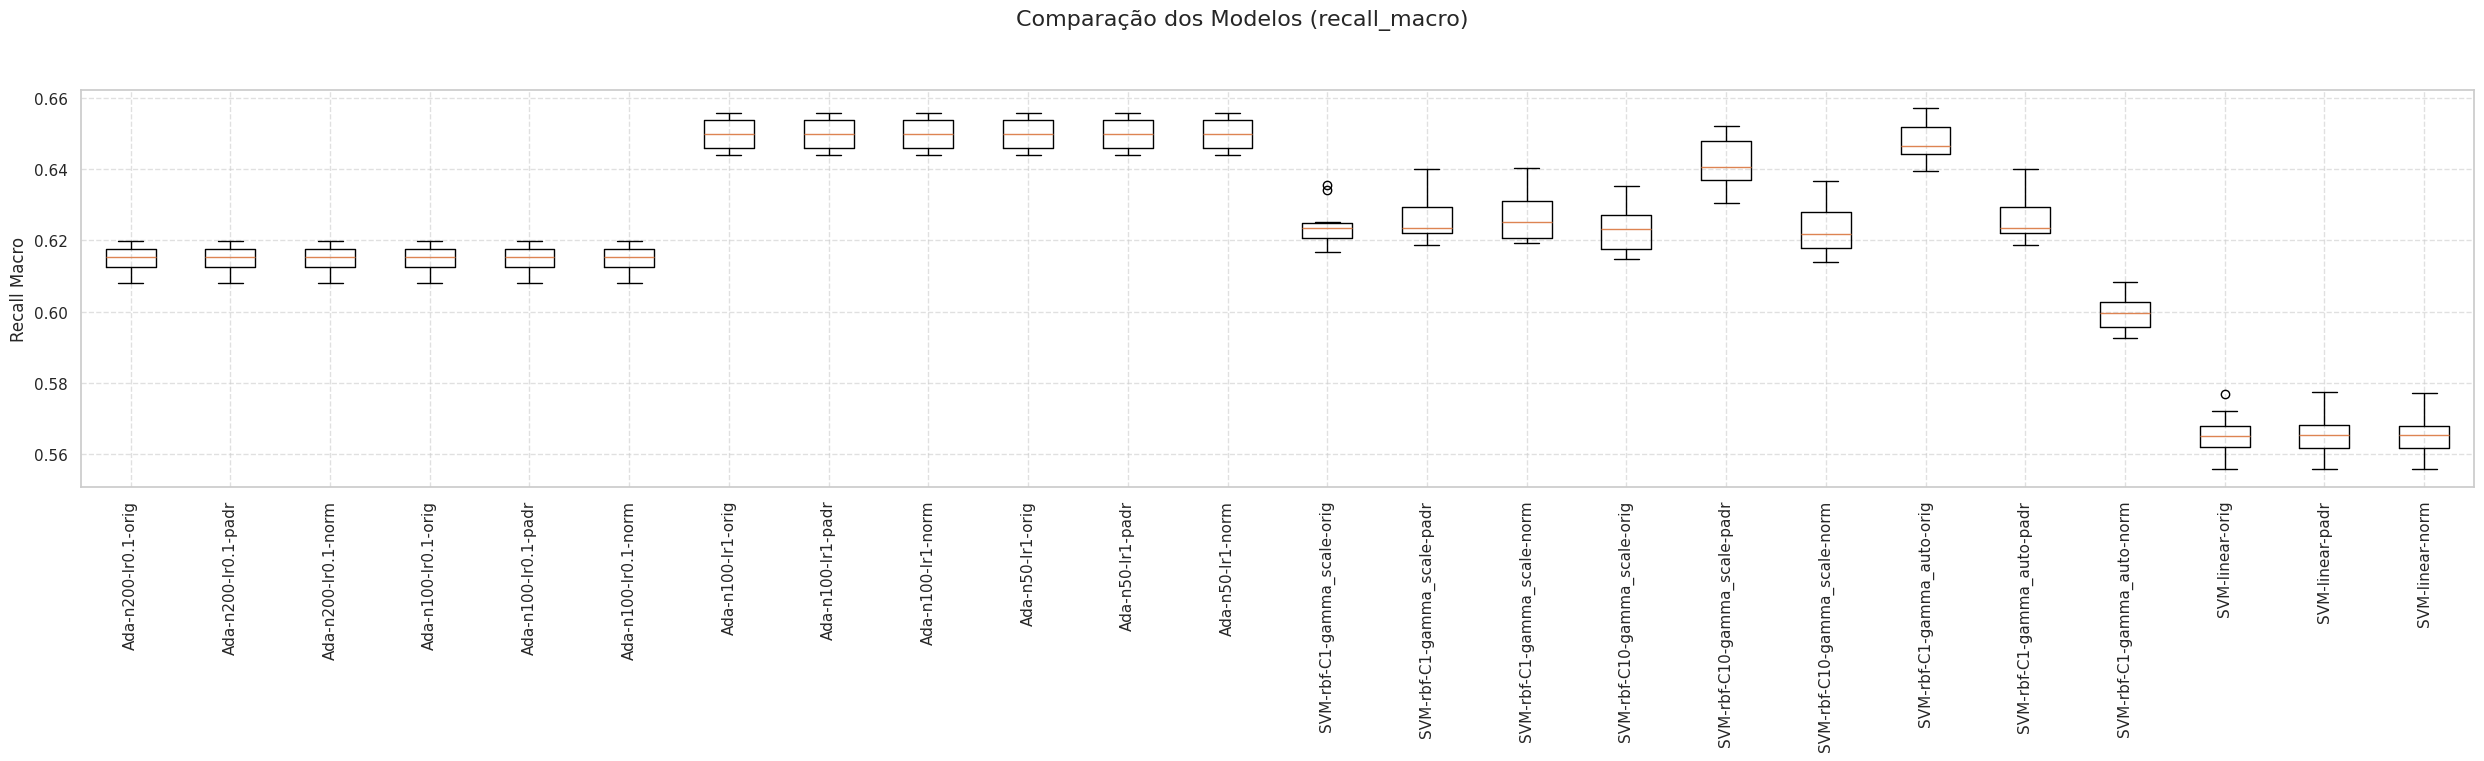

                   pipeline_name  mean_f1_macro  mean_precision_macro  \
0            Ada-n200-lr0.1-orig       0.547655              0.782425   
1            Ada-n200-lr0.1-padr       0.547655              0.782425   
2            Ada-n200-lr0.1-norm       0.547655              0.782425   
3            Ada-n100-lr0.1-orig       0.547655              0.782425   
4            Ada-n100-lr0.1-padr       0.547655              0.782425   
5            Ada-n100-lr0.1-norm       0.547655              0.782425   
6              Ada-n100-lr1-orig       0.601086              0.794119   
7              Ada-n100-lr1-padr       0.601086              0.794119   
8              Ada-n100-lr1-norm       0.601086              0.794119   
9               Ada-n50-lr1-orig       0.601086              0.794119   
10              Ada-n50-lr1-padr       0.601086              0.794119   
11              Ada-n50-lr1-norm       0.601086              0.794119   
12   SVM-rbf-C1-gamma_scale-orig       0.607433    

In [34]:
#Análise dos modelos

#Bloqueado por demorar demais - + de 9 horas

# models_to_compare_final = {



#     # --- Variações do Ada ---
#     'Ada-n200-lr0.1': AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=7),
#     'Ada-n100-lr0.1': AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=7),
#     'Ada-n100-lr1': AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=7),
#     'Ada-n50-lr1': AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=7),

#     # --- Variações do SVM ---
#     'SVM-rbf-C1-gamma_scale': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=7),
#     'SVM-rbf-C10-gamma_scale': SVC(kernel='rbf', C=10.0, gamma='scale', probability=True, random_state=7),
#     'SVM-rbf-C1-gamma_auto': SVC(kernel='rbf', C=1.0, gamma='auto', probability=True, random_state=7),
#     'SVM-linear': SVC(kernel='linear', probability=True, random_state=7)

# }

# #Repetido pois já havia bloqueado a célula
# scalers_to_compare = {
#     'padr': StandardScaler(),
#     'norm': MinMaxScaler()
# }


# df_resultados_final = executar_comparacao_modelos(X4, y4, models=models_to_compare_final, scalers=scalers_to_compare)

# colunas_resumo5 = ['pipeline_name'] + [f'mean_{s}' for s in ['f1_macro', 'precision_macro', 'recall_macro']]
# print(df_resultados_final[colunas_resumo5])

#Resultados parciais


### Tabela de Resultados dos Modelos



| **Modelo** | **F1-Score (macro)** | **Precision (macro)** | **Recall (macro)** |
|:---|:---:|:---:|:---:|
| Ada-n200-lr0.1-orig | 0.548 (0.006) | 0.782 (0.001) | 0.615 (0.004) |
| Ada-n200-lr0.1-padr | 0.548 (0.006) | 0.782 (0.001) | 0.615 (0.004) |
| Ada-n200-lr0.1-norm | 0.548 (0.006) | 0.782 (0.001) | 0.615 (0.004) |
| Ada-n100-lr0.1-orig | 0.548 (0.006) | 0.782 (0.001) | 0.615 (0.004) |
| Ada-n100-lr0.1-padr | 0.548 (0.006) | 0.782 (0.001) | 0.615 (0.004) |
| Ada-n100-lr0.1-norm | 0.548 (0.006) | 0.782 (0.001) | 0.615 (0.004) |
| Ada-n100-lr1-orig | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |
| Ada-n100-lr1-padr | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |
| Ada-n100-lr1-norm | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |
| Ada-n50-lr1-orig | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |
| Ada-n50-lr1-padr | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |
| Ada-n50-lr1-norm | 0.601 (0.006) | 0.794 (0.001) | 0.650 (0.004) |
| SVM-rbf-C1-gamma\_scale-orig | 0.607 (0.006) | 0.651 (0.007) | 0.625 (0.006) |
| SVM-rbf-C1-gamma\_scale-padr | 0.608 (0.007) | 0.654 (0.008) | 0.626 (0.006) |
| SVM-rbf-C1-gamma\_scale-norm | 0.609 (0.007) | 0.655 (0.008) | 0.627 (0.007) |
| SVM-rbf-C10-gamma\_scale-orig | 0.607 (0.006) | 0.647 (0.008) | 0.623 (0.006) |
| SVM-rbf-C10-gamma\_scale-padr | 0.609 (0.007) | 0.715 (0.010) | 0.642 (0.007) |
| SVM-rbf-C10-gamma\_scale-norm | 0.608 (0.007) | 0.647 (0.009) | 0.623 (0.007) |
| SVM-rbf-C1-gamma\_auto-orig | 0.608 (0.006) | 0.747 (0.008) | 0.648 (0.005) |
| SVM-rbf-C1-gamma\_auto-padr | 0.608 (0.007) | 0.654 (0.008) | 0.626 (0.006) |
| SVM-rbf-C1-gamma\_auto-norm | 0.563 (0.005) | 0.650 (0.007) | 0.600 (0.005) |
| SVM-linear-orig | 0.561 (0.006) | 0.568 (0.006) | 0.565 (0.006) |
| SVM-linear-padr | 0.561 (0.006) | 0.568 (0.006) | 0.566 (0.006) |
| SVM-linear-norm | 0.561 (0.006) | 0.568 (0.006) | 0.565 (0.006) |


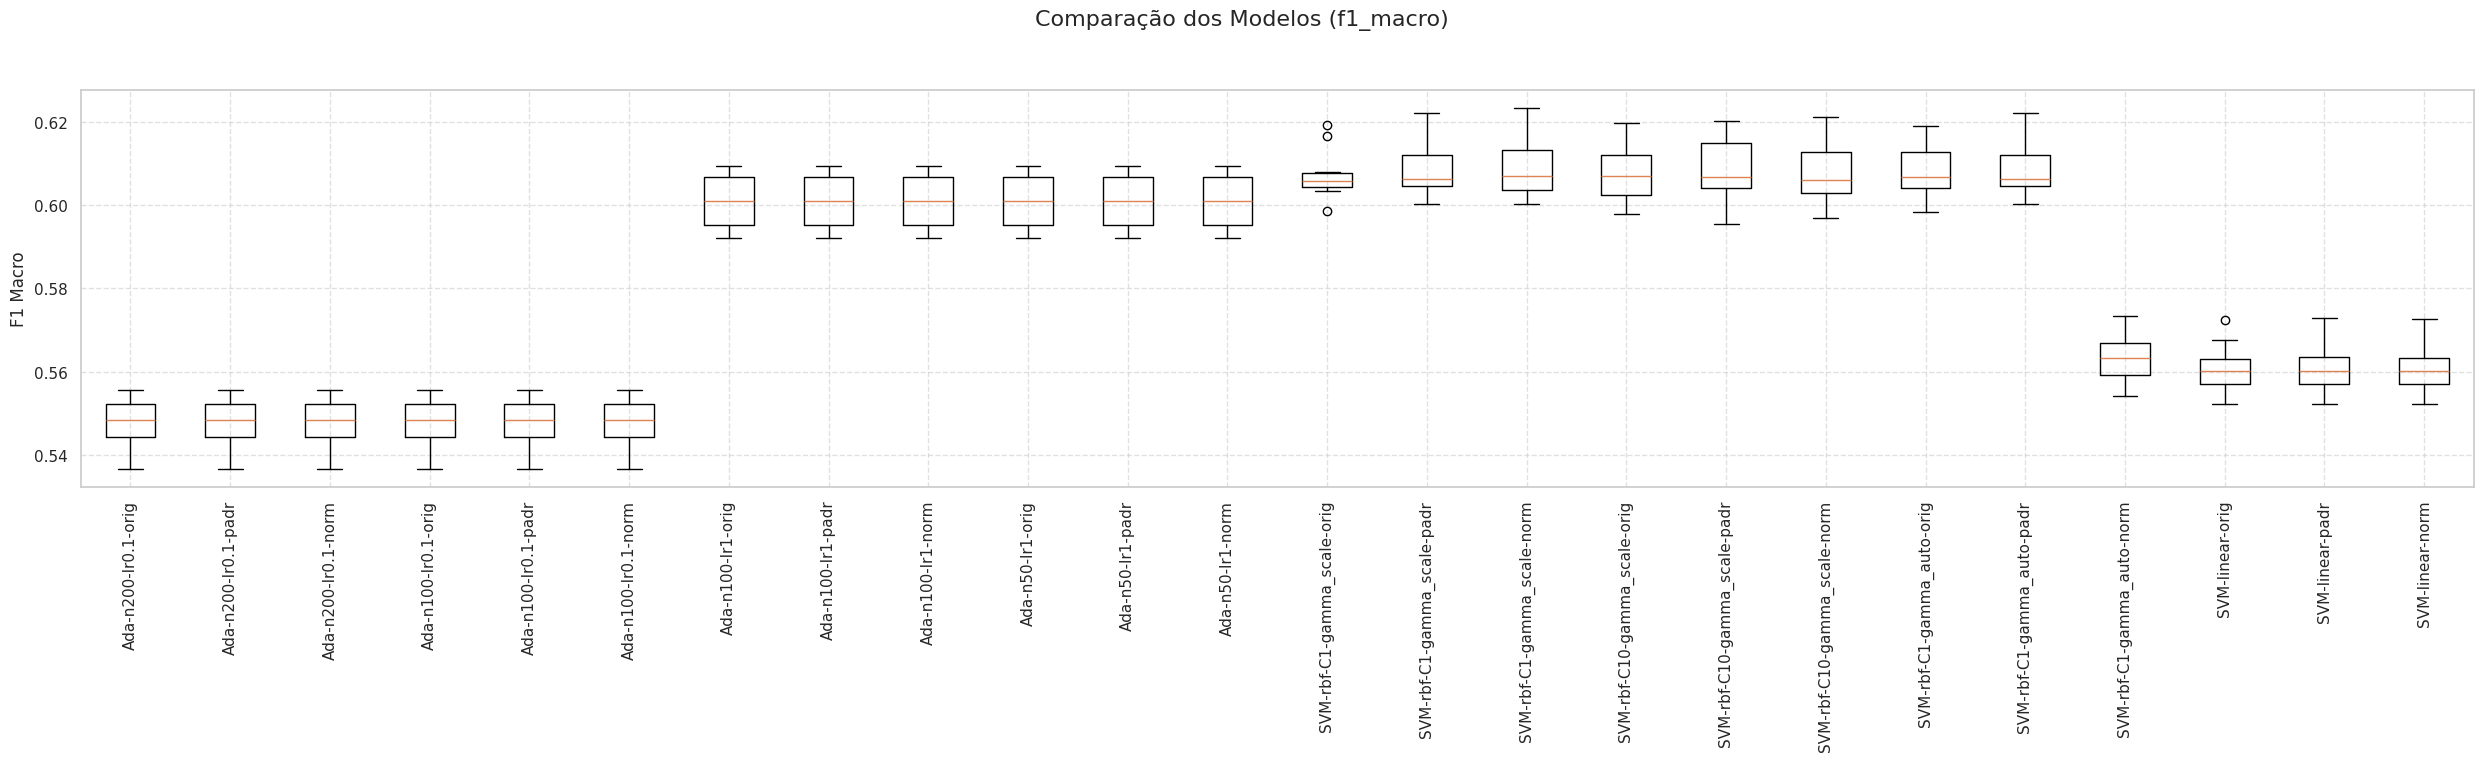

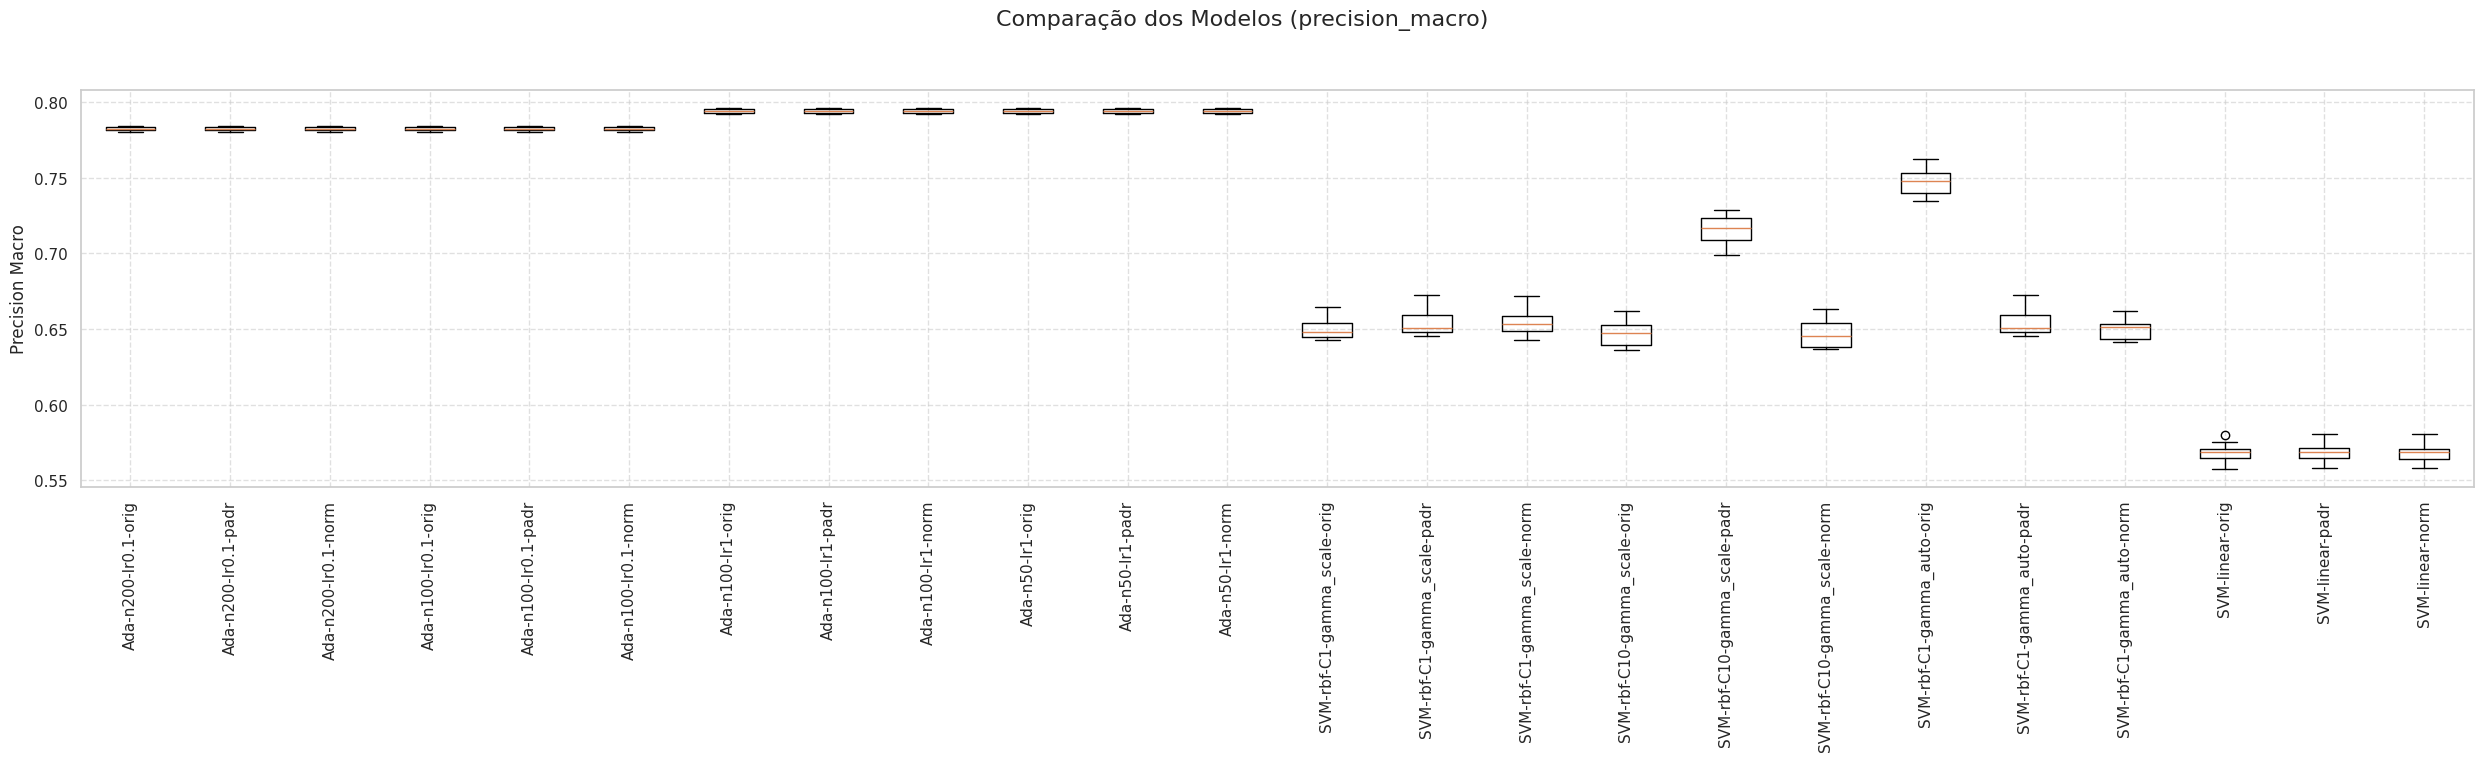

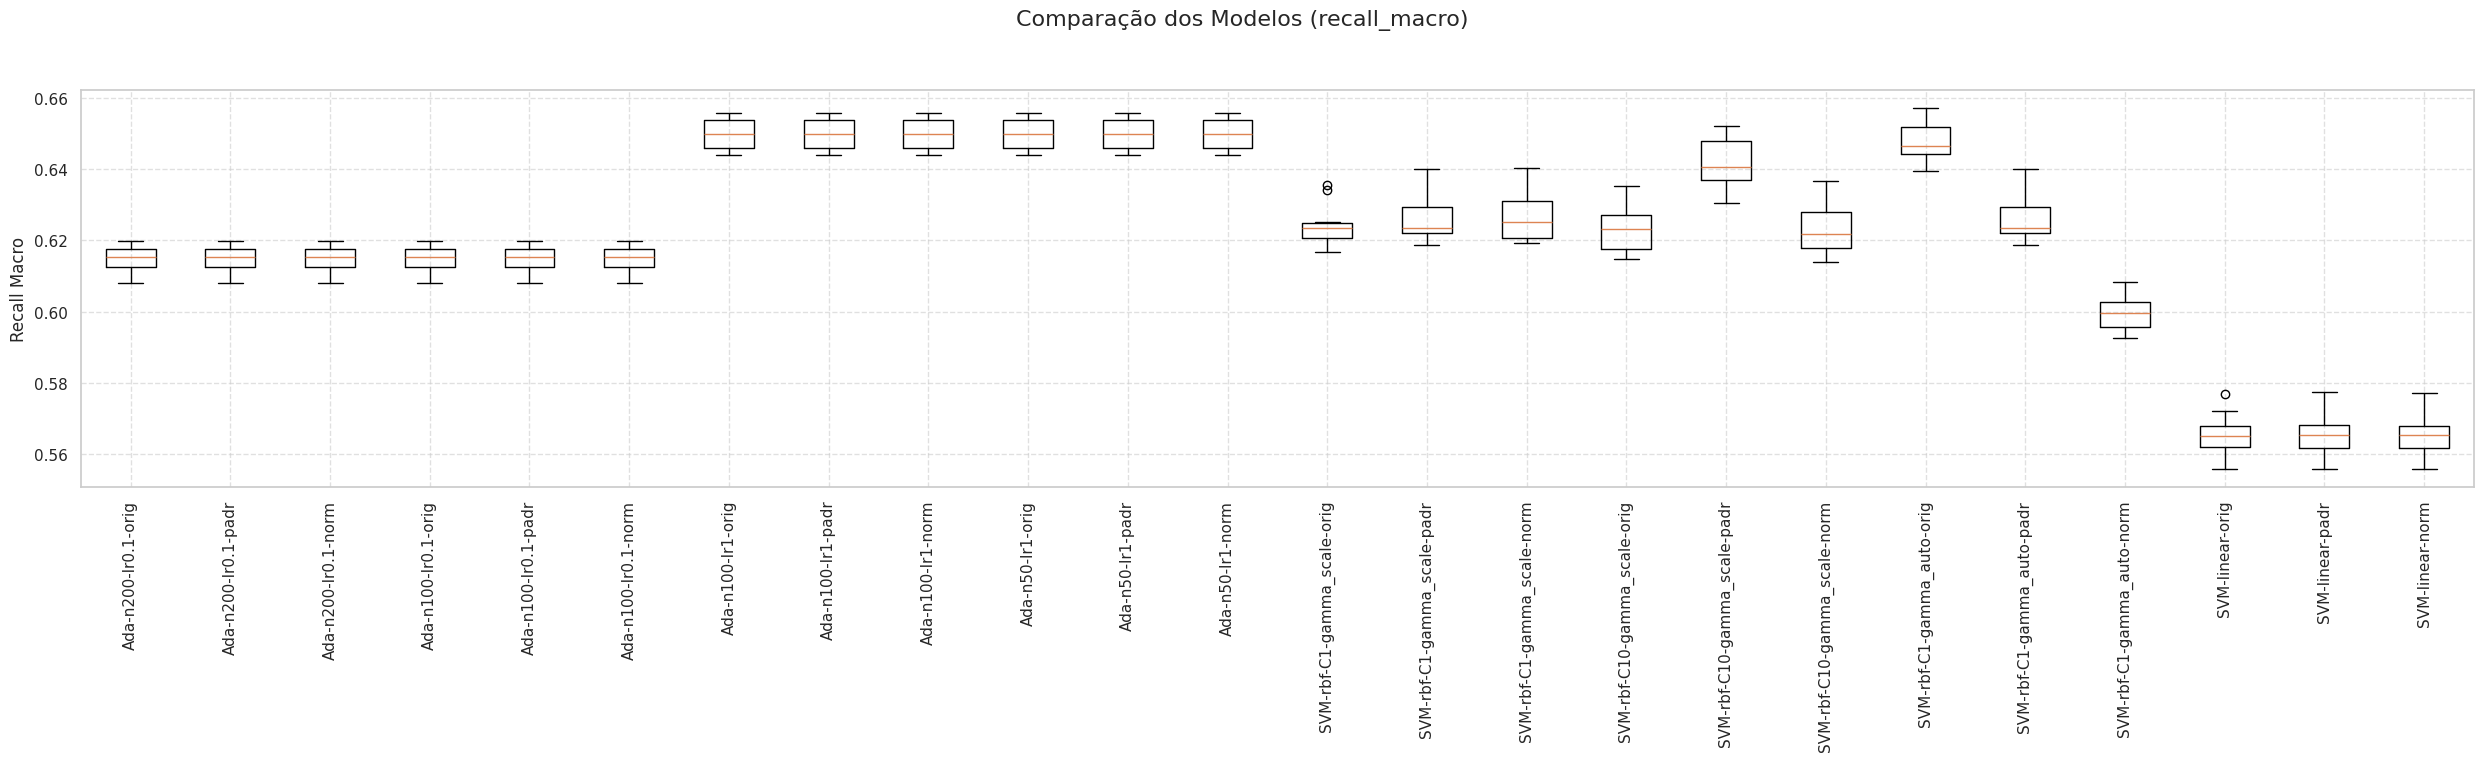



#Resultado da análise do modelo
O modelo SVM-rbf-C10-gamma_scale-padr é o que apresentou melhor "f1" e o Ada-n100-lr1 foram os que apresentaram maior valor de "recall" e precisão sem reduzir muito o valor de "f1". A duração desse treinamento passou de 9 horas, ou seja, para um pipeline em produção recomenda-se alterar o código para utiliza-lo com GPU e limitar as configurações dos modelos. Percebeu-se que em poucos casos a normalização e padronização geraram diferenças significativas. Isso provavelmente ocorreu pois alguns dos listados são baseados em árvores de decisão e elas não são sensíveis à escala.  

Se um desses modelos for superior ao modelo de rede neural será utilizado o código abaixo para salvar o modelo. Caso o contrário será salvo apenas o modelo de rede neural.

#Início dos treinamentos de rede neural
Para esse treinamento algumas alterações serão feitas com o objetivo de avaliar diferentes condições. Pretendo alterar a quantidade de layers para identificar se há algo específico que os uma rede profunda pode identificar, número de épocas, optimizador e perda.

In [37]:
#Bloqueado por demorar demais
# modelo_treinado_peq_f3, historico_peq_f3 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled5,
#     y_train=y_train4,
#     X_test=X_test_scaled5,
#     y_test=y_test4,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=40,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.6272

F1-Score no conjunto de teste: 0.6867


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.71 | 0.44 | 0.54 | 6075 |
| 1 | 0.59 | 0.82 | 0.69 | 6075 |
| **accuracy** | | | **0.63** | **12150** |
| **macro avg** | 0.65 | 0.63 | 0.61 | 12150 |
| **weighted avg** | 0.65 | 0.63 | 0.61 | 12150 |

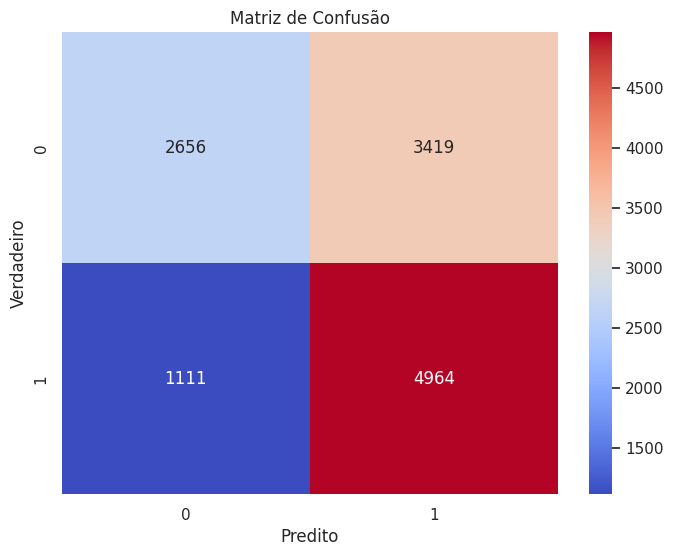


Resumo do Modelo:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)


Compilando o modelo com optimizer='adam' and loss='binary_crossentropy'...

Iniciando o treinamento por 40 épocas com batch_size=32...
Epoch 1/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5061 - loss: 0.6946 - val_accuracy: 0.5690 - val_loss: 0.6631
Epoch 2/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5703 - loss: 0.6613 - val_accuracy: 0.5906 - val_loss: 0.6473
Epoch 3/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5922 - loss: 0.6457 - val_accuracy: 0.5998 - val_loss: 0.6348
Epoch 4/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5954 - loss: 0.6342 - val_accuracy: 0.6056 - val_loss: 0.6258
Epoch 5/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6070 - loss: 0.6259 - val_accuracy: 0.6187 - val_loss: 0.6185
Epoch 6/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6111 - loss: 0.6208 - val_accuracy: 0.6232 - val_loss: 0.6162
Epoch 7/40
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6183 - loss: 0.6170 - val_accu

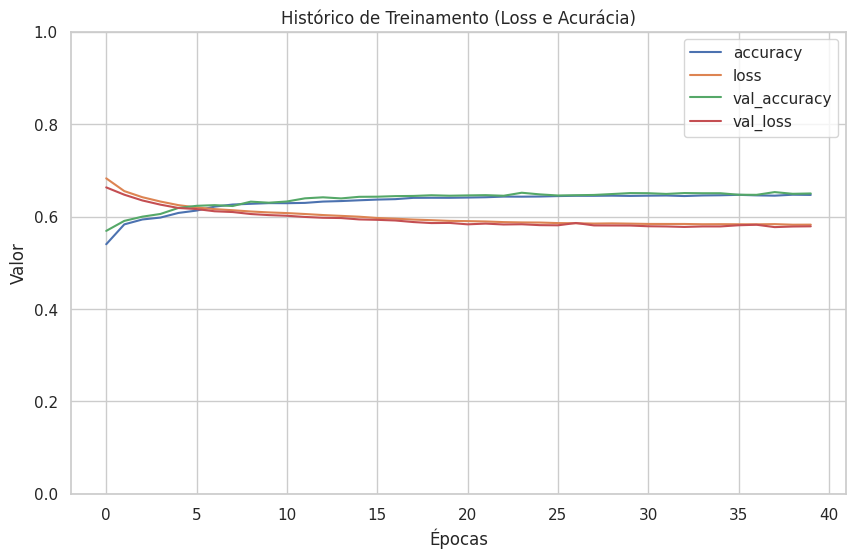

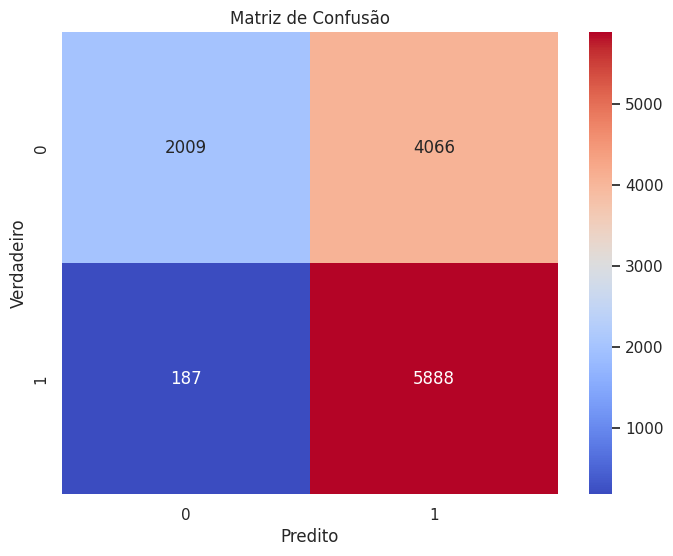


--- Processo Finalizado ---


In [38]:
#Deixei desbloqueado por ter sido escolhidos.
#OBS: Eu sei que pela separação dos dados ser aleatória, quando rodar o código novamente os valores das métricas vão mudas
#Mantive o resultado original pois foi nele que utilizei com referência
modelo_treinado_med_f3, historico_med_f3 = treinar_e_avaliar_rede_neural_med(
    X_train=X_train_scaled5,
    y_train=y_train4,
    X_test=X_test_scaled5,
    y_test=y_test4,
    optimizer='adam',
    loss='binary_crossentropy',
    epochs=40,
    batch_size=32
)

#Resultados parciais

Acurácia no conjunto de teste: 0.6522

F1-Score no conjunto de teste: 0.7354


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.91 | 0.34 | 0.49 | 6075 |
| 1 | 0.59 | 0.97 | 0.74 | 6075 |
| **accuracy** | | | **0.65** | **12150** |
| **macro avg** | 0.75 | 0.65 | 0.61 | 12150 |
| **weighted avg** | 0.75 | 0.65 | 0.61 | 12150 |

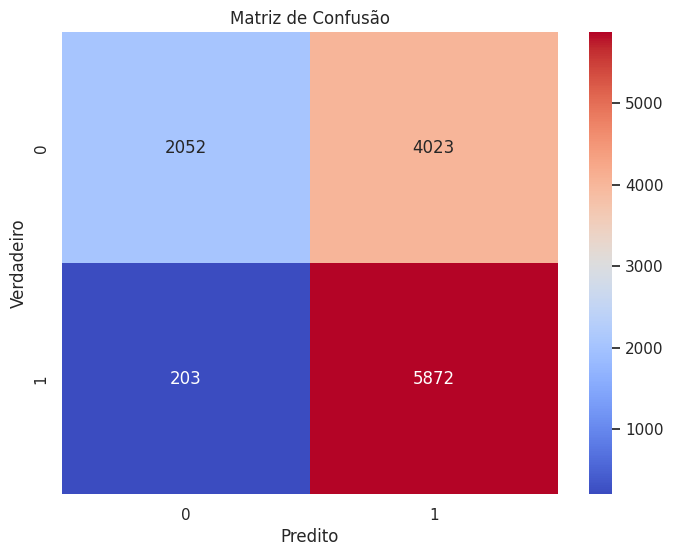

In [39]:
#Bloqueado por demorar demais
# modelo_treinado_gra_f3, historico_gra_f3 = treinar_e_avaliar_rede_neural_gra(
#     X_train=X_train_scaled5,
#     y_train=y_train4,
#     X_test=X_test_scaled5,
#     y_test=y_test4,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=40,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.6482

F1-Score no conjunto de teste: 0.7305


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.88 | 0.34 | 0.49 | 6075 |
| 1 | 0.59 | 0.95 | 0.73 | 6075 |
| **accuracy** | | | **0.65** | **12150** |
| **macro avg** | 0.74 | 0.65 | 0.61 | 12150 |
| **weighted avg** | 0.74 | 0.65 | 0.61 | 12150 |


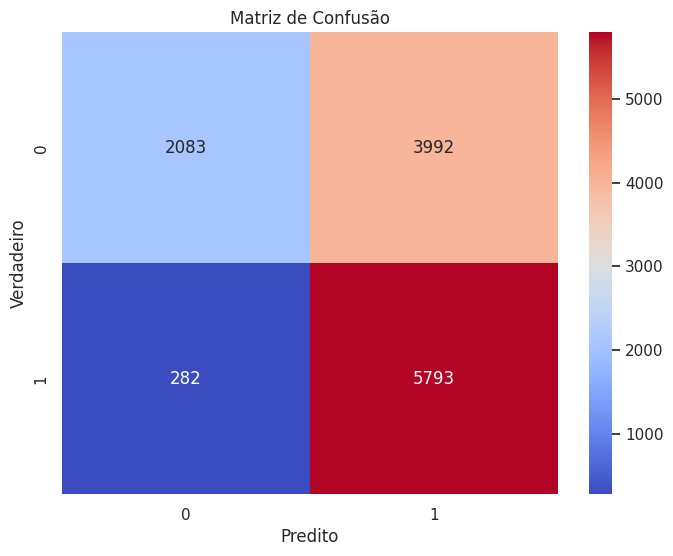

In [40]:
#Bloqueado por demorar demais
# modelo_treinado_peq_f4, historico_peq_f4 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled5,
#     y_train=y_train4,
#     X_test=X_test_scaled5,
#     y_test=y_test4,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=40,
#     batch_size=64
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.6419

F1-Score no conjunto de teste: 0.7165


### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.80 | 0.38 | 0.51 | 6075 |
| 1 | 0.59 | 0.91 | 0.72 | 6075 |
| **accuracy** | | | **0.64** | **12150** |
| **macro avg** | 0.70 | 0.64 | 0.62 | 12150 |
| **weighted avg** | 0.70 | 0.64 | 0.62 | 12150 |


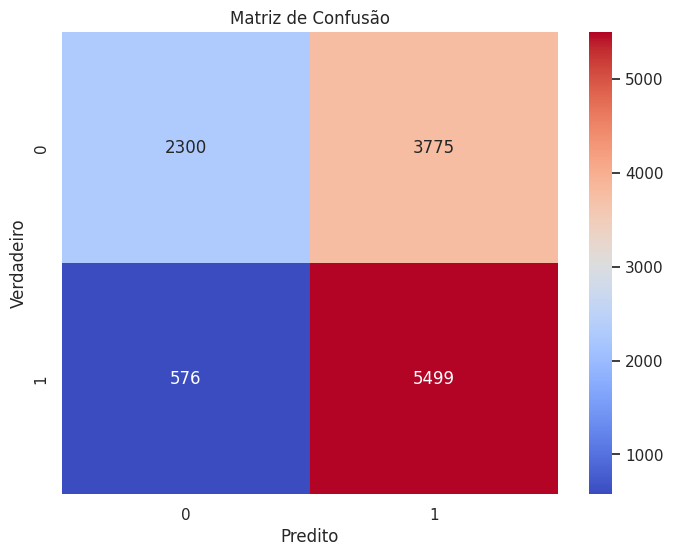

In [41]:
#Bloqueado por demorar demais
# modelo_treinado_peq_f6, historico_peq_f6 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled5,
#     y_train=y_train4,
#     X_test=X_test_scaled5,
#     y_test=y_test4,
#     optimizer='RMSprop',
#     loss='binary_crossentropy',
#     epochs=40,
#     batch_size=64
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.6286

F1-Score no conjunto de teste: 0.6886



### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.71 | 0.44 | 0.54 | 6075 |
| 1 | 0.59 | 0.82 | 0.69 | 6075 |
| **accuracy** | | | **0.63** | **12150** |
| **macro avg** | 0.65 | 0.63 | 0.61 | 12150 |
| **weighted avg** | 0.65 | 0.63 | 0.61 | 12150 |

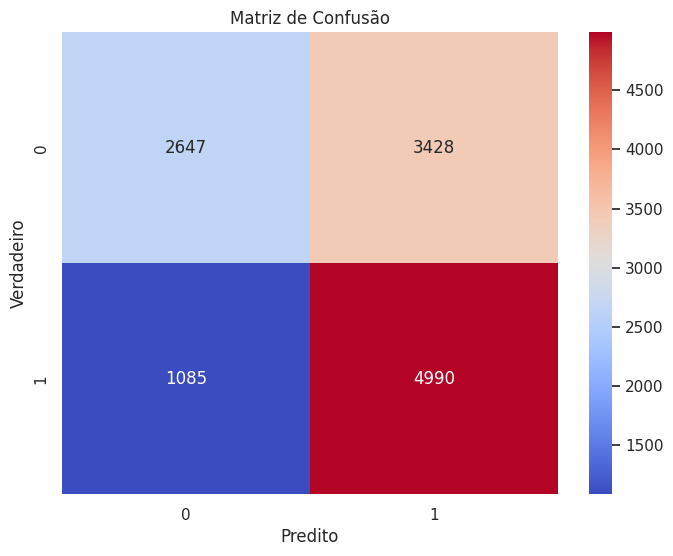

In [42]:
#Bloqueado por demorar demais
# modelo_treinado_peq_f7, historico_peq_f7 = treinar_e_avaliar_rede_neural_peq(
#     X_train=X_train_scaled5,
#     y_train=y_train4,
#     X_test=X_test_scaled5,
#     y_test=y_test4,
#     optimizer='adam',
#     loss='binary_crossentropy',
#     epochs=80,
#     batch_size=32
# )

#Resultados parciais

Acurácia no conjunto de teste: 0.6570

F1-Score no conjunto de teste: 0.6886




### Relatório de Classificação Detalhado

| Métrica | precision | recall | f1-score | support |
|:---|:---:|:---:|:---:|:---:|
| 0 | 0.71 | 0.43 | 0.54 | 6075 |
| 1 | 0.59 | 0.82 | 0.69 | 6075 |
| **accuracy** | | | **0.63** | **12150** |
| **macro avg** | 0.65 | 0.63 | 0.61 | 12150 |
| **weighted avg** | 0.65 | 0.63 | 0.61 | 12150 |


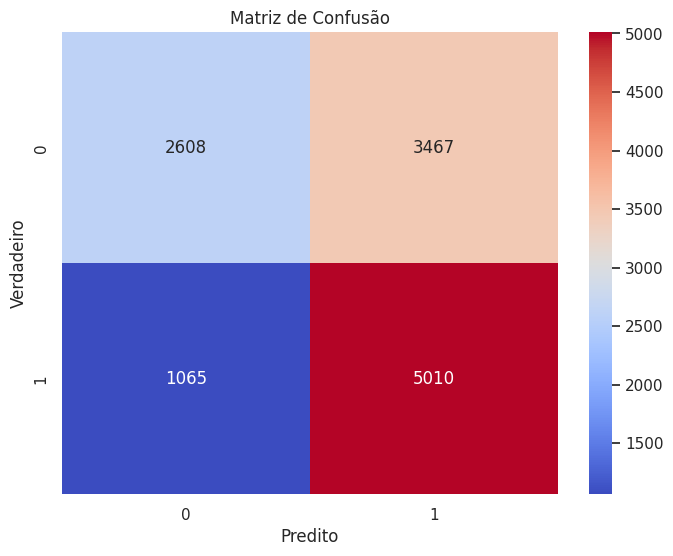

#Análise da rede neural
Para definir qual o melhor modelo, utilizaram-se como critério o valor médio do "f1" e do "recall". Por conseguinte a configuração que deu melhor resultado foi o modelo_treinado_med_f3.

---
**Configurações do modelo**

- Modelo com três layers

 - modelo_treinado_med_f3, historico_med_f3 = treinar_e_avaliar_rede_neural_med(
    X_train=X_train_scaled5,
    y_train=y_train4,
    X_test=X_test_scaled5,
    y_test=y_test4,
    optimizer='adam',
    loss='binary_crossentropy',
    epochs=40,
    batch_size=32
)

---
#Treinamento do modelo

Para escolher entre os modelos treinados e a rede neural, avaliaram-se os valores de "f1" e "recall". O modelo de rede neural tem o "f1" de 0.61, superando marginalmente os modelos SVM. Isso o posiciona como uma excelente alternativa em termos de desempenho geral e equilibrado. Porém ele empata com o modelo AdaBoost, alcançando o maior "recall". Isso significa que ele é igualmente eficaz em identificar a maioria das corridas que foram de fato canceladas.

Com base nessas conclusões apresentadas e no fato do modelo de rede neural ser mais rápido de ser treinado, a escolha foi do modelo de rede neural. Ele oferece o melhor equilíbrio entre encontrar as corridas canceladas e estar correto ao fazer essa afirmação, resultando no "f1" geral mais alto.

In [67]:
# #Salvando o modelo e o scaler
# joblib.dump(scaler5, 'scaler.pkl')

# modelo_treinado_med_f3.save('modelo_neural.keras')


#OBSERVAÇÃO:
Esse modelo escolhido não demora para ser treinado, por isso ele foi o único que não ficou comentado, porém, como a divisão dos dados é aleatória, pode ser que o resultado do treinamento mude. Para esse cenário, deixei o modelo salvo e importado nas celulas abaixo, porém os dados provavelmente vão mudar e podem impactar no resultado final.

In [84]:
#Importando o modelo
try:
  url_modelo = 'https://raw.githubusercontent.com/enakirimoto/Machine-Learning-and-Analytics/refs/heads/main/modelo_neural_final.keras'
  response_modelo = requests.get(url_modelo)
  response_modelo.raise_for_status()

  nome_arquivo_temporario = 'modelo_temp.keras'
  with open(nome_arquivo_temporario, 'wb') as f:
    f.write(response_modelo.content)

  modelo_github = tf.keras.models.load_model(nome_arquivo_temporario)

except Exception as e:
    print(f"Erro ao carregar o modelo: {e} - Sugiro avaliar as métricas no modelo treinado.")



In [85]:
#Importando o scaler pensando em um modelo em produção, mas ele não será utilizado pois vou usar os dados separados e ajustados anteriorimente.
url_do_scaler = 'https://raw.githubusercontent.com/enakirimoto/Machine-Learning-and-Analytics/refs/heads/main/scaler_final.pkl'
!wget -q {url_do_scaler} -O scaler_do_github.pkl
scaler_github = joblib.load('scaler_do_github.pkl')

In [86]:
if scaler_github and modelo_github and X_test_scaled5 is not None and y_test4 is not None:
    print("\n--- INICIANDO A AVALIAÇÃO DO MODELO CARREGADO ---")


    # Passo B: Avaliar o modelo com o método .evaluate() do Keras
    # Isso retorna a 'loss' e as métricas definidas na compilação do modelo (provavelmente 'accuracy').
    loss_teste, acc_teste = modelo_github.evaluate(X_test_scaled5, y_test4, verbose=0)

    print("\n--- Resultados da Avaliação ---")
    print(f"Loss (perda) no conjunto de teste: {loss_teste:.4f}")
    print(f"Acurácia no conjunto de teste: {acc_teste:.4f}")

    # Passo C: Obter relatório de classificação detalhado (Precision, Recall, F1-Score)
    print("\nGerando relatório de classificação detalhado...")
    y_pred_prob = modelo_github.predict(X_test_scaled5)
    y_pred_class = (y_pred_prob > 0.5).astype(int)

    # Calcular o F1-Score (macro) para comparar com os resultados anteriores
    f1_macro_teste = f1_score(y_test4, y_pred_class, average='macro')
    print(f"F1-Score (macro) no conjunto de teste: {f1_macro_teste:.4f}")

    print("\nRelatório de Classificação Detalhado:")
    print(classification_report(y_test4, y_pred_class))

else:
    print("\nA avaliação não pôde ser executada. Verifique os erros acima.")


--- INICIANDO A AVALIAÇÃO DO MODELO CARREGADO ---

--- Resultados da Avaliação ---
Loss (perda) no conjunto de teste: 0.5789
Acurácia no conjunto de teste: 0.6500

Gerando relatório de classificação detalhado...
380/380 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step
F1-Score (macro) no conjunto de teste: 0.6102

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       0.91      0.33      0.49      6075
           1       0.59      0.97      0.73      6075

    accuracy                           0.65     12150
   macro avg       0.75      0.65      0.61     12150
weighted avg       0.75      0.65      0.61     12150



In [103]:
dados_novos = pd.DataFrame({
    # Simulação
    'Avg VTAT': [10.5],
    'Type_Bike': [1],
    'Type_Go Mini': [0],
    'Type_Go Sedan': [0],
    'Type_Premier Sedan': [0],
    'Type_Uber XL': [0],
    'Type_eBike': [0],
    'cancellation_rate_percent_drop': [25],
    'cancellation_rate_percent_pickup': [25]
})

dados_novos_scaled = scaler_github.transform(dados_novos)
probabilidade_cancelar = modelo_github.predict(dados_novos_scaled)
previsao_classe = (probabilidade_cancelar > 0.5).astype(int)
probabilidade_nao_cancelar = 1 - probabilidade_cancelar

print(f"\nResultado da Previsão: {'Corrida será cancelada e o usuário vai ficar muito cabreiro.' if previsao_classe[0][0] == 1 else 'Corrida não será cancelada e tudo terá um final feliz.'}")
print(f"Probabilidade de NÃO Cancelar (Classe 0): {probabilidade_nao_cancelar[0][0]:.2%}")
print(f"Probabilidade de CANCELAR (Classe 1): {probabilidade_cancelar[0][0]:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

Resultado da Previsão: Corrida será cancelada e o usuário vai ficar muito cabreiro.
Probabilidade de NÃO Cancelar (Classe 0): 20.40%
Probabilidade de CANCELAR (Classe 1): 79.60%


#Conclusão
Esse trabalho foi desenvolvido com o objetivo de não se tornar um produto, por conseguinte não havia um requisito claro de acurácia, porém, os resultados encontrados foram extremamente positivos no ponto de vista do desenvolvedor. Entende-se que se esse modelo entrasse em produção, os motoristas disponíveis poderiam ser préviamente classificados e priorizados. Exemplo, focar para enviar as corridas para os motoristas sem risco de cancelamento. Isso gera menos prejuizos para a plataforma e para os usuários.

É sabido que podem ocorrer cenários que todos os motoristas disponíveis tenham riscos elevados, mas sabendo disso, a plataforma pode pensar no oferecimento de benefícios para evitar esse tipo de cancelamento.

---

Por fim entende-se que os dados foram carregados, tratados, analisados, modelados, otimizados várias vezes e as métricas foram avaliadas na escolha do melhor modelo.

---
#Próximos passos
Se esse modelo fosse empregado em um produto, precisa-se desenvolver um pipeline compatível com os múltiplos locais que o Uber atua. Sugiro reavaliar se os atributos ainda fazem sentido para os outro locais pois diferentes culturas possuem diferentes reações. Também sugiro restringir os treinamentos para os modelos que foram melhor qualificados e que fazem mais sentido para o processo, como por exemplo os modelos baseados em árvores que são muito bons lidar com mistura de dados numéricos e eles conseguem priorizar os atributos.

---

##Agradeço desde já todo os suporte dado durante as aulas de acompanhamento.

